# Load all data

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('original_files/lucas_harmo_uf.csv') # LUCAS harmonized from: 10.1038/s41597-020-00675-z
df_2018_europe_topsoil = pd.read_csv('original_files//LUCAS-SOIL-2018.csv')
df_2015_europe_topsoil = pd.read_csv('original_files/LUCAS_Topsoil_2015_20200323.csv')
df_2012_romania_topsoil = pd.read_csv('original_files/Romania.csv')
df_2012_bulgaria_topsoil = pd.read_csv('original_files/Bulgaria.csv')
df_2009_europe_topsoil = pd.read_excel('original_files/LUCAS_TOPSOIL_v1.xlsx')
df_MAOC = pd.read_csv('original_files/LCS.csv')
df_microbial = pd.read_csv('original_files/microbialProperties_SOC_data.csv')
df_BD = pd.read_csv('original_files/BulkDensity_2018_final-2.csv')
df_2015_ancilliary = pd.read_csv('original_files/LUCAS2015_AncillaryData_20201007.csv')

import pyreadr
result = pyreadr.read_r('original_files/Boundary_df_th_coords.rds')
df_MAOCHS = result[None]

/tmp/ipykernel_3999938/97415434.py:4: DtypeWarning: Columns (0: nuts3, 1: car_ew, 2: lc1_spec, 3: lc1_spec_label, 4: lc1_perc, 5: lc2_spec, 6: lc2_spec_label, 7: lc2_perc, 8: lu1_type, 9: lu1_type_label, 10: lu1_perc, 11: lu2, 12: lu2_type, 13: lu2_type_label, 14: lu2_perc, 15: parcel_area_ha, 16: tree_height_maturity, 17: tree_height_survey, 18: feature_width, 19: lm_stone_walls, 20: crop_residues, 21: lm_grass_margins, 22: grazing, 23: special_status, 24: lc_lu_special_remark, 25: cprn_cando, 26: cprn_lc, 27: cprn_lc_label, 28: cprn_lc1n_next, 29: cprn_lc1s_next, 30: cprn_lc1e_next, 31: cprn_lc1w_next, 32: cprn_urban, 33: eunis_complex, 34: grass_cando, 35: wm, 36: wm_source, 37: wm_type, 38: wm_delivery, 39: erosion_cando, 40: soil_stones_perc, 41: soil_blk_0_10_taken, 42: soil_blk_10_20_taken, 43: soil_blk_20_30_taken, 44: soil_std_taken, 45: soil_org_depth_cando, 46: soil_taken, 47: soil_crop, 48: photo_point, 49: photo_north, 50: photo_south, 51: photo_east, 52: photo_west, 53: t

# Select desired columns for each

In [2]:
def select_columns(df, columns_to_keep):
    return df[columns_to_keep]
df = select_columns(df, ['point_id', 'year', 'gps_lat', 'gps_ew', 'gps_long', 'lc1', 'lc1_label', 'survey_date', 'tree_height_survey', 'grazing', 'wm', 'soil_stones_perc', 'soil_taken', 'soil_crop'])
df_2018_europe_topsoil = select_columns(df_2018_europe_topsoil, ['POINTID', 'pH_CaCl2', 'OC', 'CaCO3', 'P', 'N', 'K', 'Ox_Al', 'Ox_Fe'])
df_2015_europe_topsoil = select_columns(df_2015_europe_topsoil, ['Point_ID', 'Coarse', 'Clay', 'Sand', 'Silt', 'pH(CaCl2)', 'OC', 'CaCO3', 'P', 'N', 'K'])
df_2012_romania_topsoil = select_columns(df_2012_romania_topsoil, ['POINTID', 'coarse', 'clay', 'silt', 'sand', 'pHinCaCl2', 'OC', 'CaCO3', 'N', 'P', 'K'])
df_2012_bulgaria_topsoil = select_columns(df_2012_bulgaria_topsoil, ['POINT_ID', 'coarse', 'clay', 'silt', 'sand', 'pHinCaCl2', 'OC', 'CaCO3', 'N', 'P', 'K'])
df_2009_europe_topsoil = select_columns(df_2009_europe_topsoil, ['POINT_ID', 'coarse', 'clay', 'silt', 'sand', 'pH_in_CaCl2', 'OC', 'CaCO3', 'N', 'P', 'K'])
df_BD = select_columns(df_BD, ['POINT_ID', 'BD 0-20'])
df_MAOC = select_columns(df_MAOC, ['POINT_ID', 'OC_pom_g_kg', 'OC_sc_g_kg'])
df_MAOCHS = select_columns(df_MAOCHS, ['POINT_ID', 'OC_pom_g_kg', 'OC_sc_g_kg'])
df_microbial = select_columns(df_microbial, ['LUCAS_ID', 'Cmic'])
df_2015_ancilliary = select_columns(df_2015_ancilliary, ['POI', 'Soil_Group'])

# Rename columns

In [3]:
df = df.rename(columns={'point_id': 'POINT_ID'})
df_2018_europe_topsoil = df_2018_europe_topsoil.rename(columns={'POINTID': 'POINT_ID'})
df_2015_europe_topsoil = df_2015_europe_topsoil.rename(columns={'Point_ID': 'POINT_ID', 'pH(CaCl2)': 'pH_CaCl2', 'pH(H2O)': 'pH_H2O'})
df_2012_romania_topsoil = df_2012_romania_topsoil.rename(columns={'POINTID': 'POINT_ID', 'coarse': 'Coarse', 'clay': 'Clay', 'silt': 'Silt', 'sand': 'Sand', 'pHinH2O': 'pH_H2O', 'pHinCaCl2': 'pH_CaCl2'})
df_2012_bulgaria_topsoil = df_2012_bulgaria_topsoil.rename(columns={'coarse': 'Coarse', 'clay': 'Clay', 'silt': 'Silt', 'sand': 'Sand', 'pHinH2O': 'pH_H2O', 'pHinCaCl2': 'pH_CaCl2'})
df_2009_europe_topsoil = df_2009_europe_topsoil.rename(columns={'coarse': 'Coarse', 'clay': 'Clay', 'silt': 'Silt', 'sand': 'Sand', 'pH_in_H2O': 'pH_H2O', 'pH_in_CaCl2': 'pH_CaCl2','sample_ID': 'SoilID'})
df_microbial = df_microbial.rename(columns={'LUCAS_ID': 'POINT_ID'})
df_MAOCHS = df_MAOCHS.rename(columns={col: col + '_HS' for col in ['OC_fractions', 'OC_pom_g_kg', 'OC_sc_g_kg', 'cluster_sse']})
df_2015_ancilliary = df_2015_ancilliary.rename(columns={'POI': 'POINT_ID'})

# Clean Management variables

In [4]:
dummy_df = df[df['soil_taken'] == 'Yes']

# for var in df.columns.values:
#     unique_count = df[var].nunique(dropna=False)
#     unique_vals = df[var].unique()
#     # If dtype is Arrow, fallback to converting to list of python strings
#     if hasattr(unique_vals, "to_numpy"):
#         unique_vals = unique_vals.to_numpy()
#     if (hasattr(unique_vals, "dtype") and "arrow" in str(unique_vals.dtype).lower()) or type(unique_vals).__name__.startswith("Arrow"):
#         unique_vals = [str(x) for x in unique_vals[:3]]
#     print(f"{var} {' '*(15-len(var))}: {unique_count} unique: {unique_vals[:3]}")


# tree_height_maturity : 5 unique: ['Not relevant' '> 5 m' nan]
# tree_height_survey : 6 unique: ['Not relevant' '< 5 m' '> 5 m']
# lm_stone_walls  : 5 unique: [nan 'No' 'Not relevant']
# crop_residues   : 4 unique: [nan 'No' 'Yes']
# lm_grass_margins : 5 unique: [nan 'No' '> 1 m width']
# grazing         : 4 unique: ['No signs of grazing' nan 'Signs of grazing']
# wm: 7 unique values
# wm_source: 12 unique values
# wm_type: 15 unique values
# wm_delivery: 10 unique values
# soil_stones_perc: 7 unique values
# soil_crop: 6 unique values

class_orders = {
    'tree_height_survey': ['0', '< 5 m', '> 5 m'], 
    'grazing': ['No signs of grazing', 'Signs of grazing'], 
    'wm': ['Drainage', 'No visible water management', 'Potential irrigation', 'Irrigation'], 
    'soil_stones_perc': ['< 10 %', '10 - 25 %', '25 - 50 %', '> 50 %'], 
    'soil_crop': ['< 10 %', '10 - 25 %', '25 - 50 %', '> 50 %']
}
for var in ['tree_height_survey', 'grazing', 'wm', 'soil_stones_perc', 'soil_crop']:
    print(f"\nVariable: {var}")
    print(dummy_df[var].value_counts(dropna=False))

    # Replace 'Not relevant' with pd.NA in original df and dummy_df
    df[var] = df[var].replace('Not relevant', np.nan)
    dummy_df[var] = dummy_df[var].replace('Not relevant', pd.NA)

    # Calculate value counts on dummy_df
    value_counts = dummy_df[var].value_counts(dropna=False)
    to_nan = value_counts[value_counts < 100].index

    # Set rare classes to NA in both original df and dummy_df
    df[var] = df[var].apply(lambda x: pd.NA if x in to_nan else x)
    dummy_df[var] = dummy_df[var].apply(lambda x: pd.NA if x in to_nan else x)

    # Convert categorical values to 0-1 as numerical values in both
    cat = pd.Categorical(df[var], categories=class_orders[var], ordered=True)
    df[var] = cat.codes.astype(float)
    df[var] = df[var].replace(-1, pd.NA)  # -1 code indicates NA in pd.Categorical

    # Sync dummy
    cat_dummy = pd.Categorical(dummy_df[var], categories=class_orders[var], ordered=True)
    dummy_df[var] = cat_dummy.codes.astype(float)
    dummy_df[var] = dummy_df[var].replace(-1, pd.NA)

    print(dummy_df[var].value_counts(dropna=False))


Variable: tree_height_survey
tree_height_survey
Not relevant        16578
0                   14361
> 5 m               12403
< 5 m                1856
NaN                    55
Not identifiable        1
Name: count, dtype: int64
tree_height_survey
<NA>    16634
0.0     14361
2.0     12403
1.0      1856
Name: count, dtype: int64

Variable: grazing
grazing
No signs of grazing    39410
Signs of grazing        5192
Not relevant             652
Name: count, dtype: int64
grazing
0.0     39410
1.0      5192
<NA>      652
Name: count, dtype: int64

Variable: wm
wm
No visible water management    24765
Not relevant                   15309
Drainage                        2756
Irrigation                      1441
Potential irrigation             954
Irrigation and drainage           29
Name: count, dtype: int64
wm
1.0     24765
<NA>    15338
0.0      2756
3.0      1441
2.0       954
Name: count, dtype: int64

Variable: soil_stones_perc
soil_stones_perc
< 10 %       33962
10 - 25 %     6702
25 - 

/tmp/ipykernel_3999938/2636205766.py:51: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  cat = pd.Categorical(df[var], categories=class_orders[var], ordered=True)


soil_stones_perc
0.0    33962
1.0     6702
2.0     2961
3.0     1629
Name: count, dtype: int64

Variable: soil_crop
soil_crop
< 10 %       28051
> 50 %        8093
10 - 25 %     5934
25 - 50 %     3176
Name: count, dtype: int64
soil_crop
0.0    28051
3.0     8093
1.0     5934
2.0     3176
Name: count, dtype: int64


# Integrate East-West (ew) into GPS

In [5]:
df.loc[df['gps_ew'] == 'West', 'gps_long'] *= -1

# Add year to sub datasets

In [6]:
df_2018_europe_topsoil['year'] = 2018
df_2015_europe_topsoil['year'] = 2015
df_2012_romania_topsoil['year'] = 2012
df_2012_bulgaria_topsoil['year'] = 2012
df_2009_europe_topsoil['year'] = 2009
df_BD['year'] = 2018
df_MAOC['year'] = 2009
df_MAOCHS['year'] = 2009
df_microbial['year'] = 2018
df_2015_ancilliary['year'] = 2015

# Make:
- strings to float (if possible)
- to 0.0 (if string indicates that)

In [7]:
# if there are whitespac in the column, it is read by pd_read_csv as a string 
# -> function corrects that (if there are values below limit of determination, they are replaced with 0.0)
def string_to_float(df, column):
    df[column] = df[column].astype(str).str.strip().replace({'': None}) # make column entirely string, remove useless white space, make empty to None
    df[column] = pd.to_numeric(df[column], errors='coerce').fillna(0.0) # make column entirely numeric, if impossible to 0.0

for column in ['OC', 'CaCO3', 'P', 'N', 'K']:
    string_to_float(df_2018_europe_topsoil, column)
for column in ['OC', 'CaCO3', 'P', 'N', 'K']:
    df_2012_romania_topsoil[column] = pd.to_numeric(df_2012_romania_topsoil[column], errors='coerce').fillna(0)
    df_2012_bulgaria_topsoil[column] = pd.to_numeric(df_2012_bulgaria_topsoil[column], errors='coerce').fillna(0)

# Replace Placeholder with np.nan

In [8]:
for column in ['Clay', 'Silt', 'Sand', 'pH_CaCl2', 'N', 'P', 'K', 'CaCO3', 'OC']:
    df_2012_romania_topsoil[column] = df_2012_romania_topsoil[column].replace(-999, np.nan)
for column in ['CaCO3', 'P']:
    df_2012_bulgaria_topsoil[column] = df_2012_bulgaria_topsoil[column].replace(-999, np.nan)
for column in ['POINT_ID']:
    df_2009_europe_topsoil[column] = df_2009_europe_topsoil[column].replace('NE', np.nan)

df.loc[df['gps_lat'].isin([88.888888, 88.888890]), 'gps_lat'] = np.nan
df.loc[df['gps_long'].isin([88.888888, 88.888890]), 'gps_long'] = np.nan

# Replace negative values with np.nan

In [9]:
for column in ['Silt']:
    df_2012_romania_topsoil.loc[df_2012_romania_topsoil[column] < 0, column] = np.nan

# Adapt units

In [10]:
df_2012_romania_topsoil['N'] = df_2012_romania_topsoil['N'] / 100
df_2012_bulgaria_topsoil['N'] = df_2012_bulgaria_topsoil['N'] / 100

# If all texture data is 0 then make them np.nan

In [11]:
for row in range(len(df_2009_europe_topsoil)):
    if df_2009_europe_topsoil.Clay[row]==0 and df_2009_europe_topsoil.Silt[row]==0 and df_2009_europe_topsoil.Sand[row]==0:
        df_2009_europe_topsoil.loc[row, 'Clay'] = np.nan
        df_2009_europe_topsoil.loc[row, 'Silt'] = np.nan
        df_2009_europe_topsoil.loc[row, 'Sand'] = np.nan

# Delete if no GPS

In [12]:
gps_lat_nan_indices = df[df['gps_lat'].isna()].index
gps_long_nan_indices = df[df['gps_long'].isna()].index
gps_nan_indices = gps_lat_nan_indices.union(gps_long_nan_indices)
# print("Rows with NaN in gps_lat or gps_long:", list(gps_nan_indices))
# print("Number of rows with NaN in gps_lat or gps_long:", len(gps_nan_indices))
df = df.drop(index=gps_nan_indices).reset_index(drop=True)

# Rearrange harmonized/published LC data

In [13]:
dfs = {}
for year in [2006, 2009, 2012, 2015, 2018]: # loop over years
    dfs[year] = df[df['year'] == year][['POINT_ID', 'gps_lat', 'gps_long', 'lc1', 'survey_date', 'tree_height_survey', 'grazing', 'wm', 'soil_stones_perc', 'soil_crop']] # create df per year (from harmonized LC) with basic information
    for var in ['gps_lat', 'gps_long', 'lc1', 'survey_date', 'tree_height_survey', 'grazing', 'wm', 'soil_stones_perc', 'soil_crop']: # rename columns to include year
        dfs[year] = dfs[year].rename(columns={var: f'{var}_{year}'})

from functools import reduce
mdf = reduce(lambda left, right: pd.merge(left, right, on='POINT_ID', how='outer'), [dfs[year] for year in sorted(dfs.keys())]) # merge again

# Add topsoil and other

In [14]:
for ds in [df_2018_europe_topsoil, df_2015_europe_topsoil, df_2012_romania_topsoil, df_2012_bulgaria_topsoil, df_2009_europe_topsoil, df_BD, df_MAOC, df_MAOCHS, df_microbial]:
    for var in ds.columns:
        if var not in ['POINT_ID', 'year']:
            year = int(ds.iloc[0]['year'])
            if var+'_'+str(year) not in mdf.columns:
                mdf[var+'_'+str(year)] = [np.nan] * len(mdf)
            not_found = 0
            for row in range(len(ds)):
                ds_pid = ds.iloc[row]['POINT_ID']
                if pd.isnull(ds_pid):
                    not_found += 1
                    continue
                ds_pid = int(ds_pid)
                value = float(ds.iloc[row][var])
                if pd.isnull(value):
                    continue
                idx = mdf.index[mdf['POINT_ID'] == ds_pid]
                # idx is an Index object; check if any match found
                if len(idx) == 0:
                    not_found += 1
                    continue
                mdf.at[idx[0], var+'_'+str(year)] = value
            print(year, var+'_'+str(year), 'not_found', not_found)

2018 pH_CaCl2_2018 not_found 2
2018 OC_2018 not_found 2
2018 CaCO3_2018 not_found 2
2018 P_2018 not_found 2
2018 N_2018 not_found 2
2018 K_2018 not_found 2
2018 Ox_Al_2018 not_found 0
2018 Ox_Fe_2018 not_found 0
2015 Coarse_2015 not_found 0
2015 Clay_2015 not_found 0
2015 Sand_2015 not_found 0
2015 Silt_2015 not_found 0
2015 pH_CaCl2_2015 not_found 0
2015 OC_2015 not_found 0
2015 CaCO3_2015 not_found 0
2015 P_2015 not_found 0
2015 N_2015 not_found 0
2015 K_2015 not_found 0
2012 Coarse_2012 not_found 0
2012 Clay_2012 not_found 0
2012 Silt_2012 not_found 0
2012 Sand_2012 not_found 0
2012 pH_CaCl2_2012 not_found 0
2012 OC_2012 not_found 0
2012 CaCO3_2012 not_found 0
2012 N_2012 not_found 0
2012 P_2012 not_found 0
2012 K_2012 not_found 0
2012 Coarse_2012 not_found 0
2012 Clay_2012 not_found 0
2012 Silt_2012 not_found 0
2012 Sand_2012 not_found 0
2012 pH_CaCl2_2012 not_found 0
2012 OC_2012 not_found 0
2012 CaCO3_2012 not_found 0
2012 N_2012 not_found 0
2012 P_2012 not_found 0
2012 K_2012 no

# Add Soil_Group (product?)

In [15]:
mdf = pd.merge(mdf, df_2015_ancilliary, on='POINT_ID', how='left')

# Drop rows where all data columns are NaN

In [16]:
meta_cols = ['POINT_ID', 'Soil_Group'] + [f'{col}_{year}' for year in [2006, 2009, 2012, 2015, 2018] for col in ['gps_lat', 'gps_long', 'lc1', 'survey_date', 'tree_height_survey', 'grazing', 'wm', 'soil_stones_perc', 'soil_crop']]
data_cols = [c for c in mdf.columns if c not in meta_cols]
mdf = mdf.dropna(subset=data_cols, how='all').reset_index(drop=True)

# higher LC level & same LC classes in 2015/2018

In [17]:
# higher LC level (only keep letter)
mdf['lc1_2_2018'] = mdf['lc1_2018'].astype(str).str[0]
mdf['lc1_2_2015'] = mdf['lc1_2015'].astype(str).str[0]
mdf['lc1_2_2009'] = mdf['lc1_2009'].astype(str).str[0]

# keep at detailed levels only those, that exist in each year
for col in ['lc1_2015', 'lc1_2018', 'lc1_2009']:
    mdf = mdf[mdf[col].notnull()]
    mdf[col] = mdf[col].astype(str)

classes_2018 = list(mdf['lc1_2018'].unique())
print(len(classes_2018))
classes_2015 = list(mdf['lc1_2015'].unique())
print(len(classes_2015))
classes_2009 = list(mdf['lc1_2009'].unique())
print(len(classes_2009))
classes_in_all = set(classes_2015) & set(classes_2018) & set(classes_2009)
# For each LC1 column, set to NaN if not in the intersection set (classes_in_all)
for col in ['lc1_2015', 'lc1_2018', 'lc1_2009']:
    mdf.loc[~mdf[col].isin(classes_in_all), col] = np.nan


classes_2018 = list(mdf['lc1_2018'].unique())
print(len(classes_2018))
classes_2015 = list(mdf['lc1_2015'].unique())
print(len(classes_2015))
classes_2009 = list(mdf['lc1_2009'].unique())
print(len(classes_2009))


mdf = mdf.reset_index(drop=True)
df = mdf

70
68
59
54
54
54


# Scale Cmic to unit of SOC

In [18]:
df['Cmic_2018'] = df['Cmic_2018'] /1000

# Plot distributions to compare between years

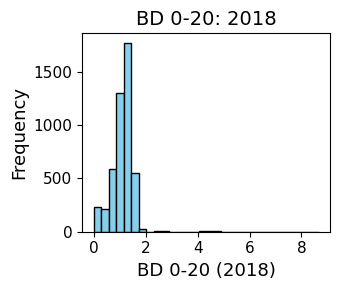

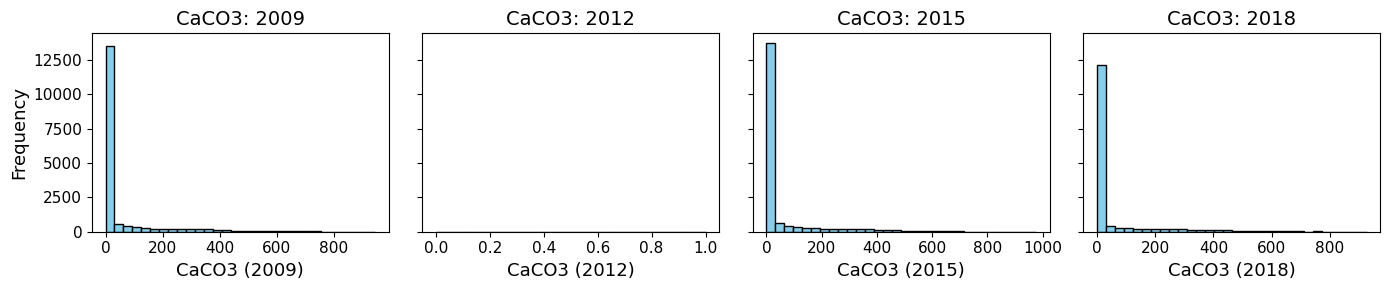

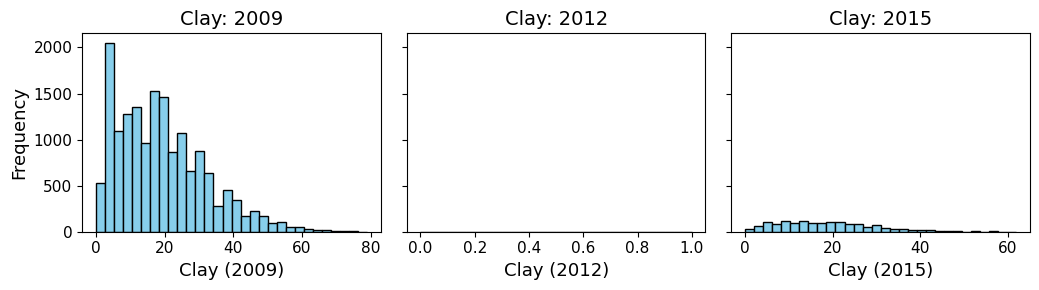

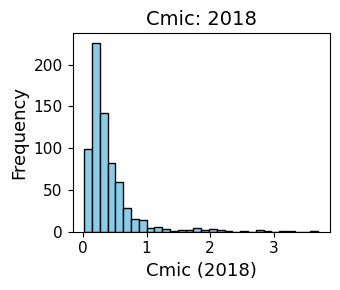

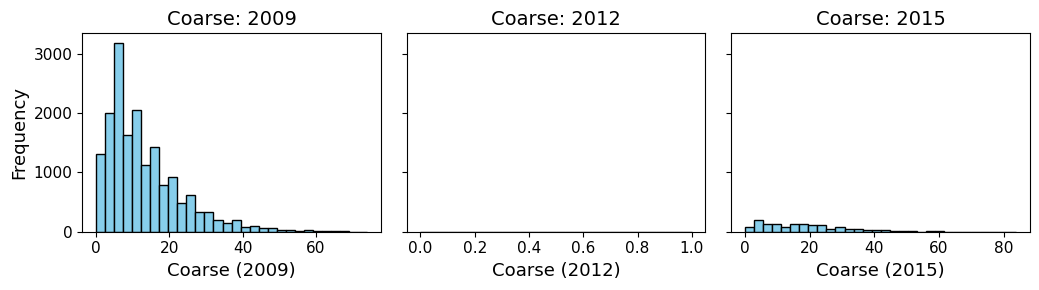

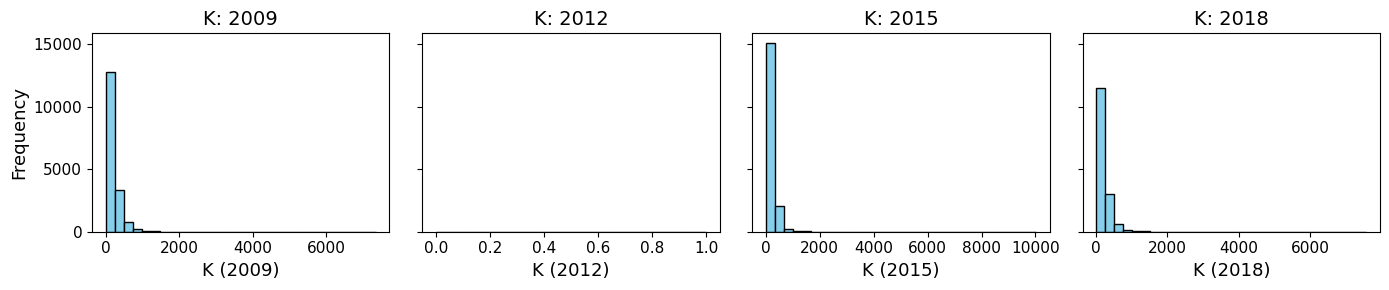

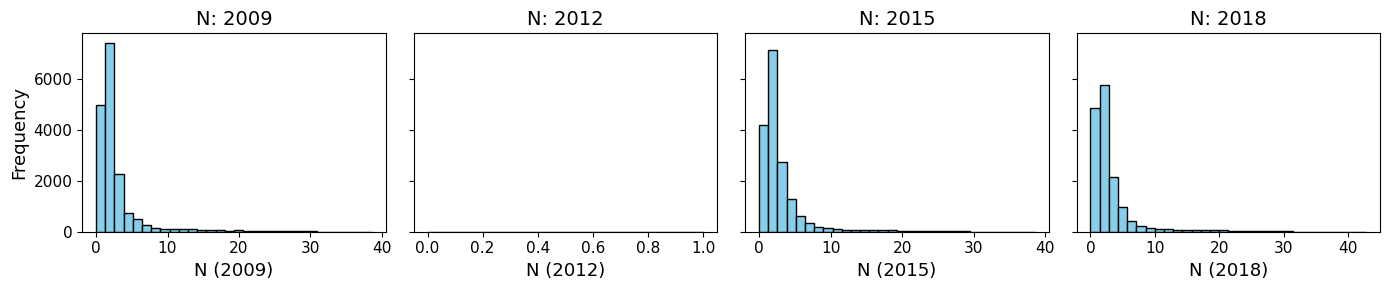

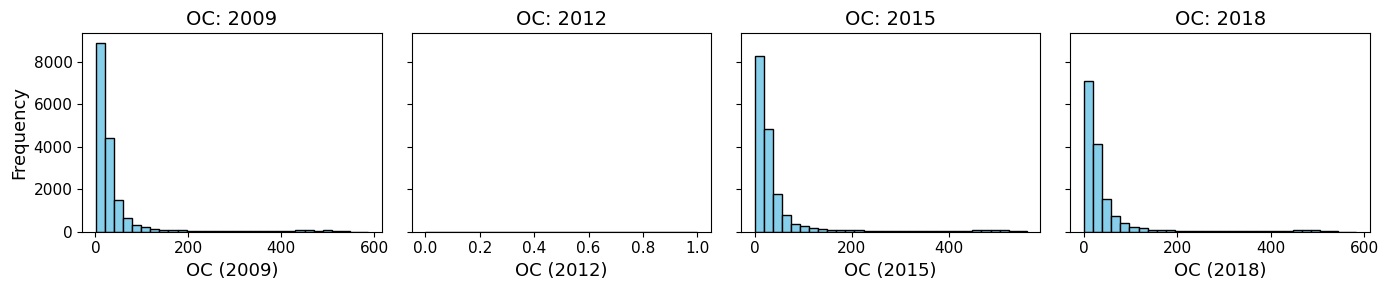

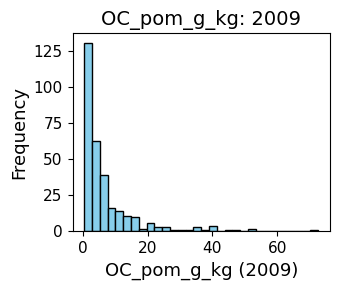

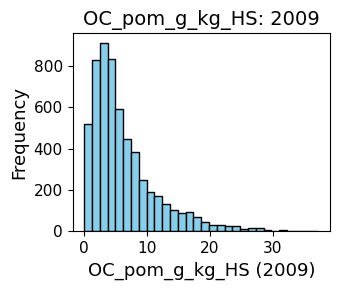

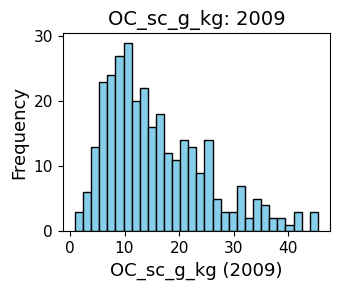

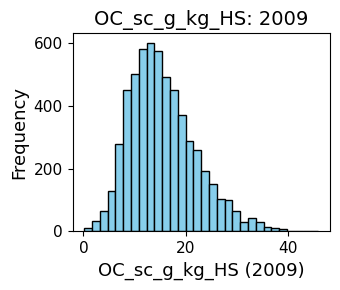

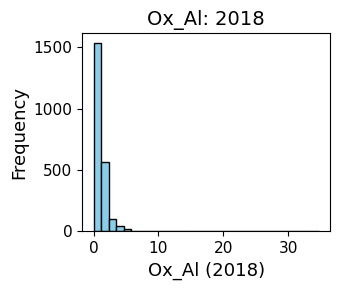

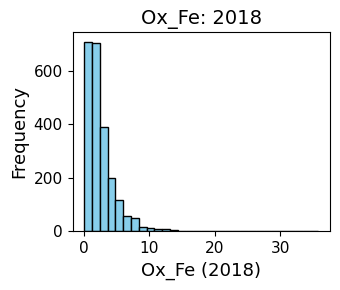

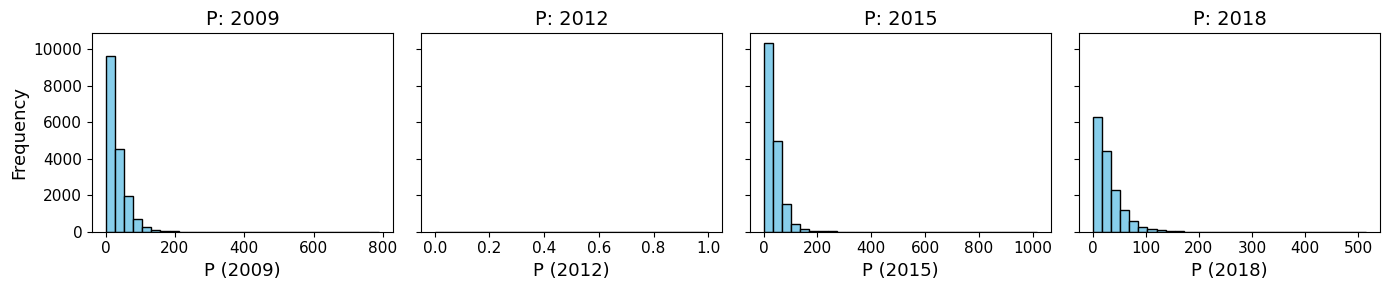

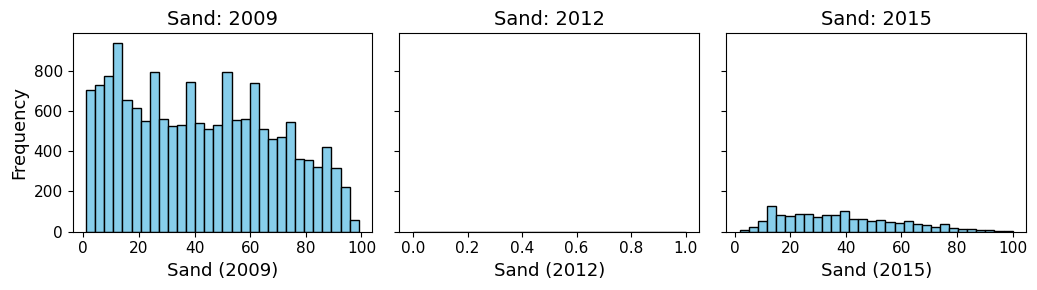

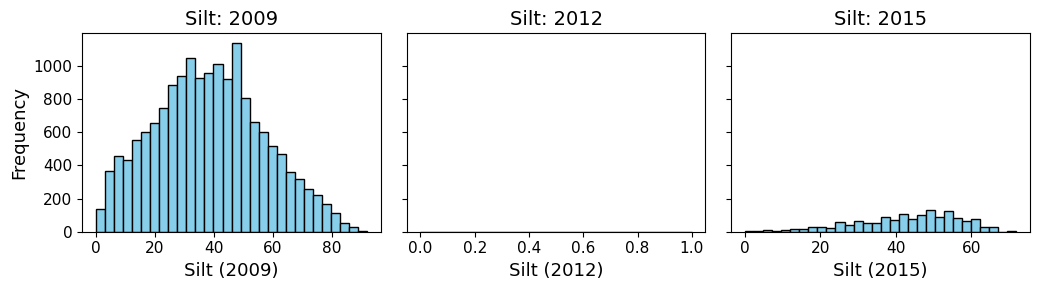

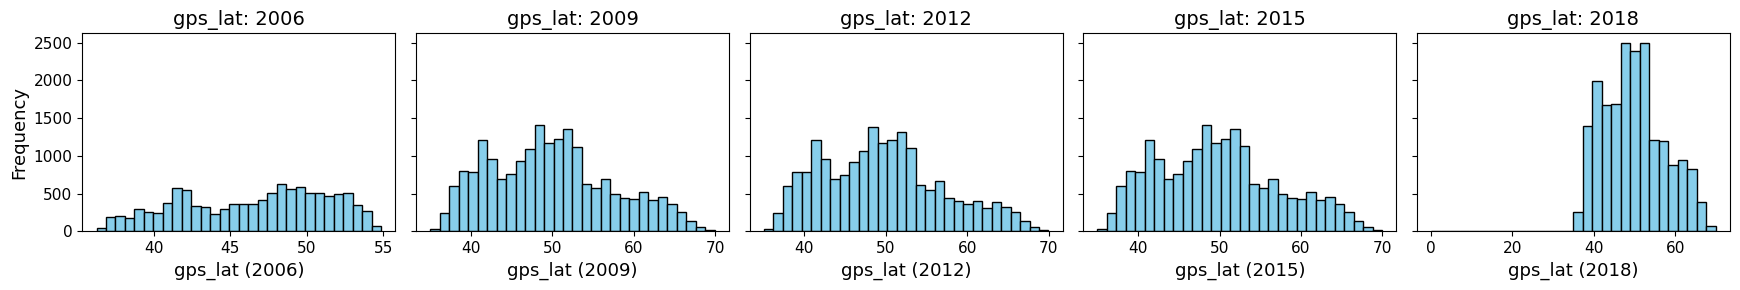

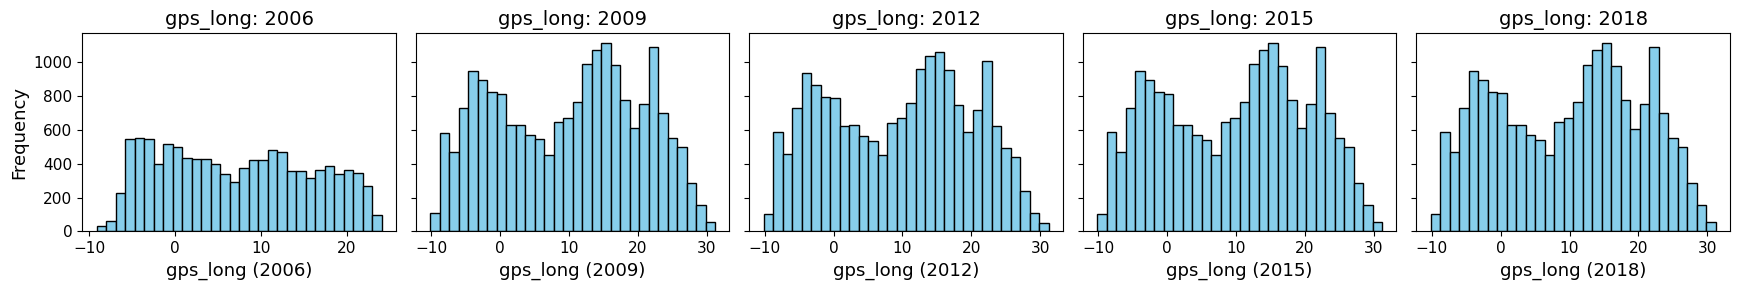

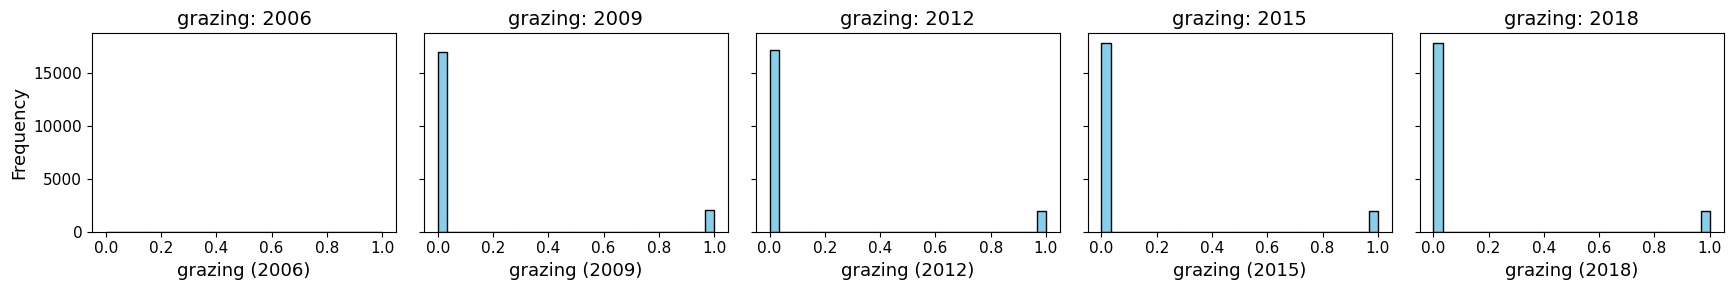

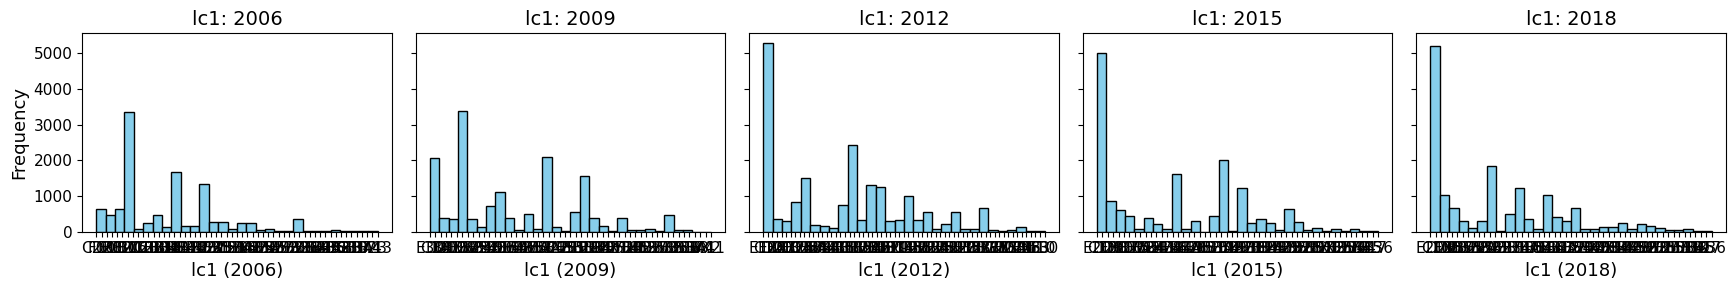

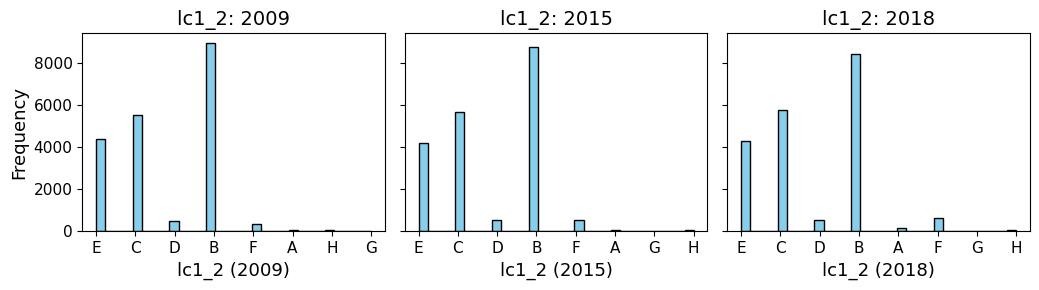

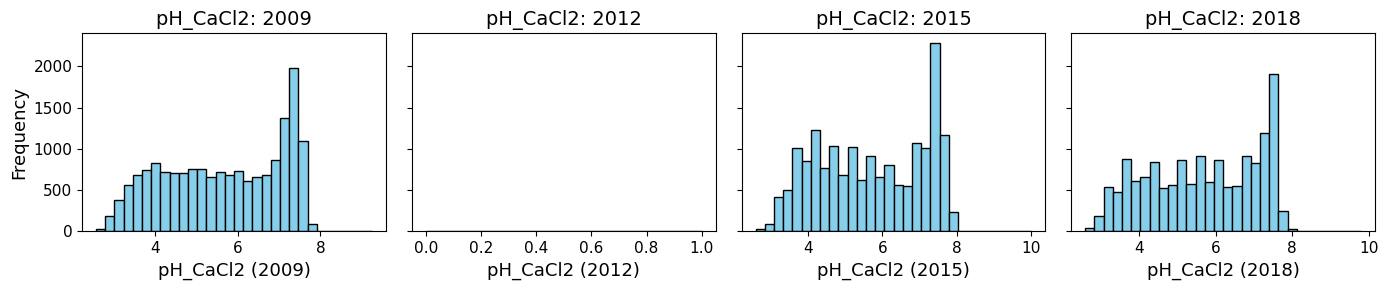

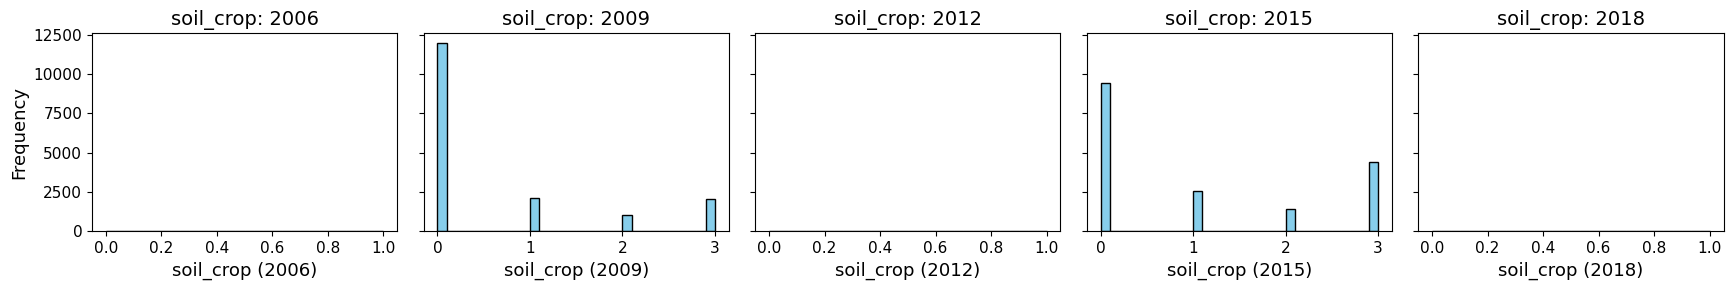

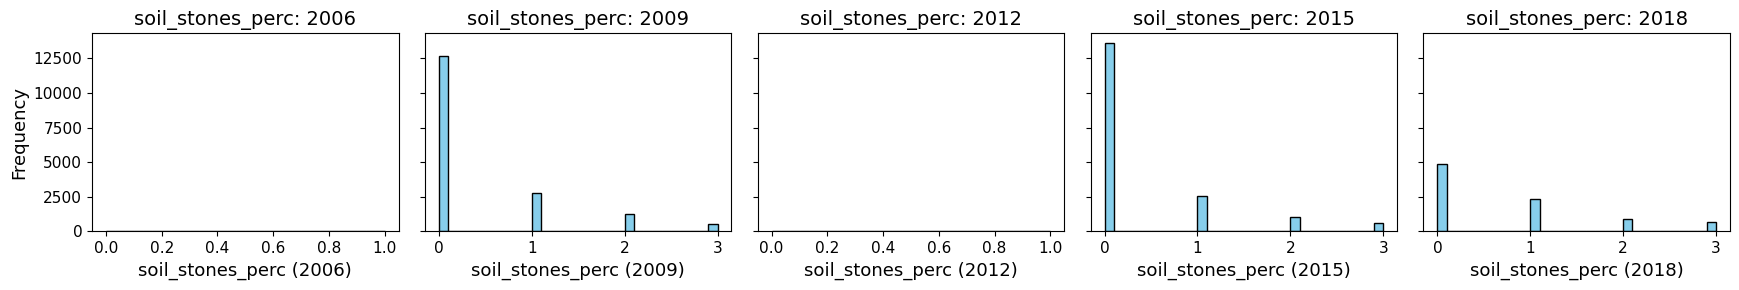

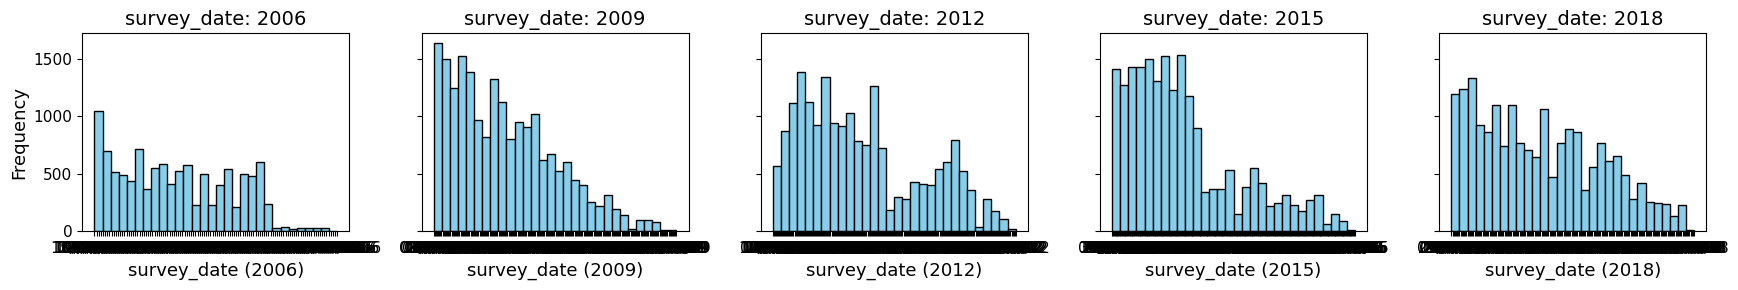

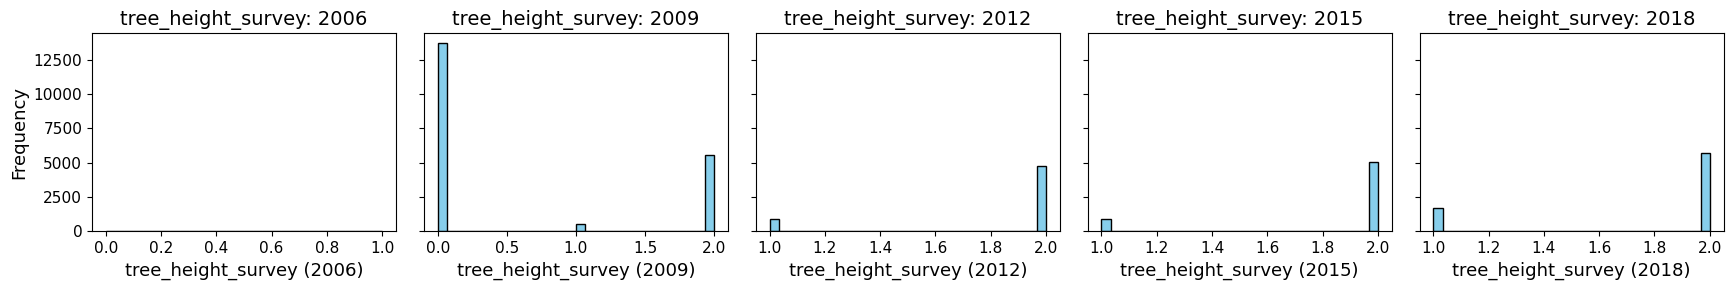

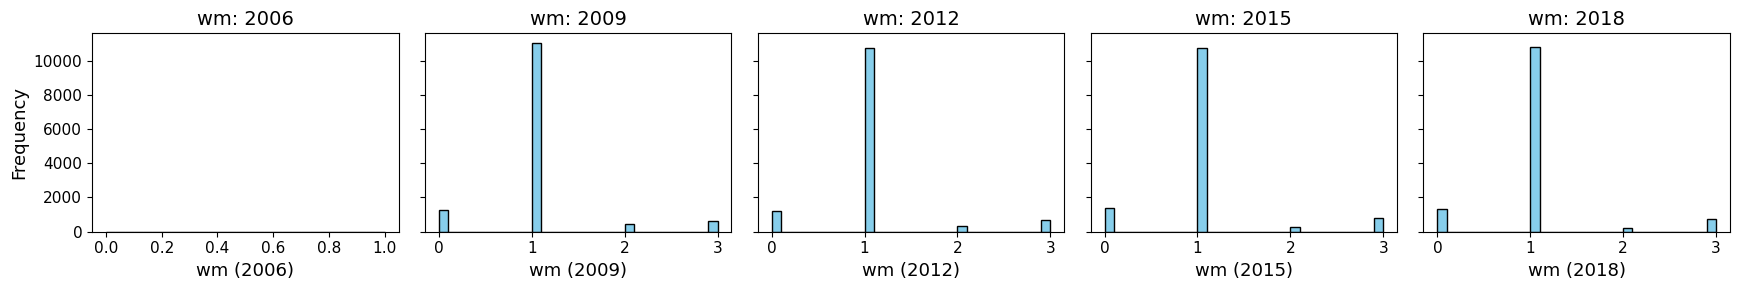

In [19]:
import matplotlib.pyplot as plt
import re
import pandas as pd

# Use regex to find column names like 'var_YYYY'
pattern = re.compile(r'^(.*)_(\d{4})$')

variable_year_pairs = []
for col in df.columns:
    match = pattern.match(col)
    if match:
        variable, year = match.group(1), match.group(2)
        variable_year_pairs.append((variable, year))

# Get unique variable names, then sort them
variables = sorted({var for var, yr in variable_year_pairs})
years = sorted({yr for var, yr in variable_year_pairs})

def get(variable, year):
    col = f"{variable}_{year}"
    if col in df.columns:
        return df[col]
    else:
        return pd.Series([None] * len(df))

def hist(variable, year):
    values = get(variable, year)
    filtered_values = values[values.notnull()]
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.hist(filtered_values, bins=30, color='skyblue', edgecolor='black')
    ax.set_xlabel(f'{variable} ({year}, per unit SOC)', fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    ax.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    plt.show()
    return fig, ax

def hists(df, variable, show=True):
    # Dynamically find year-suffixed columns for this variable
    var_years = []
    for col in df.columns:
        match = pattern.match(col)
        if match:
            var, year = match.group(1), match.group(2)
            if var == variable:
                var_years.append(year)
    var_years = sorted(var_years)
    n_years = len(var_years)
    if n_years == 0:
        # No year-suffixed columns found. Try plotting the raw variable.
        if variable in df.columns:
            values = df[variable]
            filtered_values = values[values.notnull()]
            fig, ax = plt.subplots(figsize=(4, 3))
            ax.hist(filtered_values, bins=30, color='skyblue', edgecolor='black')
            ax.set_xlabel(f'{variable}', fontsize=14)
            ax.set_ylabel('Frequency', fontsize=14)
            ax.set_title(variable, fontsize=14)
            ax.tick_params(axis='both', labelsize=12)
            plt.tight_layout()
            if show:
                plt.show()
        else:
            print(f"Skipping {variable!r}: no year-suffixed columns or raw column found.")
        return
    fig, axes = plt.subplots(1, n_years, figsize=(3.5 * n_years, 3), sharey=True)
    if n_years == 1:
        axes = [axes]
    for i, year in enumerate(var_years):
        values = get(variable, year)
        filtered_values = values[values.notnull()]
        axes[i].hist(filtered_values, bins=30, color='skyblue', edgecolor='black')
        axes[i].set_xlabel(f'{variable} ({year})', fontsize=13)
        if i == 0:
            axes[i].set_ylabel('Frequency', fontsize=13)
        axes[i].set_title(f'{variable}: {year}', fontsize=14)
        axes[i].tick_params(axis='both', labelsize=11)
    plt.tight_layout()
    if show:
        plt.show()

# Example usage for all variables present with year:
for var in variables:
    hists(df, var)


# Delete unrealistic Bulk Density values

In [20]:
bd_problematic_indices = [i for i, v in enumerate(df['BD 0-20_2018']) if v is not None and (v < 0.05 or v > 2.3)]
# print([df['BD 0-20_2018'][i] for i in bd_problematic_indices])
if bd_problematic_indices:
    df.at[bd_problematic_indices[-1], 'BD 0-20_2018'] = None

# Set 0.0 to .5*detection limit

In [21]:
# so the distributions are less distorted
import numpy as np

years = [2009, 2012, 2015, 2018]
replace_0 = ["Coarse", "Clay", "Silt", "Sand", "OC", "CaCO3", "N", "K", "P"]

for var in replace_0:
    # Identify which columns for this variable actually exist (for available years)
    cols = [f"{var}_{year}" for year in years if f"{var}_{year}" in df.columns]
    if not cols:
        continue

    min_val = np.inf
    # Find the minimum nonzero value across all existing year-columns for this variable
    for col in cols:
        values = df[col].dropna()
        nonzero_values = values[values != 0.0]
        if len(nonzero_values) > 0:
            year_min = nonzero_values.min()
            if year_min < min_val:
                min_val = year_min
    # Replace 0.0 with 0.5 * min_val for each existing year column
    for col in cols:
        mask = df[col] == 0.0
        df.loc[mask, col] = 0.5 * min_val

# Summarize texture from different years

In [22]:
def summarize_texture(df, var_substr):
    years = [2015, 2012, 2009]
    first_col = f"{var_substr}_{years[0]}"    
    output = df[first_col].copy()
    print(f"Non-NaN for {first_col}: {output.notna().sum()}")
    for year in years[1:]:
        col = f"{var_substr}_{year}"
        output = output.where(~output.isna(), df[col])
        print(f"Non-NaN for {col}: {output.notna().sum()}")
    df[var_substr] = output
    print()

summarize_texture(df, 'Clay')
summarize_texture(df, 'Silt')
summarize_texture(df, 'Sand')
summarize_texture(df, 'Coarse')

Non-NaN for Clay_2015: 1479
Non-NaN for Clay_2012: 1479
Non-NaN for Clay_2009: 17854

Non-NaN for Silt_2015: 1479
Non-NaN for Silt_2012: 1479
Non-NaN for Silt_2009: 17854

Non-NaN for Sand_2015: 1479
Non-NaN for Sand_2012: 1479
Non-NaN for Sand_2009: 17854

Non-NaN for Coarse_2015: 1477
Non-NaN for Coarse_2012: 1477
Non-NaN for Coarse_2009: 18716



# MAOC/MIC ratios + C:N, C:P, C:K

In [23]:
df['MAOC_index_2009'] = df['OC_sc_g_kg_2009'] / (df['OC_sc_g_kg_2009']+df['OC_pom_g_kg_2009'])
df['Cmic_index_2018'] = df['Cmic_2018'] / df['OC_2018']

for year in [2009, 2015, 2018]:
    df[f'CN_{year}'] = df[f'OC_{year}'] / df[f'N_{year}']
    df[f'CP_{year}'] = df[f'OC_{year}'] / df[f'P_{year}']
    df[f'CK_{year}'] = df[f'OC_{year}'] / df[f'K_{year}']

# Split pH via calcareous

Number of CaCO3_2009 > 3 vs <= 3: 5532 / 11709
First 10 values: [nan, 0.5, 56.0, 2.0, 128.0, 0.5, 20.0, 2.0, 1.0, 0.5]
First 10 values: [nan, False, True, False, True, False, True, False, False, False]

Number of CaCO3_2012 > 3 vs <= 3: 0 / 0
First 10 values: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]
First 10 values: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Number of CaCO3_2015 > 3 vs <= 3: 5248 / 12297
First 10 values: [nan, nan, 34.0, 0.5, 46.0, 0.5, 0.5, nan, 0.5, 0.5]
First 10 values: [nan, nan, True, False, True, False, False, nan, False, False]

Number of CaCO3_2018 > 3 vs <= 3: 4649 / 10700
First 10 values: [190.0, nan, 204.0, 0.5, 10.0, 0.5, 10.0, nan, nan, 1.0]
First 10 values: [True, nan, True, False, True, False, True, nan, nan, False]



/tmp/ipykernel_3999938/2311792000.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'Calc_{year}'] = calc.astype('float')  # convert True/False to 1.0/0.0, NaN stays NaN
/tmp/ipykernel_3999938/2311792000.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'CaCO3_c_{year}'] = vals.where(vals > CaCO3_threshold, np.nan)
/tmp/ipykernel_3999938/2311792000.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joinin

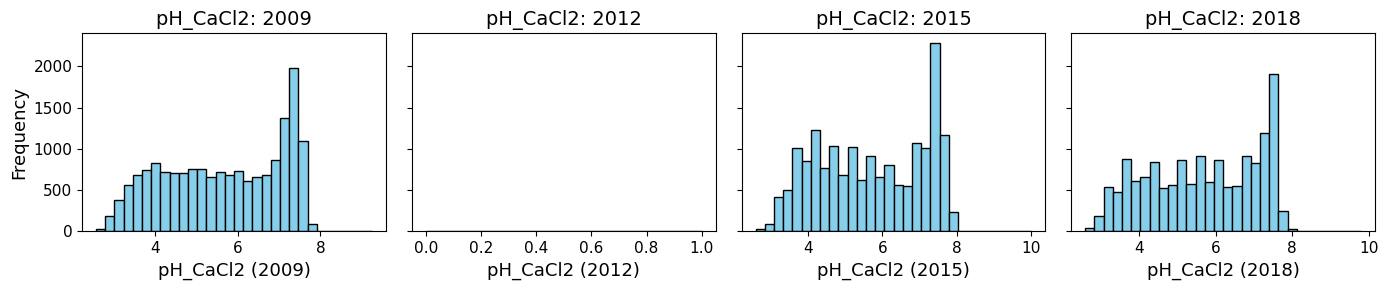

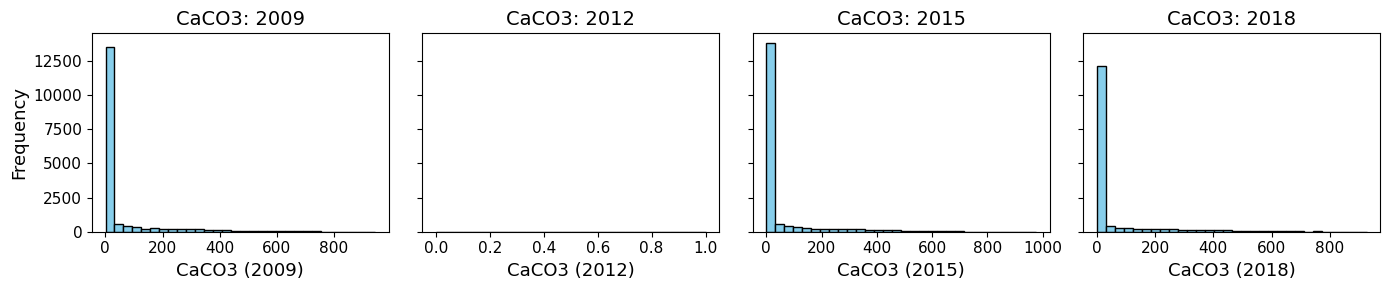

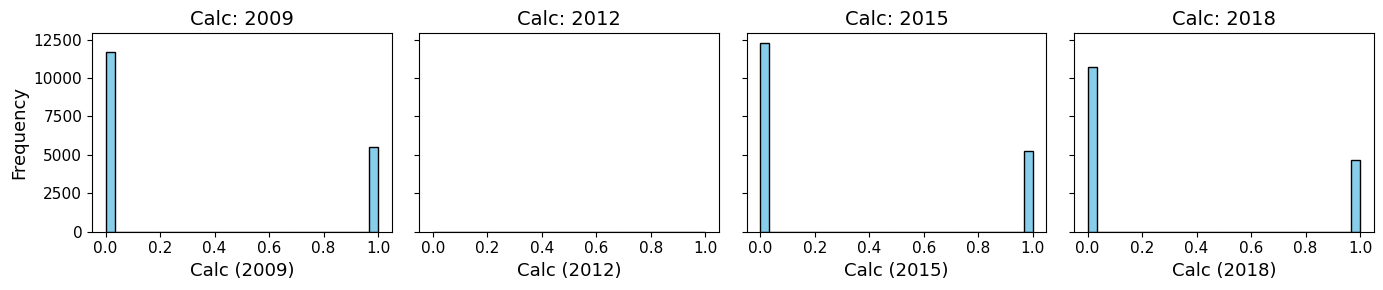

Skipping 'CaCO3_c_log': no year-suffixed columns or raw column found.


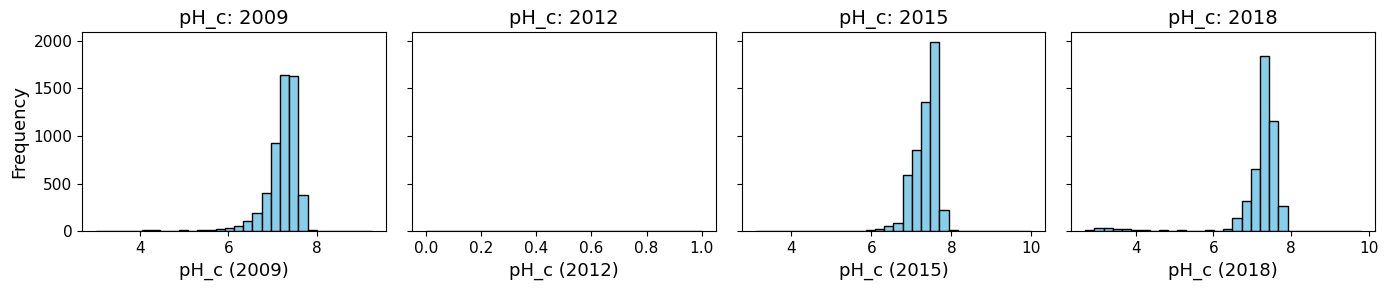

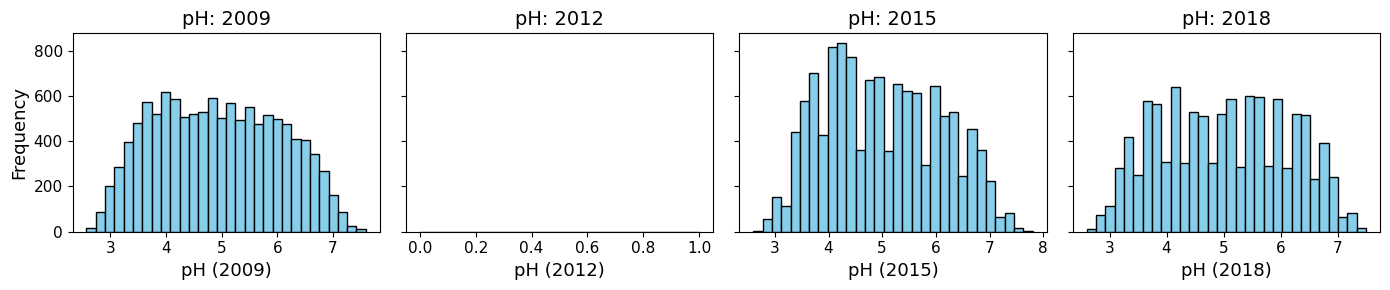

In [24]:
# If CaCO3 >3 then calcareous: replace CaCO3 (content) and pH with:  
# Calc: boolean  
# CaCO3: content (if Calc==True, else nan)  
# pH_c: pH_CaCl2 if Calc==True  
# pH: pH_CaCl2 if Calc==False  

CaCO3_threshold = 3
for year in [2009, 2012, 2015, 2018]:
    # mask CaCO3 > threshold -> count
    print(f"Number of CaCO3_{year} > {CaCO3_threshold} vs <= {CaCO3_threshold}: {(df[f'CaCO3_{year}'] > CaCO3_threshold).sum()} / {(df[f'CaCO3_{year}'] <= CaCO3_threshold).sum()}")
    # create Calc as boolean, keeping NaN where CaCO3 is NaN, but dtype float for histogram compatibility
    vals = df[f'CaCO3_{year}']
    print("First 10 values:", vals.head(10).tolist())
    calc = vals.where(vals.isna(), vals > CaCO3_threshold)   # bool with NaN, but bool dtype
    print("First 10 values:", calc.head(10).tolist())
    print()
    df[f'Calc_{year}'] = calc.astype('float')  # convert True/False to 1.0/0.0, NaN stays NaN
    # CaCO3_c_log: log-transform CaCO3 values above threshold, else NaN
    df[f'CaCO3_c_{year}'] = vals.where(vals > CaCO3_threshold, np.nan)
    # Put pH_CaCl2 values where Calc is True into pH_c, and where Calc is False into pH
    df[f'pH_c_{year}'] = df[f'pH_CaCl2_{year}'].where(df[f'Calc_{year}'] == 1.0, np.nan)
    df[f'pH_{year}'] = df[f'pH_CaCl2_{year}'].where(df[f'Calc_{year}'] == 0.0, np.nan)

for var in ['pH_CaCl2', 'CaCO3', 'Calc', 'CaCO3_c_log', 'pH_c', 'pH']:
    hists(df, var)

# LC change:  
- of only letter
- between 2015 and 2018
- between 2009, 2015 and 2018

# 1-hot encode: Soil Group, LC, LC letter, LC change

In [25]:
# 1-hot encode: LC L2, LC L1 change, Soil Group
categoricals = ['Soil_Group', 
    'lc1_2_2018', 'lc1_2_2015', 'lc1_2_2009']
for i in categoricals:
    dummies = pd.get_dummies(df[i], prefix=i, dummy_na=True)
    print(i, 'classes:', len(dummies.columns))
    df = pd.concat([df, dummies], axis=1)
    print(dummies.columns)

Soil_Group classes: 25
Index(['Soil_Group_Acrisols', 'Soil_Group_Albeluvisols', 'Soil_Group_Andosols',
       'Soil_Group_Anthrosols and Urban Areas', 'Soil_Group_Arenosols',
       'Soil_Group_Calcisols', 'Soil_Group_Cambisols', 'Soil_Group_Chernozems',
       'Soil_Group_Fluvisols', 'Soil_Group_Fluvisols, undifferentiated',
       'Soil_Group_Gleysols', 'Soil_Group_Gypsisols', 'Soil_Group_Histosols',
       'Soil_Group_Kastanozems', 'Soil_Group_Leptosols',
       'Soil_Group_Leptosols (partly permanent snow cover)',
       'Soil_Group_Luvisols', 'Soil_Group_Phaeozems', 'Soil_Group_Planosols',
       'Soil_Group_Podzols', 'Soil_Group_Regosols', 'Soil_Group_Solonchaks',
       'Soil_Group_Umbrisols', 'Soil_Group_Vertisols', 'Soil_Group_nan'],
      dtype='str')
lc1_2_2018 classes: 9
Index(['lc1_2_2018_A', 'lc1_2_2018_B', 'lc1_2_2018_C', 'lc1_2_2018_D',
       'lc1_2_2018_E', 'lc1_2_2018_F', 'lc1_2_2018_G', 'lc1_2_2018_H',
       'lc1_2_2018_nan'],
      dtype='str')
lc1_2_2015 classes:

# Where all 3 years SOC sampled:  
- LinReg -> slope is average change
- average

Number of samples with SOC in all years (2009, 2015, 2018): 12660


/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


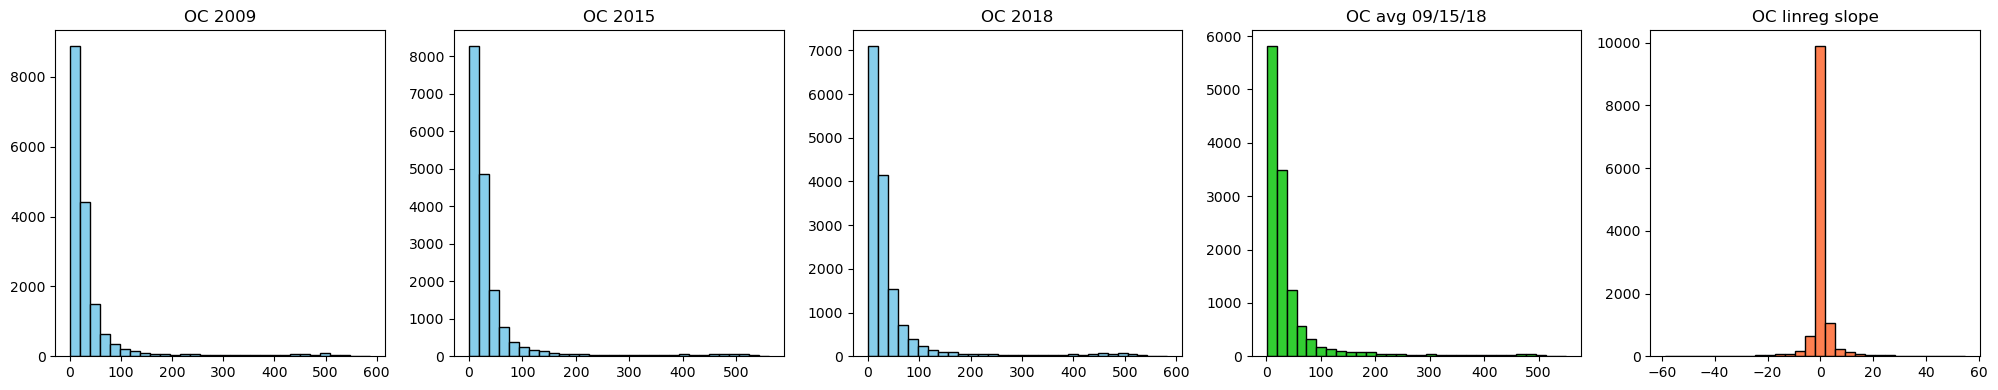

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


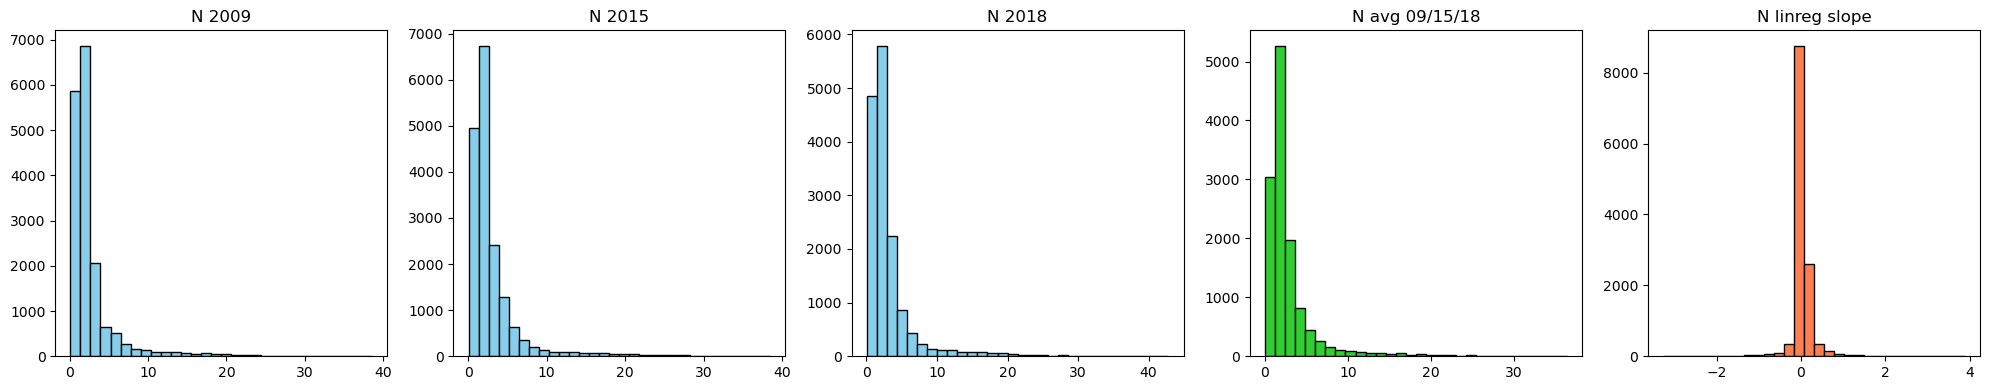

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


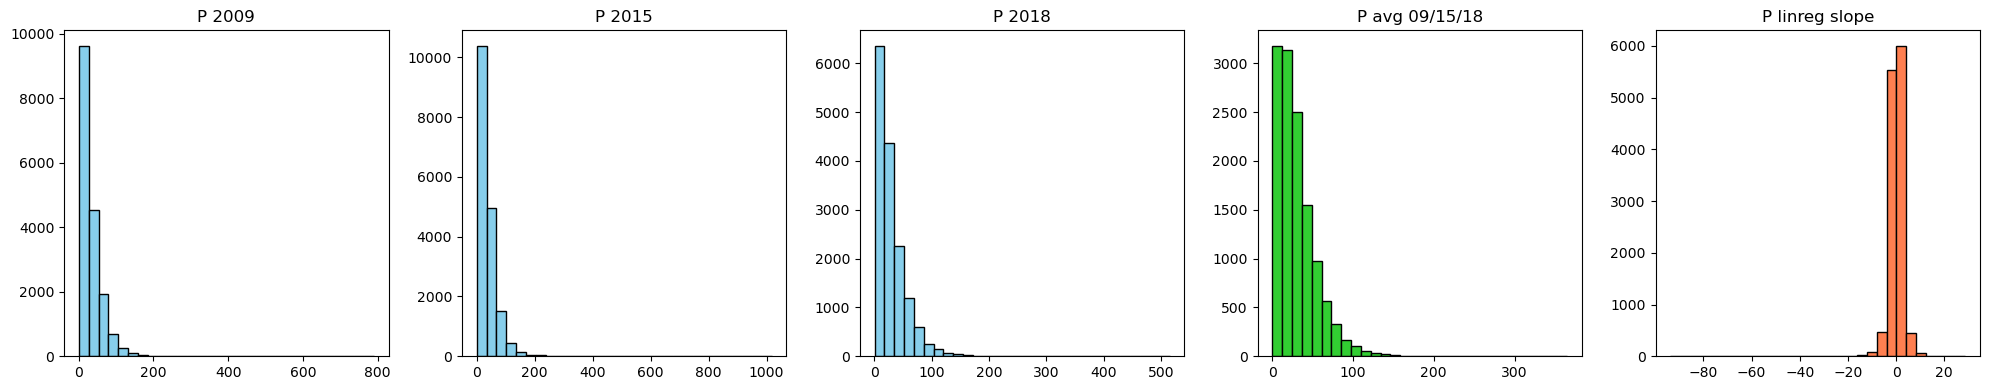

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


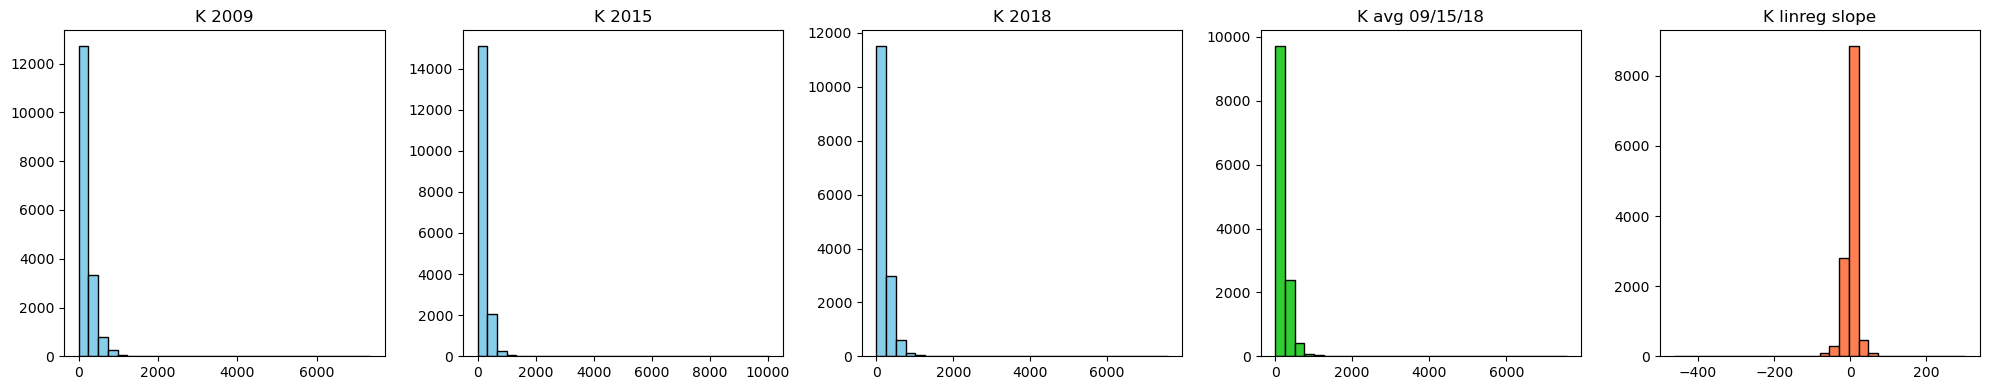

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


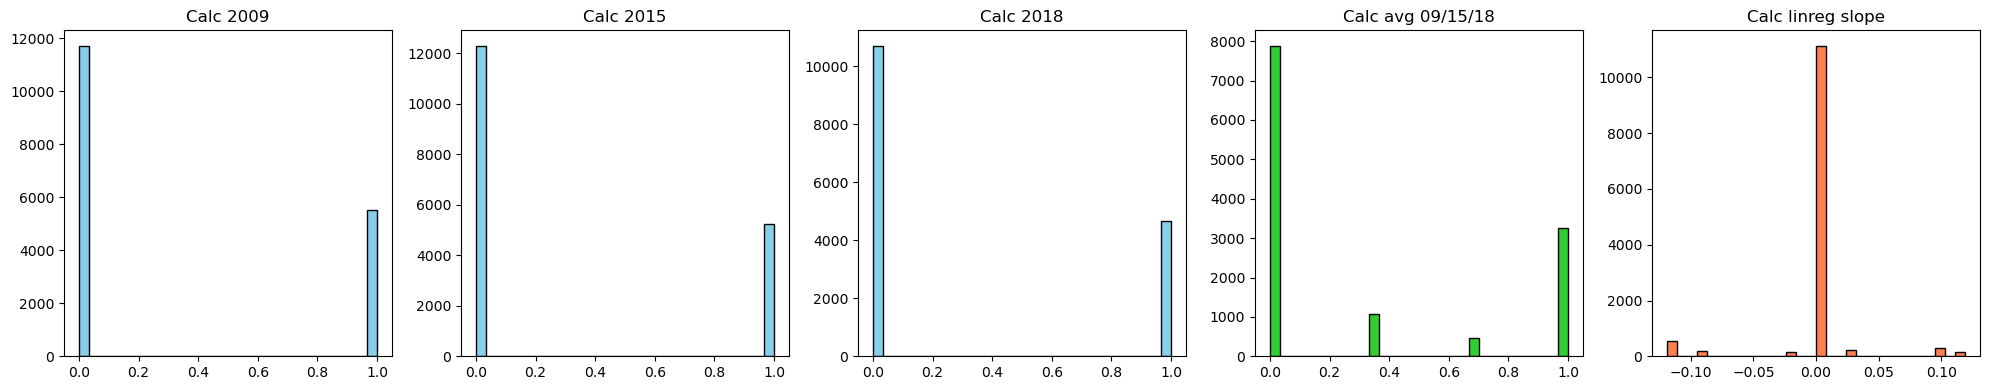

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


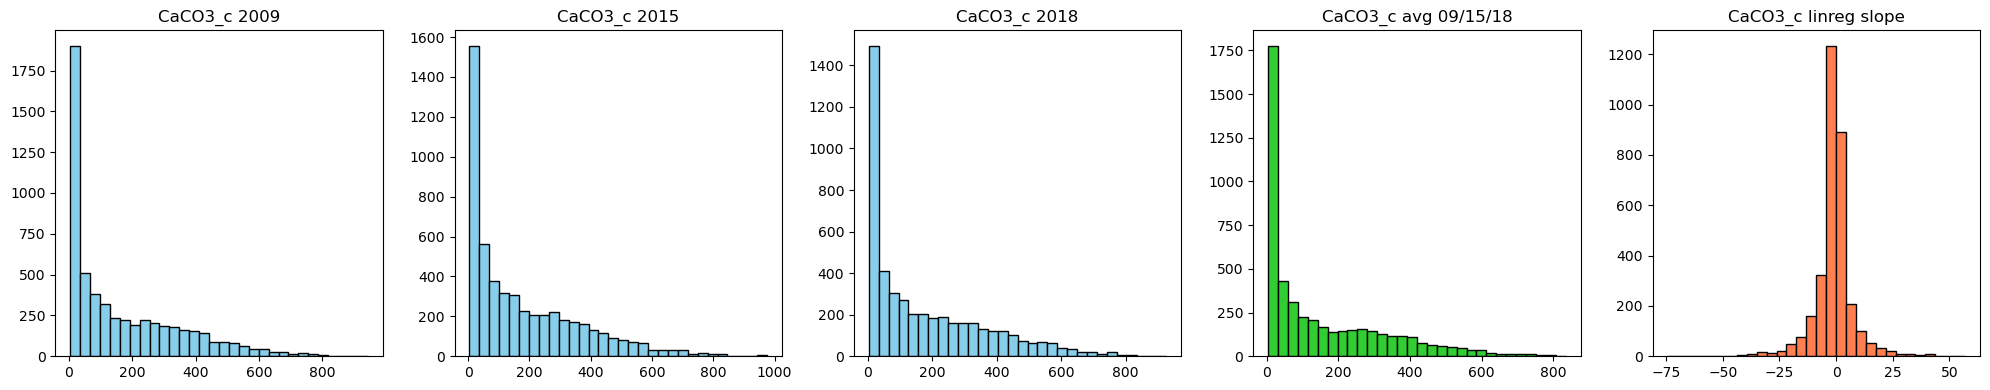

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


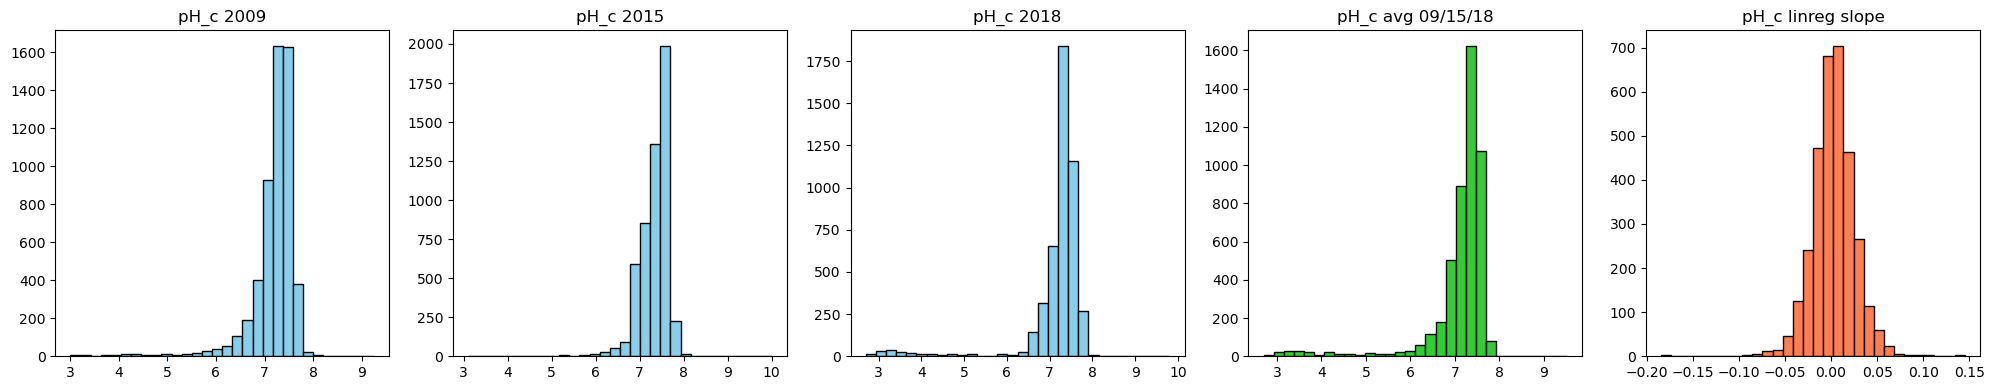

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


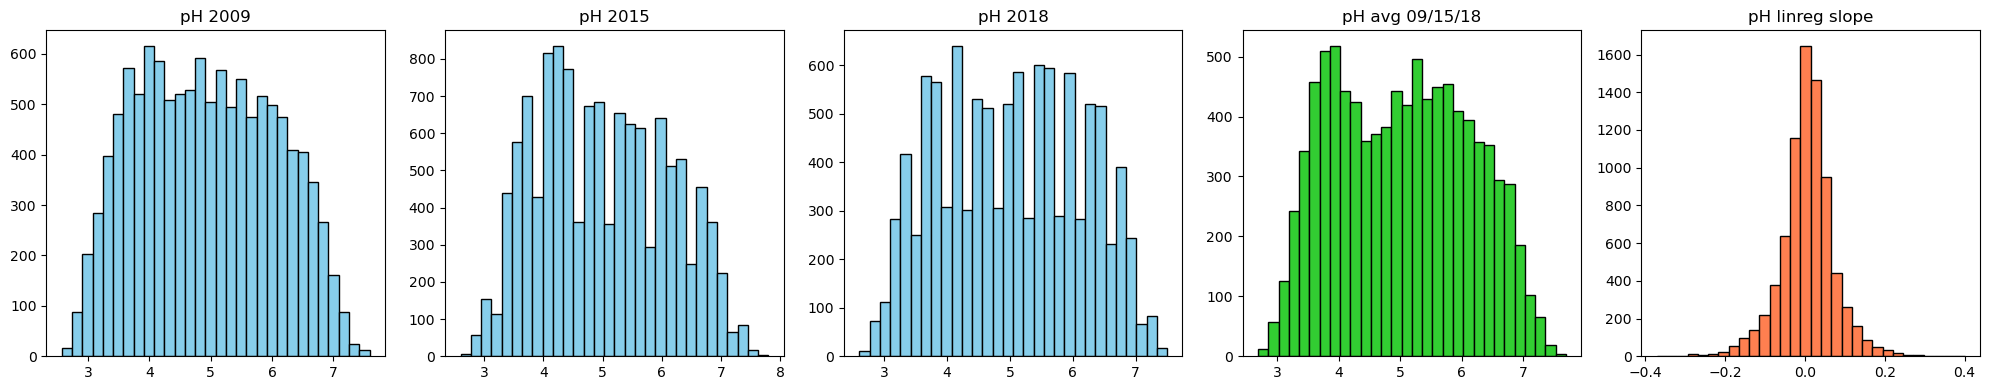

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


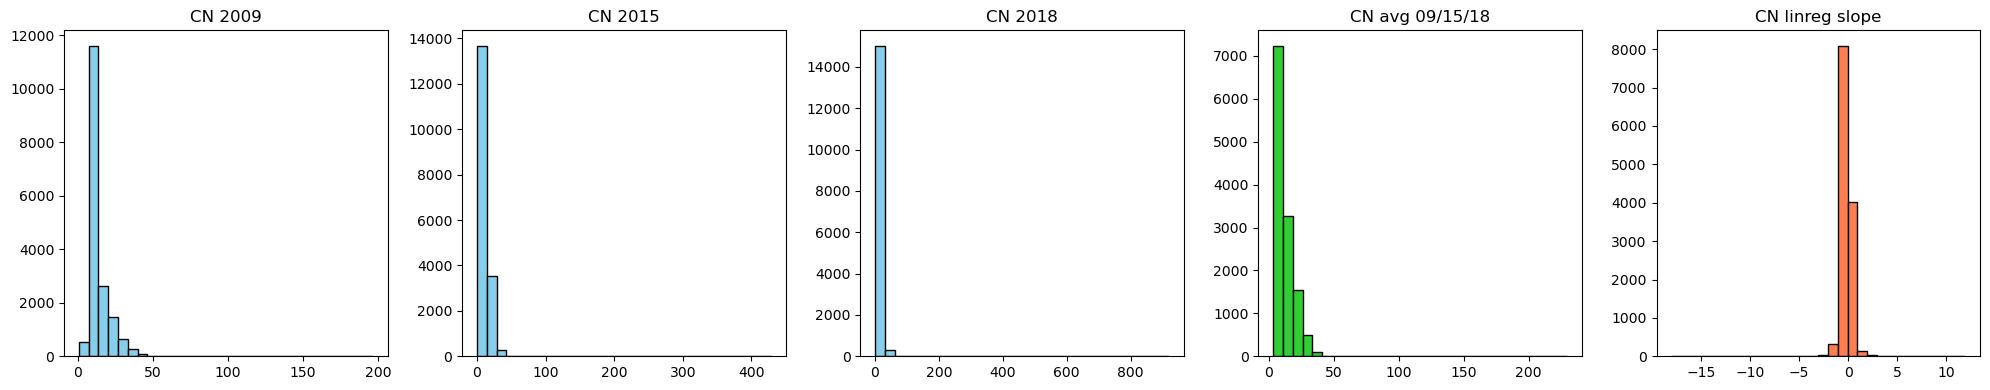

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


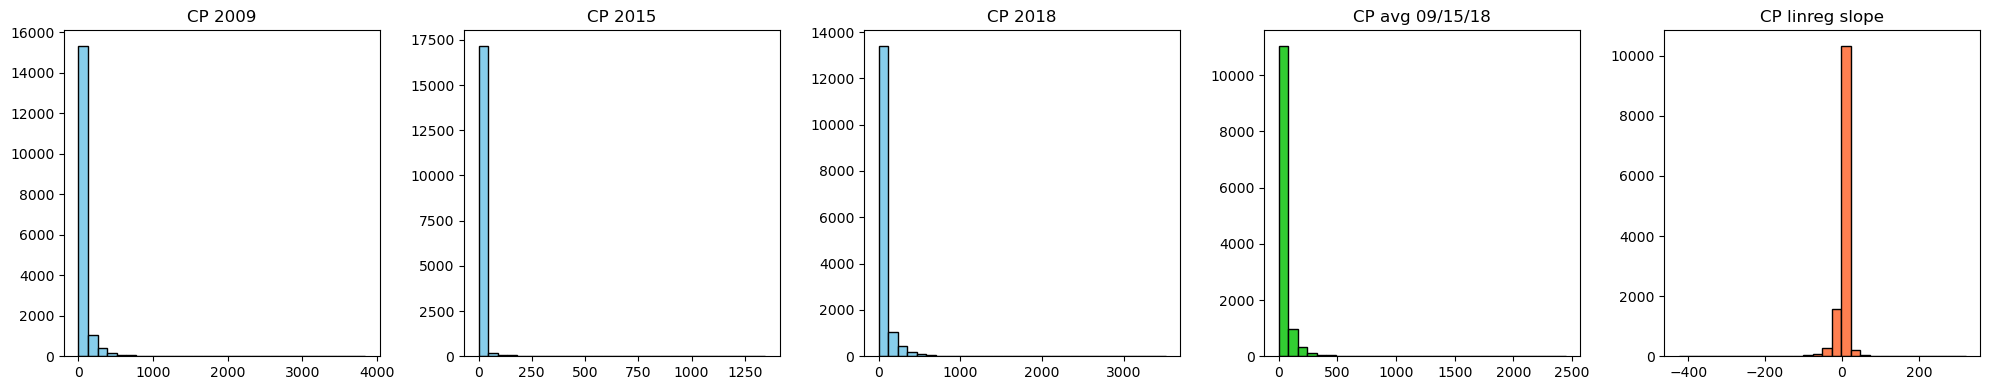

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


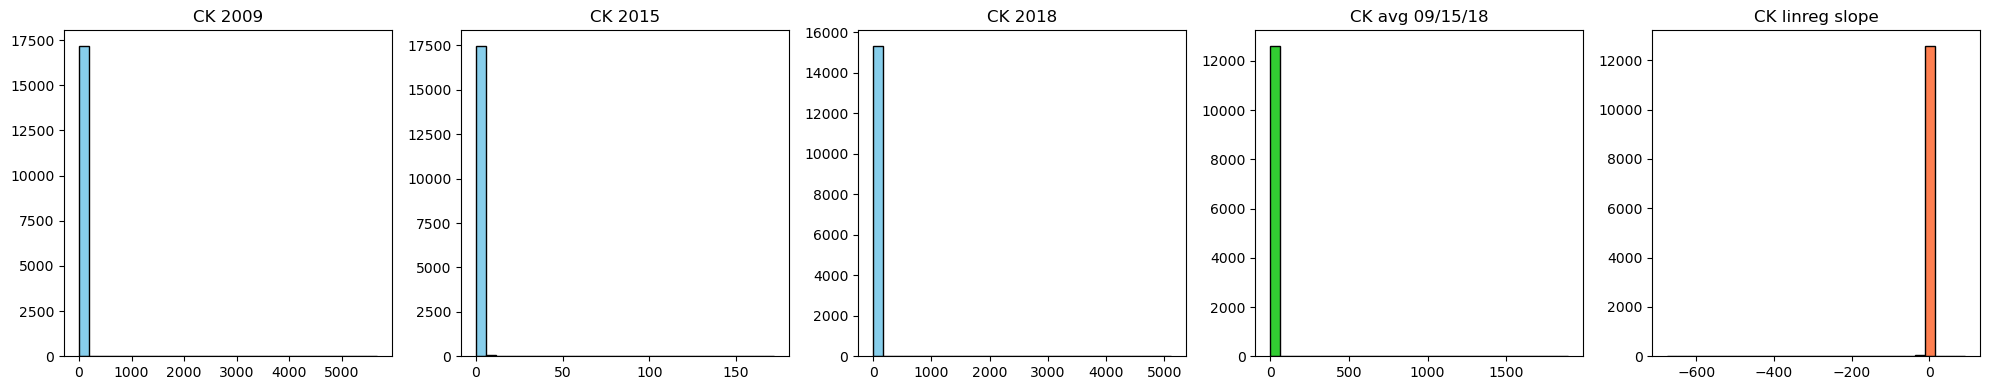

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


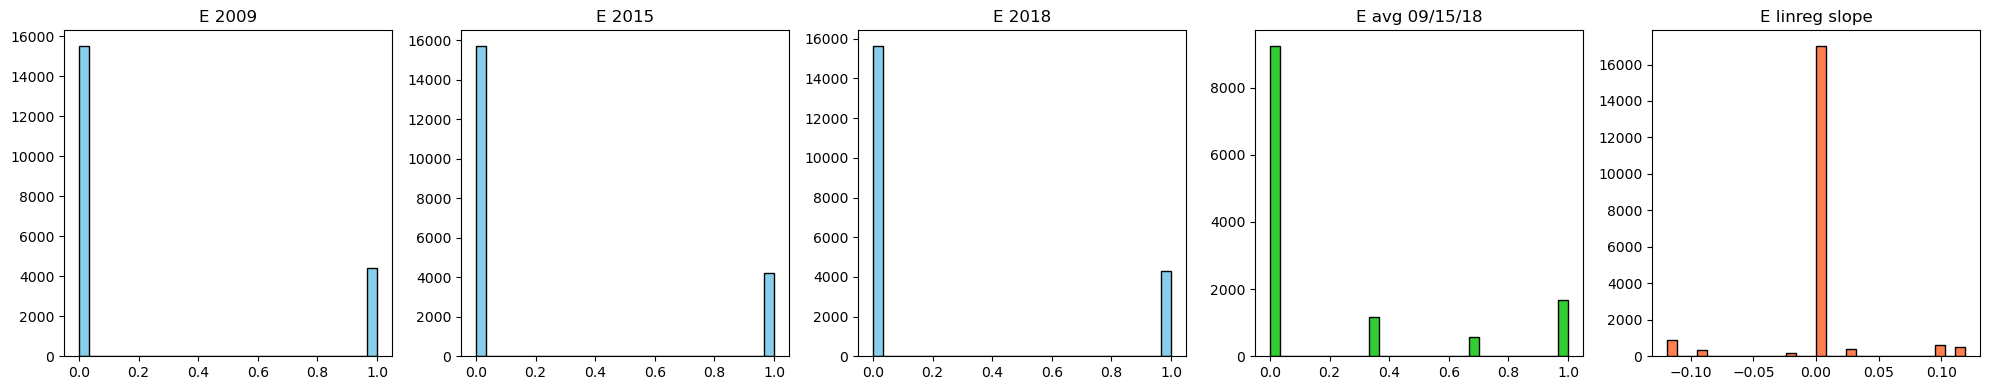

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


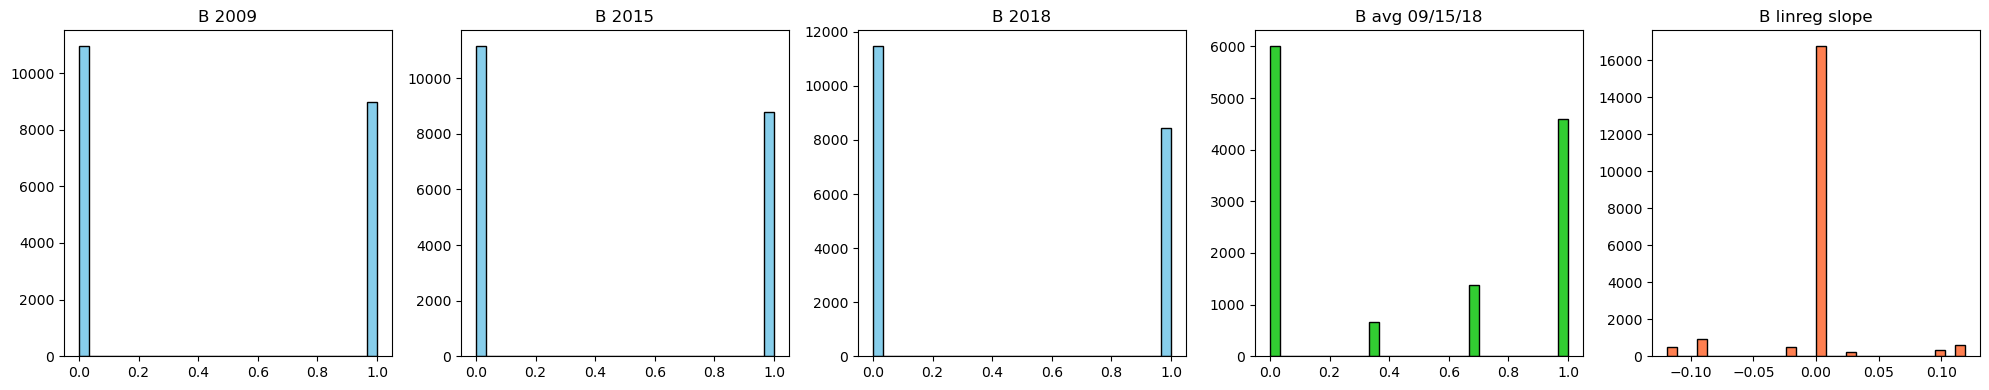

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


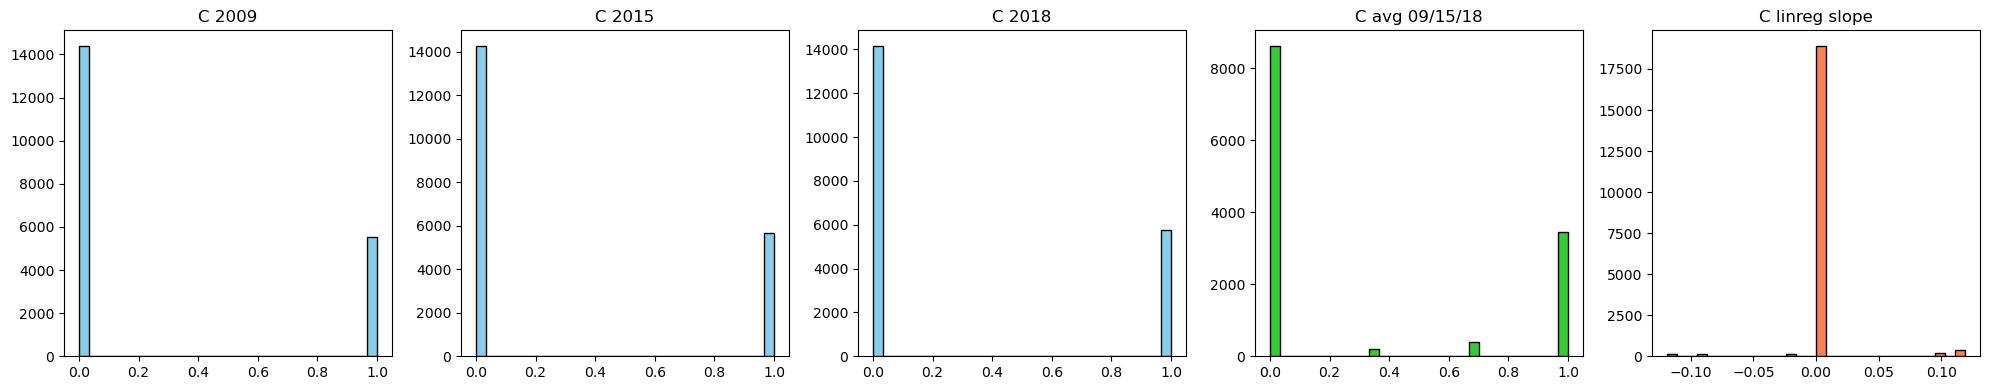

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


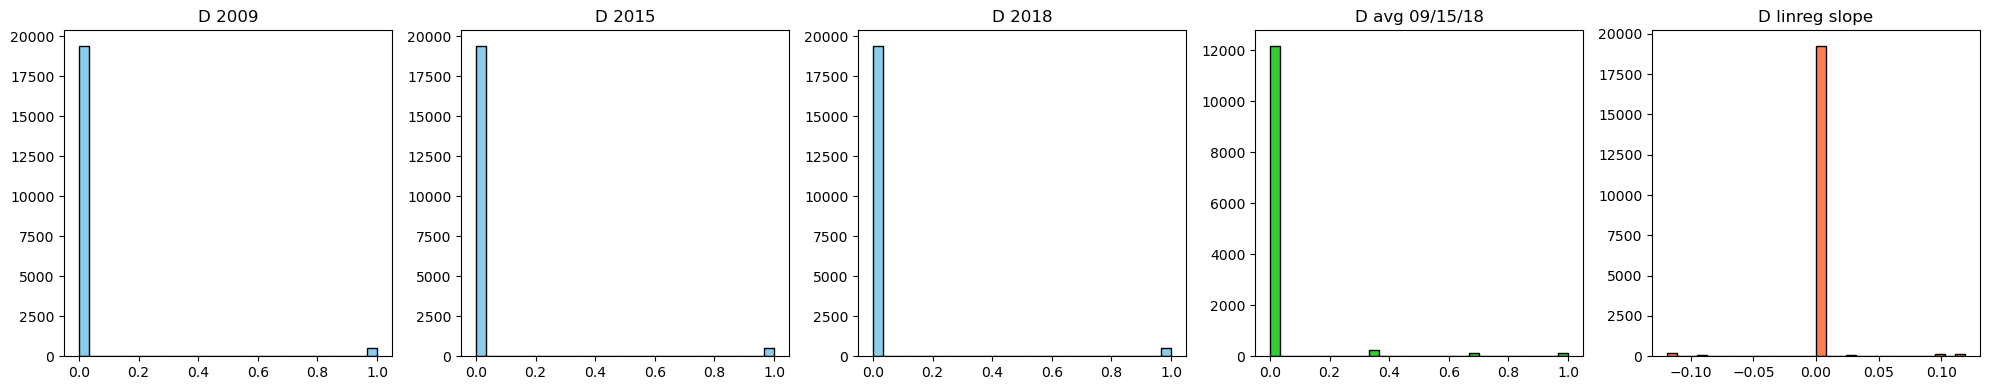

/tmp/ipykernel_3999938/3094354699.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg
/tmp/ipykernel_3999938/3094354699.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = slopes


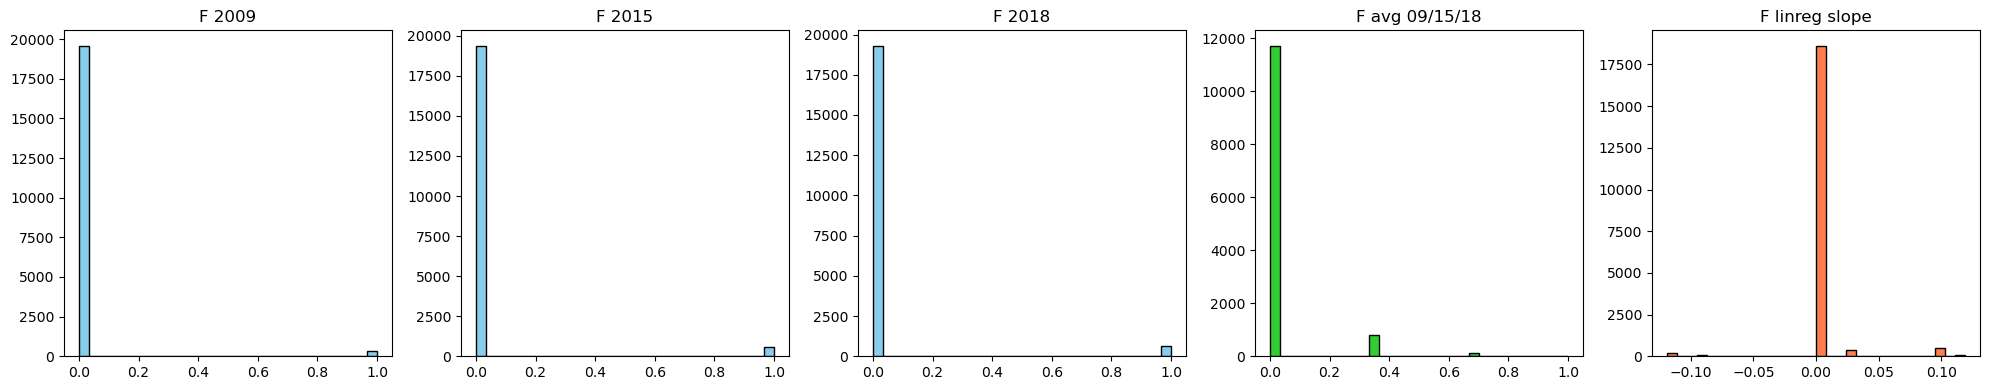

In [26]:
# where exists SOC 09, 15 & 18?
mask = (~df["OC_2009"].isna()) & (~df["OC_2015"].isna()) & (~df["OC_2018"].isna())
print(f"Number of samples with SOC in all years (2009, 2015, 2018): {mask.sum()}")
# do per point LR there -> change
from sklearn.linear_model import LinearRegression

vars = ['OC', 'N', 'P', 'K',  'Calc', 'CaCO3_c', 'pH_c', 'pH', 'CN', 'CP', 'CK']
lc_vars = ['E', 'B', 'C', 'D', 'F',]
for var in vars+lc_vars:
    if var in lc_vars:
        cols = [f"lc1_2_{year}_{var}" for year in [2009, 2015, 2018]]
    else:
        cols = [f"{var}_{year}" for year in [2009, 2015, 2018]]
    # average
    avg = np.full(len(df), np.nan)
    if len(cols) == 3:
        avg[mask] = df.loc[mask, cols].astype(float).mean(axis=1)
        df[f"{var}_avg_09_15_18"] = avg

    # slope
    # lr_slopes = np.full(len(df), np.nan)
    # lr_intercepts = np.full(len(df), np.nan)
    # for idx in df[mask].index:
    #     y = df.loc[idx, [f"{var}_{y}" for y in [2009, 2015, 2018]]].values  # get SOC values of the 3 years
    #     X = np.array([2009, 2015, 2018]).reshape(-1, 1)  # Reshape years to 2D array as required by sklearn
    #     model = LinearRegression().fit(X, y)
    #     lr_slopes[idx], _ = model.coef_[0], model.intercept_
    # df[f"{var}_linreg_slope"] = lr_slopes
    years = np.array([2009, 2015, 2018], dtype=float)
    Y = df[cols].values.astype(float)

    t = years - years.mean()
    slopes = (Y @ t) / (t @ t)

    df[f"{var}_linreg_slope"] = slopes

    # plot distributions
    fig, axs = plt.subplots(1, 5, figsize=(20, 4))
    for i, year in enumerate([2009, 2015, 2018]):
        if var in lc_vars:
            col = f"lc1_2_{year}_{var}"
        else:
            col = f"{var}_{year}"
        if col in df.columns:
            # axs[i].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
            axs[i].hist(df[col].dropna().astype(float), bins=30, color='skyblue', edgecolor='black')
            axs[i].set_title(f"{var} {year}")
        else:
            axs[i].set_visible(False)
    avg_col = f"{var}_avg_09_15_18"
    if avg_col in df.columns:
        # axs[3].hist(df[avg_col].dropna(), bins=30, color='limegreen', edgecolor='black')
        axs[3].hist(df[avg_col].dropna().astype(float), bins=30, color='limegreen', edgecolor='black')
        axs[3].set_title(f"{var} avg 09/15/18")
    else:
        axs[3].set_visible(False)
    slope_col = f"{var}_linreg_slope"
    if slope_col in df.columns:
        # axs[4].hist(df[slope_col].dropna(), bins=30, color='coral', edgecolor='black')
        axs[4].hist(df[slope_col].dropna().astype(float), bins=30, color='coral', edgecolor='black')
        axs[4].set_title(f"{var} linreg slope")
    else:
        axs[4].set_visible(False)
    plt.tight_layout()
    plt.show()

# If distance > 30 m: delete change and averages

In [27]:
# get distances (3) between 3 points
from utils import haversine
for y1, y2 in [[2009, 2015], [2009, 2018], [2015, 2018]]:
    df[f"dist_{y1}_{y2}_m"] = haversine(
        df[f"gps_lat_{y1}"], df[f"gps_long_{y1}"],
        df[f"gps_lat_{y2}"], df[f"gps_long_{y2}"],
    )
# filter where 1 is more than 30 m -> delete change values there
print("Number of non-NaN SOC_linreg_slope values:", df["OC_linreg_slope"].notna().sum())
df.loc[(df["dist_2009_2015_m"] > 30) | (df["dist_2009_2018_m"] > 30) | (df["dist_2015_2018_m"] > 30), "OC_linreg_slope"] = np.nan
print("Number of non-NaN SOC_linreg_slope values:", df["OC_linreg_slope"].notna().sum())

Number of non-NaN SOC_linreg_slope values: 12660
Number of non-NaN SOC_linreg_slope values: 11327


/tmp/ipykernel_3999938/2518468675.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"dist_{y1}_{y2}_m"] = haversine(
/tmp/ipykernel_3999938/2518468675.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"dist_{y1}_{y2}_m"] = haversine(
/tmp/ipykernel_3999938/2518468675.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, u

# Split:  
- 10% Test, 90% Train+Eval
- Train+Eval: 10 folds

In [28]:
from sklearn.model_selection import train_test_split, KFold
seed = 42
n_folds_outter = 10

all_indices = np.arange(len(df))
train_idx, test_idx = train_test_split(all_indices, test_size=0.1, random_state=seed, shuffle=True)
split_labels = np.full(len(df), None, dtype=object)
split_labels[test_idx] = 'test'
for fold_id, (_, val_idx) in enumerate(KFold(n_splits=n_folds_outter, shuffle=True, random_state=seed).split(train_idx)):
    split_labels[train_idx[val_idx]] = fold_id
df = pd.concat([df, pd.Series(split_labels, name="split")], axis=1)

# Add sampling dates as doy

In [29]:
# survey_date to day of year
for year in [2009, 2012, 2015, 2018]:
    df[f'doy_{year}'] = pd.to_datetime(df[f'survey_date_{year}'], format="%d/%m/%y", errors='coerce').dt.dayofyear

/tmp/ipykernel_3999938/18661893.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'doy_{year}'] = pd.to_datetime(df[f'survey_date_{year}'], format="%d/%m/%y", errors='coerce').dt.dayofyear
/tmp/ipykernel_3999938/18661893.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'doy_{year}'] = pd.to_datetime(df[f'survey_date_{year}'], format="%d/%m/%y", errors='coerce').dt.dayofyear
/tmp/ipykernel_3999938/18661893.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` 

# Remove Wetlands & Organic Soils

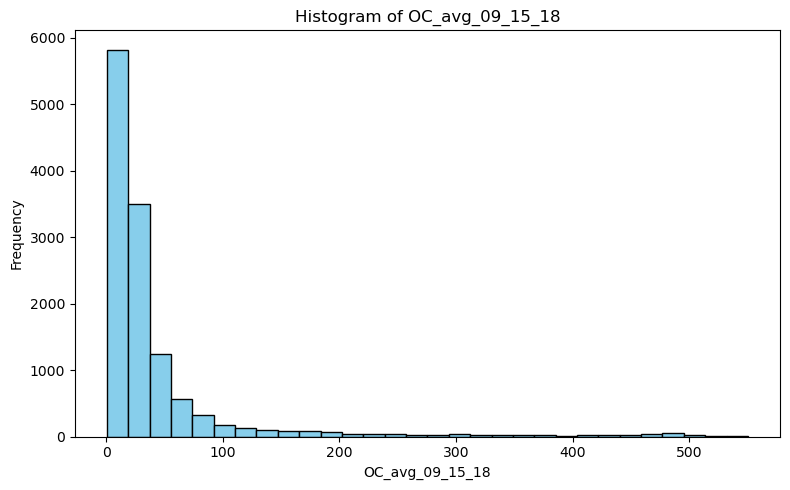

1202     217.033333
1766     181.933333
2232     360.066667
2256     469.233333
2736     203.933333
            ...    
19422    383.133333
19476    306.333333
19494    418.500000
19556    297.633333
19570    180.566667
Name: OC_avg_09_15_18, Length: 631, dtype: float64


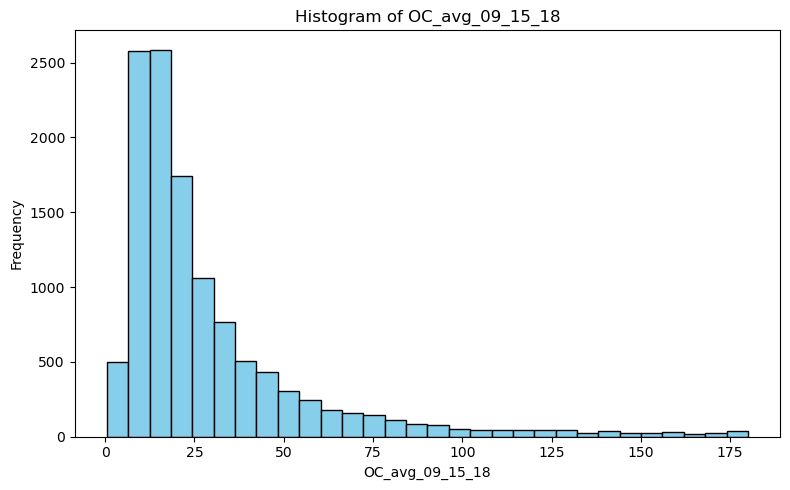

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(df['OC_avg_09_15_18'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('OC_avg_09_15_18')
plt.ylabel('Frequency')
plt.title('Histogram of OC_avg_09_15_18')
plt.tight_layout()
import IPython.display as ipd
ipd.display(plt.gcf())
plt.close()

mask = (
    df['lc1_2_2018'].astype(str).str.contains('G|H', na=False) |
    df['lc1_2_2015'].astype(str).str.contains('G|H', na=False) |
    df['lc1_2_2009'].astype(str).str.contains('G|H', na=False)
)
df = df.loc[~mask].reset_index(drop=True)

mask_oc_high = df['OC_avg_09_15_18'] > 180
print(df.loc[mask_oc_high, 'OC_avg_09_15_18'])
df = df.loc[~mask_oc_high].reset_index(drop=True)

plt.figure(figsize=(8, 5))
plt.hist(df['OC_avg_09_15_18'].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('OC_avg_09_15_18')
plt.ylabel('Frequency')
plt.title('Histogram of OC_avg_09_15_18')
plt.tight_layout()
import IPython.display as ipd
ipd.display(plt.gcf())
plt.close()

# Add NetCDF data

In [31]:
# extract from:
links = [
    {
        'name': "HALA",
        'subs': ['topsoil'],
        'links': ['original_files/topsoil_major_activity_type.nc']
    },
    {
        'name': "BNPP",
        'subs': ['0-20', '20-40', '40-60', '60-80', '80-100', '100-150', '150-200', '0-200'],
        'links': ['original_files/BNPP/BNPP_0-20cm.tif',
                  'original_files/BNPP/BNPP_20-40cm.tif',
                  'original_files/BNPP/BNPP_40-60cm.tif',
                  'original_files/BNPP/BNPP_60-80cm.tif',
                  'original_files/BNPP/BNPP_80-100cm.tif',
                  'original_files/BNPP/BNPP_100-150cm.tif',
                  'original_files/BNPP/BNPP_150-200cm.tif',
                  'original_files/BNPP/BNPP_0-200cm.tif'
                  ]
    },
    {
        'name': "MODIS_NPP",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
        'links': ['/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2001.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2002.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2003.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2004.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2005.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2006.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2007.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2008.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2009.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2010.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2011.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2012.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2013.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2014.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2015.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2016.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2017.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2018.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2019.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2020.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2021.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d00416_annual/MODIS/MOD17A3HGF.061/Data/Npp/Npp.org.86400.43200.2022.nc'
                    ]
    },
    {
        'name': "BIOCLIM",
        'subs': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
        'links': ["/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_1.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_2.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_3.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_4.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_5.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_6.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_7.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_8.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_9.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_10.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_11.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_12.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_13.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_14.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_15.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_16.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_17.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_18.nc",
                "/Net/Groups/BGI/scratch/leorossd/GridRefDB/data/gridded_products/nc_100x100_chunked/WorldClim_historical_climate/bioclimatic_30s/wc2.1_30s_bio_19.nc"
                ]
    },
    {
        'name': "Fluxcom_H",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2001.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2002.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2003.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2004.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2005.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2006.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2007.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2008.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2009.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2010.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2011.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2012.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2013.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2014.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2015.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2016.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2017.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/H/H.4320.2160.2018.nc'
                    ]
    },
    {
        'name': "Fluxcom_LE",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2001.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2002.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2003.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2004.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2005.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2006.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2007.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2008.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2009.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2010.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2011.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2012.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2013.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2014.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2015.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2016.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2017.nc',
                    '/Net/Groups/BGI/data/DataStructureMDI/DATA/grid/Global/0d083_annual/Fluxcom/v1_RS_V006/Data/LE/LE.4320.2160.2018.nc',]
    },
    {
        'name': "era5_land_hpet",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2001.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2002.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2003.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2004.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2005.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2006.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2007.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2008.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2009.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2010.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2011.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2012.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2013.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2014.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2015.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2016.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2017.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/hpet/hpet.annual.era5_land.2018.nc',]
    },
    {
        'name': "era5_land_t2m",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2001.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2002.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2003.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2004.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2005.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2006.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2007.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2008.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2009.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2010.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2011.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2012.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2013.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2014.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2015.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2016.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2017.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/t2m/t2m.annual.era5_land.2018.nc',]
    },
    {
        'name': "era5_land_tp",
        'subs': [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
        'links': ['/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2001.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2002.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2003.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2004.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2005.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2006.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2007.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2008.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2009.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2010.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2011.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2012.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2013.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2014.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2015.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2016.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2017.nc',
                    '/Net/Groups/data_BGC/era5_land/e1/0d10_annual/tp/tp.annual.era5_land.2018.nc',]
    }
]

import netCDF4 as nc
import pandas as pd
import xarray as xr
import rasterio
from rasterio.warp import transform
import numpy as np
def inquire_netcdf_values(nc_file_path, coordinates):
    if nc_file_path.endswith('.tif') or nc_file_path.endswith('.tiff'):
        return _extract_from_tif(nc_file_path, coordinates)
    return _extract_from_netcdf(nc_file_path, coordinates)
def _extract_from_tif(tif_file_path, coordinates):
    with rasterio.open(tif_file_path) as src:
        src_crs = src.crs
        raster_coords = []
        for lat, lon in coordinates:
            if src_crs != 'EPSG:4326':
                x, y = transform('EPSG:4326', src_crs, [lon], [lat])
                raster_coords.append((x[0], y[0]))
            else:
                raster_coords.append((lon, lat))
        values = []
        for x, y in raster_coords:
            row, col = src.index(x, y)
            if 0 <= row < src.height and 0 <= col < src.width:
                value = src.read(1, window=((row, row+1), (col, col+1)))[0, 0]
                values.append(float(value))
            else:
                values.append(np.nan)
        return values
def _extract_from_netcdf(nc_file_path, coordinates):
    dataset_nc = nc.Dataset(nc_file_path)
    try:
        lat_str = 'latitude'
        lon_str = 'longitude'
        lat = dataset_nc.variables[lat_str][:]
        lon = dataset_nc.variables[lon_str][:]
    except:
        lat_str = 'lat'
        lon_str = 'lon'
        lat = dataset_nc.variables[lat_str][:]
        lon = dataset_nc.variables[lon_str][:]
    band_names = ''
    any_band = []
    for var_name in dataset_nc.variables:
        if var_name not in ['crs', 'time', lat_str, lon_str]:
            band_names += var_name + ', '
            any_band.append(var_name)
    band_names = [band_names[:-2]]
    var = dataset_nc.variables[any_band[0]]
    try:
        chunking = var.chunking()
        if chunking != 'contiguous' and isinstance(chunking, (tuple, list)) and len(chunking) >= 2:
            lat_chunk_size, lon_chunk_size = chunking[0], chunking[1]
        else:
            lat_chunk_size = lon_chunk_size = None
    except Exception:
        lat_chunk_size = lon_chunk_size = None
    ds = xr.open_dataset(nc_file_path)
    if lat_chunk_size is not None and lon_chunk_size is not None:
        ds = ds.chunk({lat_str: lat_chunk_size, lon_str: lon_chunk_size})
    latitudes = np.array([coord[0] for coord in coordinates])
    longitudes = np.array([coord[1] for coord in coordinates])
    values_at_coords = ds[any_band[0]].sel({lat_str: xr.DataArray(latitudes, dims='points'), lon_str: xr.DataArray(longitudes, dims='points')}, method='nearest')
    v = np.asarray(np.ma.filled(values_at_coords.compute().values, np.nan))
    n = len(coordinates)
    if v.ndim == 0:
        v = np.array([float(v)])
    elif v.shape != (n,):
        i = next(j for j, s in enumerate(v.shape) if s == n)
        v = np.moveaxis(v, i, 0).reshape(n, -1)[:, 0]
    if v.size and not np.isfinite(v).any():
        print(f"4_add_nc: only NaNs extracted - {nc_file_path}")
    return [float(x) if np.isfinite(x) else np.nan for x in v]

def add(lat_str, long_str, gps_year):
    global df
    lat = df[lat_str].to_numpy(dtype=float)
    lon = df[long_str].to_numpy(dtype=float)

    valid_mask = np.isfinite(lat) & np.isfinite(lon)

    coordinates = list(zip(lat[valid_mask], lon[valid_mask]))

    new_cols = {}
    for new in links:
        for i, sub in enumerate(new['subs']):
            col = f"{new['name']}_{gps_year}gps_{sub}"
            print(col)

            values = np.full(len(df), np.nan)

            if coordinates:
                queried = inquire_netcdf_values(new['links'][i], coordinates)
                values[valid_mask] = queried

            new_cols[col] = values

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

add('gps_lat_2009', 'gps_long_2009', 2009)
add('gps_lat_2015', 'gps_long_2015', 2015)
add('gps_lat_2018', 'gps_long_2018', 2018)

HALA_2009gps_topsoil
BNPP_2009gps_0-20
BNPP_2009gps_20-40
BNPP_2009gps_40-60
BNPP_2009gps_60-80
BNPP_2009gps_80-100
BNPP_2009gps_100-150
BNPP_2009gps_150-200
BNPP_2009gps_0-200
MODIS_NPP_2009gps_2001
MODIS_NPP_2009gps_2002
MODIS_NPP_2009gps_2003
MODIS_NPP_2009gps_2004
MODIS_NPP_2009gps_2005
MODIS_NPP_2009gps_2006
MODIS_NPP_2009gps_2007
MODIS_NPP_2009gps_2008
MODIS_NPP_2009gps_2009
MODIS_NPP_2009gps_2010
MODIS_NPP_2009gps_2011
MODIS_NPP_2009gps_2012
MODIS_NPP_2009gps_2013
MODIS_NPP_2009gps_2014
MODIS_NPP_2009gps_2015
MODIS_NPP_2009gps_2016
MODIS_NPP_2009gps_2017
MODIS_NPP_2009gps_2018
MODIS_NPP_2009gps_2019
MODIS_NPP_2009gps_2020
MODIS_NPP_2009gps_2021
MODIS_NPP_2009gps_2022
BIOCLIM_2009gps_1
BIOCLIM_2009gps_2
BIOCLIM_2009gps_3
BIOCLIM_2009gps_4
BIOCLIM_2009gps_5
BIOCLIM_2009gps_6
BIOCLIM_2009gps_7
BIOCLIM_2009gps_8
BIOCLIM_2009gps_9
BIOCLIM_2009gps_10
BIOCLIM_2009gps_11
BIOCLIM_2009gps_12
BIOCLIM_2009gps_13
BIOCLIM_2009gps_14
BIOCLIM_2009gps_15
BIOCLIM_2009gps_16
BIOCLIM_2009gps_17
BIO

# Input via MODIS NPP + LC info

In [32]:
RS_ef_HI = {
    'A': (      0.00,                    # artificial land: no biomass
            0.00,                        # no roots
            0.00 ),                      # no harvest
    'B': (      0.125,               # cropland: 0.1 to 0.5, cereals ~0.15
            0.965,                  # typical for crops (shallow roots)
            0.5 ),                # grain crops
    'C': (      0.25,             # global forest average
            0.92,                  # deeper rooted than crops
            0.50 ),                     # timber fraction of aboveground biomass
    'D': (      1.68,             # shrubland global average
            0.97,                  # intermediate (deeper than grass)
            0.33 ),                     # non‑crop removal fraction
    'E': (      5.5,                 # highest R:S of any biome
            0.98,                  # very shallow roots (β near 1)
            0.33 ),                     # grazing / biomass removal
    'H': (      0.00,                    # bare land / sparse vegetation
            0.00,                       # no root system
            0.00 ),                     # no harvest
    'F': (      1.0,                 # wetland plants (variable)
            0.965,                  # often shallow‑rooted
            0.33 )                      # harvest similar to grassland
}

# check data:
# Mokany, K., Raison, R.J. and Prokushkin, A.S. (2006). Critical analysis of root : shoot ratios in terrestrial biomes. Global Change Biology, 12(1), pp.84–96.
# Schenk, H.J. and Jackson, R.B. (2002). The global biogeography of roots. Ecological Monographs, 72(3), pp.311–328.
# Hay, R.K.M. (1995). Harvest index: a review of its use in plant breeding and crop production. Outlook on Agriculture, 24(1), pp.9–16.

import numpy as np
import pandas as pd

def root_litterinput(z, e_fold_depth):
    return 1 - np.exp(-z / e_fold_depth)

def fraction_litterinputs(upper, lower, e_fold_depth):
    """Compute the fraction of the root litter inputs processed between two depths."""
    upper_root_litter = root_litterinput(upper, e_fold_depth)
    lower_root_litter = root_litterinput(lower, e_fold_depth)
    return lower_root_litter - upper_root_litter

years = [2018, 2015, 2009]
for year in years:
    input_year_vals = []
    for idx, row in df.iterrows():
        # get NPP and LC
        npp_minus_0 = row[f'MODIS_NPP_{year}gps_{year-0}']
        npp_minus_1 = row[f'MODIS_NPP_{year}gps_{year-1}']
        npp_minus_2 = row[f'MODIS_NPP_{year}gps_{year-2}']
        npp_minus_3 = row[f'MODIS_NPP_{year}gps_{year-3}']
        npp_minus_4 = row[f'MODIS_NPP_{year}gps_{year-4}']
        npp = np.mean([npp_minus_0, npp_minus_1, npp_minus_2, npp_minus_3, npp_minus_4])
        lc = row[f'lc1_{year}']
        if pd.isna(lc) or pd.isna(npp):
            input_year_vals.append(np.nan)
            continue
        letter = lc[0]
        if letter in ['A', 'H']: # in case of artificial and bare land use grass land values (artificial probably still underestimates input as MODIS value lower than at site; bare land wouldn't work with 0 inputs)
            letter = 'E'
        # get root and shoot of NPP
        RS = RS_ef_HI[letter][0]
        root_npp = npp * RS / (1 + RS)
        shoot_npp = npp * 1 / (1 + RS)
        # get remains of shoot
        HI = RS_ef_HI[letter][2]
        remains = (1-HI) * shoot_npp
        # get roots 0-20
        efd = RS_ef_HI[letter][1]
        zero_20 = root_npp * fraction_litterinputs(0.0, 0.2, efd)
        # input
        input_val = zero_20 + remains
        input_year_vals.append(input_val)
    df[f'input_{year}'] = input_year_vals
        

/tmp/ipykernel_3999938/1485740418.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'input_{year}'] = input_year_vals
/tmp/ipykernel_3999938/1485740418.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'input_{year}'] = input_year_vals
/tmp/ipykernel_3999938/1485740418.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fra

# Calculate 5 year means (and changes) of weather

In [33]:
# calculate means of sampling year -5 for all 3 sampling years
mean_cols = {}
for year in [2009, 2015, 2018]:
    for var in ['Fluxcom_H', 'Fluxcom_LE', 'era5_land_t2m', 'era5_land_tp', 'era5_land_hpet', 'MODIS_NPP']:
        # get values of years -5
        var_minus_0 = df[f'{var}_{year}gps_{year-0}']
        var_minus_1 = df[f'{var}_{year}gps_{year-1}']
        var_minus_2 = df[f'{var}_{year}gps_{year-2}']
        var_minus_3 = df[f'{var}_{year}gps_{year-3}']
        var_minus_4 = df[f'{var}_{year}gps_{year-4}']
        # get mean
        mean_value = np.mean([var_minus_0, var_minus_1, var_minus_2, var_minus_3, var_minus_4], axis=0)
        # insert
        mean_cols[f'{var}_{year}-5_mean'] = mean_value
        print('added:', f'{var}_{year}-5_mean')
df = pd.concat([df, pd.DataFrame(mean_cols, index=df.index)], axis=1)


from sklearn.linear_model import LinearRegression

all_years = [2009, 2015, 2018]
simple_vars = ['doy', 'tree_height_survey', 'grazing', 'wm', 'soil_stones_perc', 'soil_crop']

for var in ['doy', 'tree_height_survey', 'grazing', 'wm', 'soil_stones_perc', 'Fluxcom_H', 'Fluxcom_LE', 'era5_land_t2m', 'era5_land_tp', 'era5_land_hpet', 'MODIS_NPP', 'soil_crop']:
    print(var)
    if var in simple_vars:
        year_cols = {yr: f"{var}_{yr}" for yr in all_years}
    else:
        year_cols = {yr: f"{var}_{yr}-5_mean" for yr in all_years}

    # Require at least 2 non-NaN years
    non_na_counts = sum(~df[col].isna() for col in year_cols.values())
    mask = non_na_counts >= 2

    lr_slopes = np.full(len(df), np.nan)

    for idx in df[mask].index:
        # Select only years with non-NaN values for this row
        valid = [(yr, year_cols[yr]) for yr in all_years if not pd.isna(df.loc[idx, year_cols[yr]])]
        yrs = np.array([yr for yr, _ in valid]).reshape(-1, 1)
        y = df.loc[idx, [col for _, col in valid]].values.astype(float)
        model = LinearRegression().fit(yrs, y)
        lr_slopes[idx] = model.coef_[0]

    df[f"{var}_linreg_slope"] = lr_slopes

    cols = [col for col in year_cols.values() if col in df.columns]
    avg = np.full(len(df), np.nan)
    if len(cols) >= 2:
        avg[mask] = df.loc[mask, cols].apply(pd.to_numeric, errors='coerce').mean(axis=1)
    df[f"{var}_avg_09_15_18"] = avg

added: Fluxcom_H_2009-5_mean
added: Fluxcom_LE_2009-5_mean
added: era5_land_t2m_2009-5_mean
added: era5_land_tp_2009-5_mean
added: era5_land_hpet_2009-5_mean
added: MODIS_NPP_2009-5_mean
added: Fluxcom_H_2015-5_mean
added: Fluxcom_LE_2015-5_mean
added: era5_land_t2m_2015-5_mean
added: era5_land_tp_2015-5_mean
added: era5_land_hpet_2015-5_mean
added: MODIS_NPP_2015-5_mean
added: Fluxcom_H_2018-5_mean
added: Fluxcom_LE_2018-5_mean
added: era5_land_t2m_2018-5_mean
added: era5_land_tp_2018-5_mean
added: era5_land_hpet_2018-5_mean
added: MODIS_NPP_2018-5_mean
doy


/tmp/ipykernel_3999938/2751811745.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = lr_slopes
/tmp/ipykernel_3999938/2751811745.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg


tree_height_survey


/tmp/ipykernel_3999938/2751811745.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = lr_slopes
/tmp/ipykernel_3999938/2751811745.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg


grazing


...

/tmp/ipykernel_3999938/2751811745.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = lr_slopes
/tmp/ipykernel_3999938/2751811745.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg


MODIS_NPP


/tmp/ipykernel_3999938/2751811745.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = lr_slopes
/tmp/ipykernel_3999938/2751811745.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg


soil_crop


/tmp/ipykernel_3999938/2751811745.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_linreg_slope"] = lr_slopes
/tmp/ipykernel_3999938/2751811745.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{var}_avg_09_15_18"] = avg


# Save

In [34]:
import pickle
df = df.fillna(np.nan)
with open("1_preprocessed_intermediate.pkl", "wb") as f:
    pickle.dump(df, f)

# Plot potential predictors and their distribution

In [35]:
from config import TARGET_CONFIG, pred_groups
import pickle

with open("1_preprocessed_intermediate.pkl", "rb") as f:
    df = pickle.load(f)

for pred_group in pred_groups:
    for pred_sub_group in pred_groups[pred_group]:
        if pred_sub_group == 'color':
            continue
        for pred in pred_groups[pred_group][pred_sub_group]:
            var_name = pred_groups[pred_group][pred_sub_group][pred]
            if not var_name in df.columns:
                print(pred_group, pred_sub_group, pred, pred_groups[pred_group][pred_sub_group][pred])

# loop over pred_groups
    # new col for each group
# loop over targets
    # loop over predictors
        # find associated group
        # finda associated sub_group
        # into group col with sub_group value
# loop over pred_groups
    # get color for column


# Feature Relevance and Clusters via Mutual Information
### Relevance
- MI between each predictor and the target
### Clusters
- MI for each predictor pair. 
- Vektor per predictor with all MI values. 
- Euclidian distance between all predictors. 
- Closest two are merged after each other until one cluster.

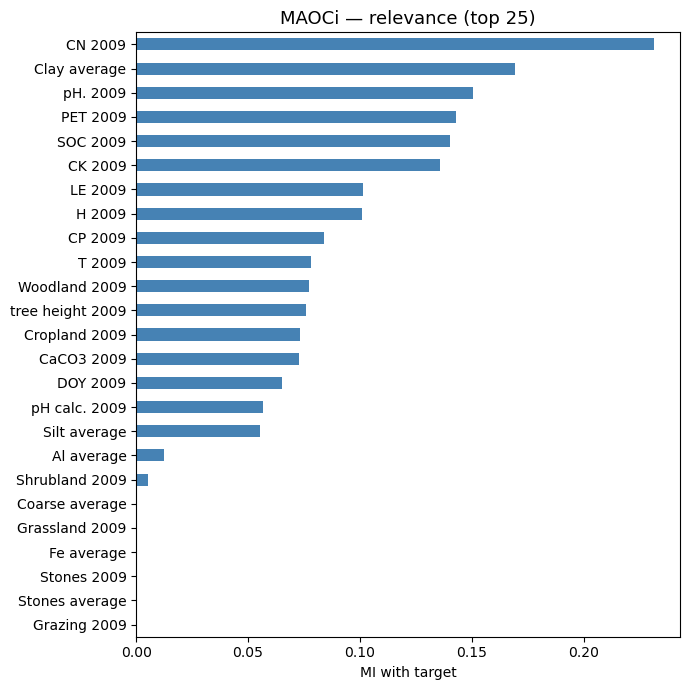

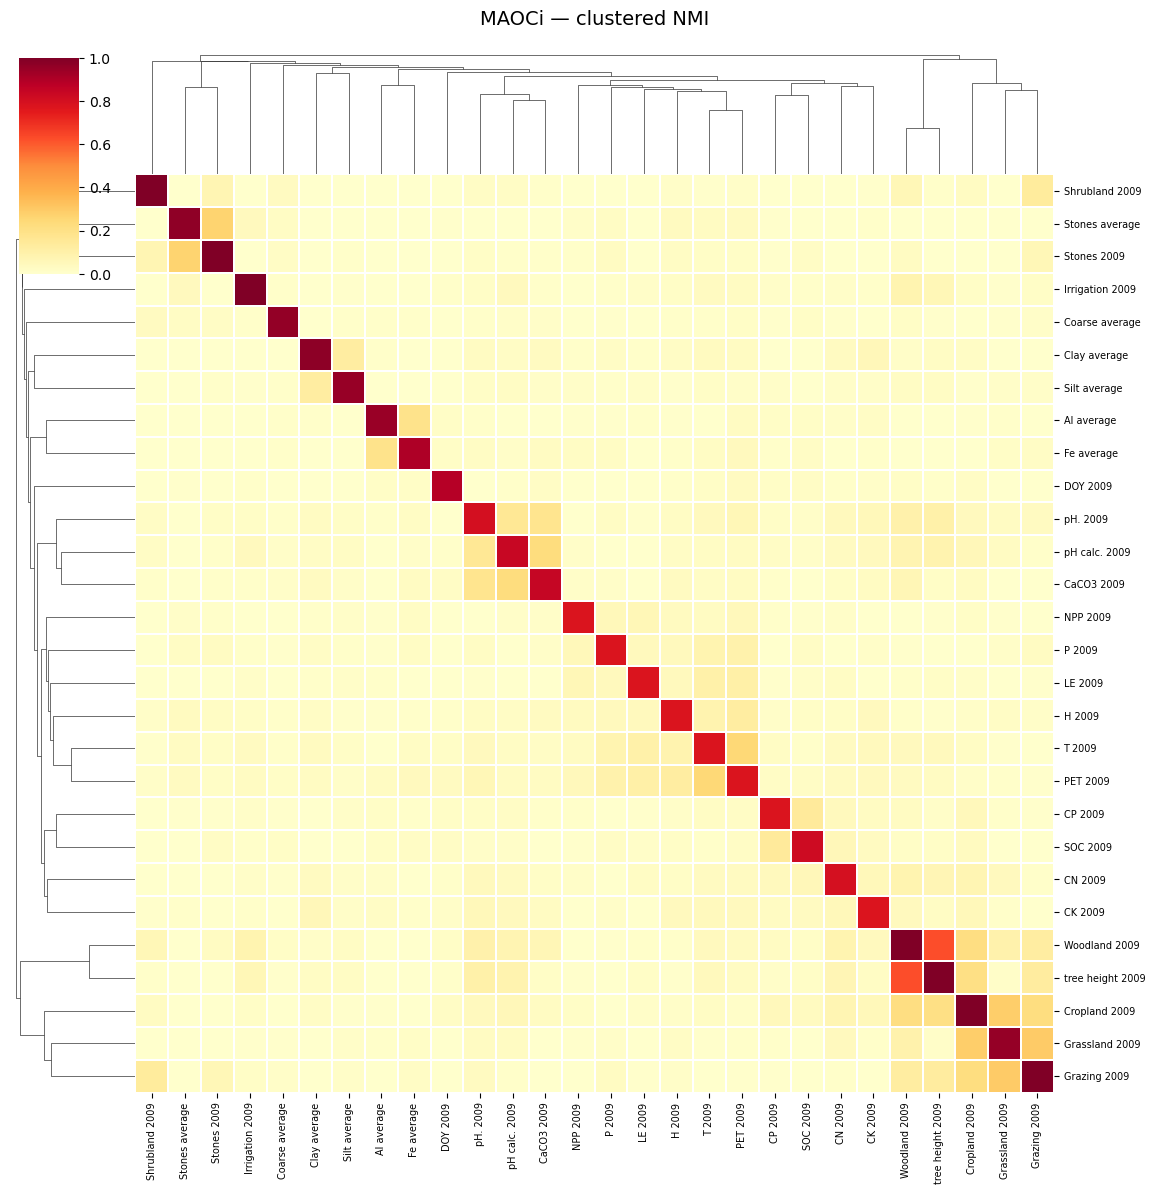


=== MAOCi: top redundant pairs (NMI >= 0.0) ===


,feature_a,feature_b,NMI,MI_a,MI_b
261,Woodland 2009,tree height 2009,0.626,0.0774,0.0760
228,Grassland 2009,Grazing 2009,0.294,0.0000,0.0000
225,Grassland 2009,Cropland 2009,0.287,0.0000,0.0731
78,Stones average,Stones 2009,0.267,0.0000,0.0000
343,T 2009,PET 2009,0.246,0.0779,0.1428
186,pH calc. 2009,CaCO3 2009,0.228,0.0566,0.0728
244,Cropland 2009,Grazing 2009,0.219,0.0731,0.0000
242,Cropland 2009,Woodland 2009,0.218,0.0731,0.0774
246,Cropland 2009,tree height 2009,0.205,0.0731,0.0760
125,Al average,Fe average,0.190,0.0126,0.0000


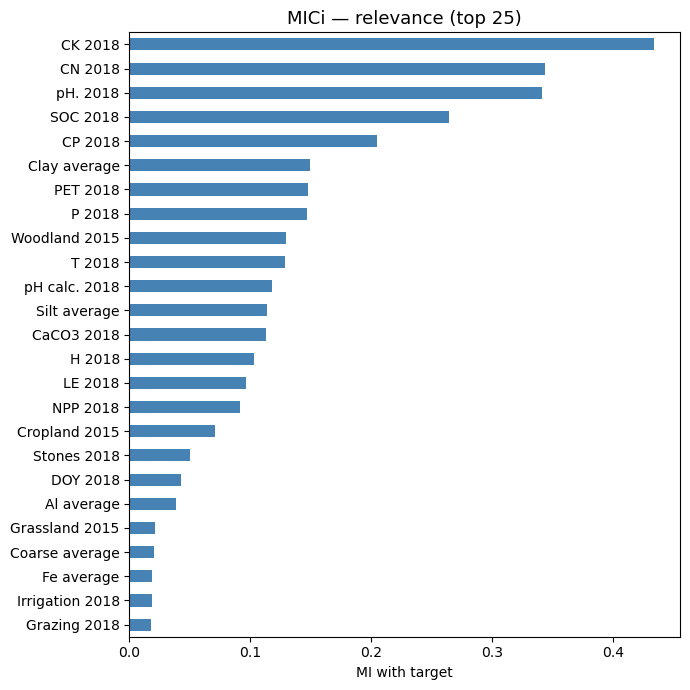

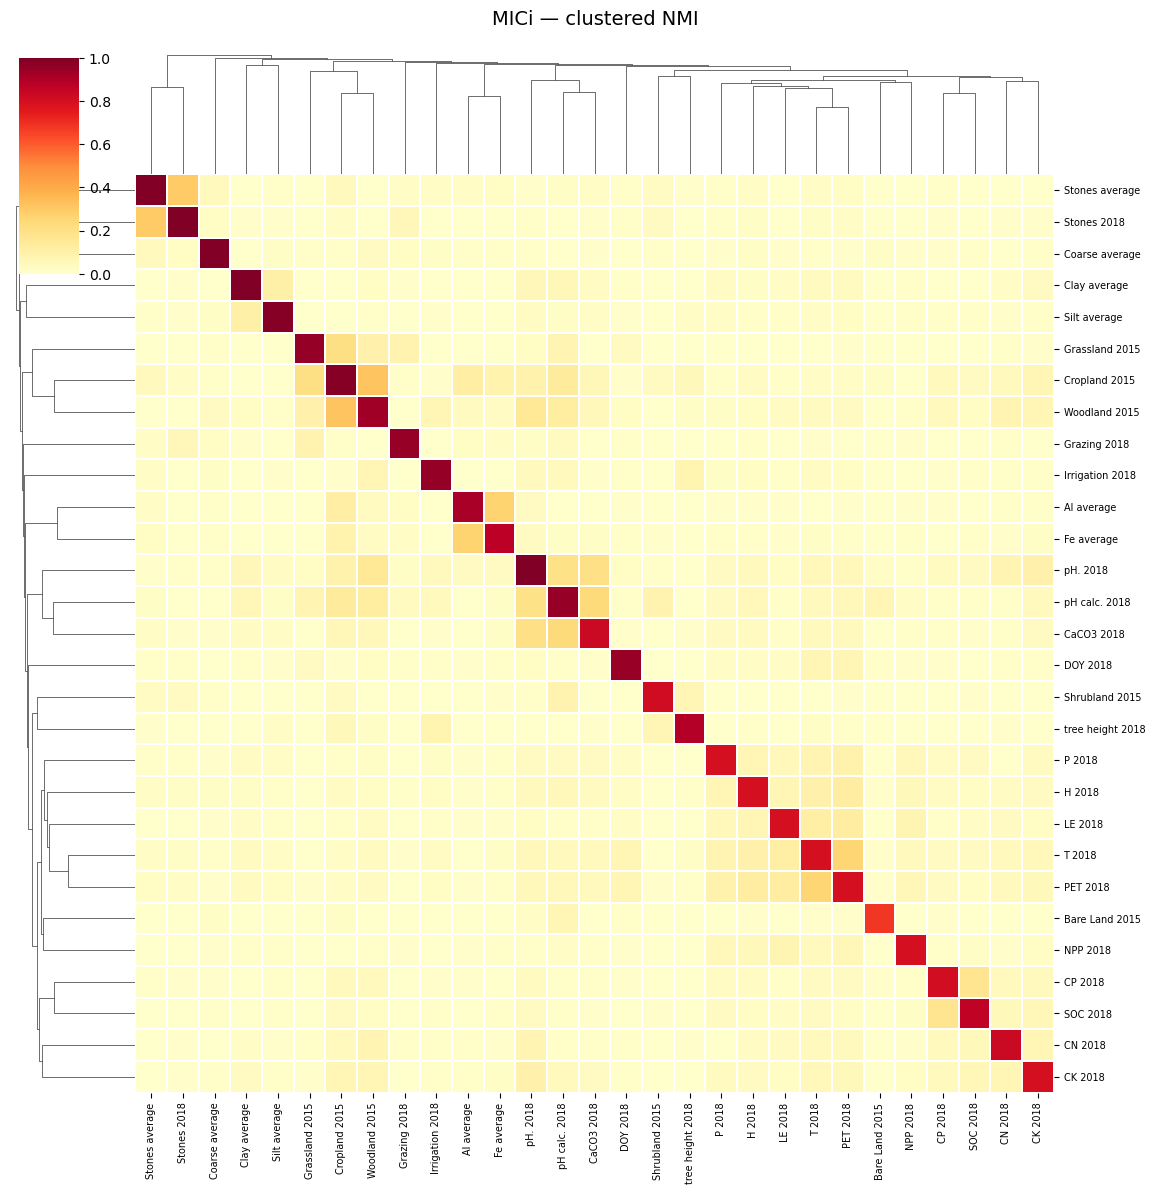


=== MICi: top redundant pairs (NMI >= 0.0) ===


,feature_a,feature_b,NMI,MI_a,MI_b
253,Cropland 2015,Woodland 2015,0.317,0.0711,0.1291
81,Stones average,Stones 2018,0.293,0.0000,0.0501
130,Al average,Fe average,0.267,0.0387,0.0189
371,T 2018,PET 2018,0.261,0.1284,0.1475
194,pH calc. 2018,CaCO3 2018,0.242,0.1177,0.1129
235,Grassland 2015,Cropland 2015,0.208,0.0215,0.0711
214,pH. 2018,CaCO3 2018,0.200,0.3411,0.1129
175,pH calc. 2018,pH. 2018,0.197,0.1177,0.3411
402,CP 2018,SOC 2018,0.176,0.2044,0.2640
199,pH. 2018,Woodland 2015,0.154,0.3411,0.1291


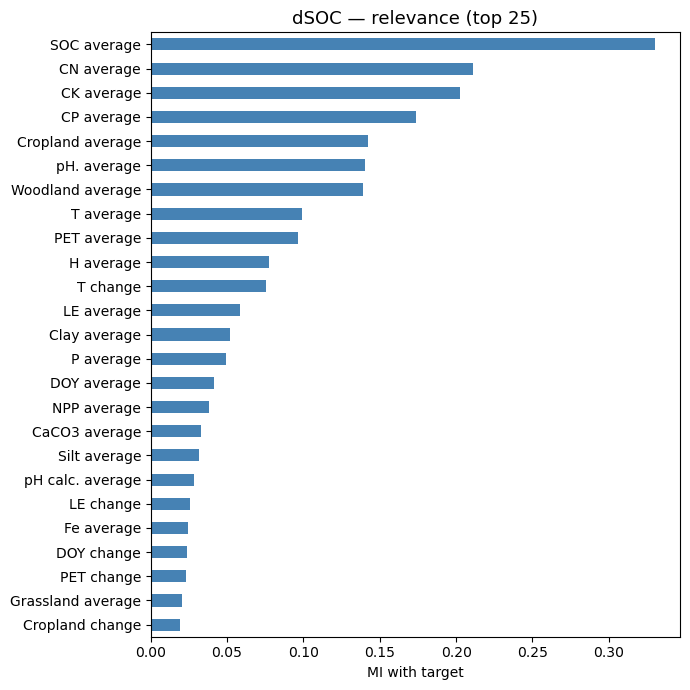

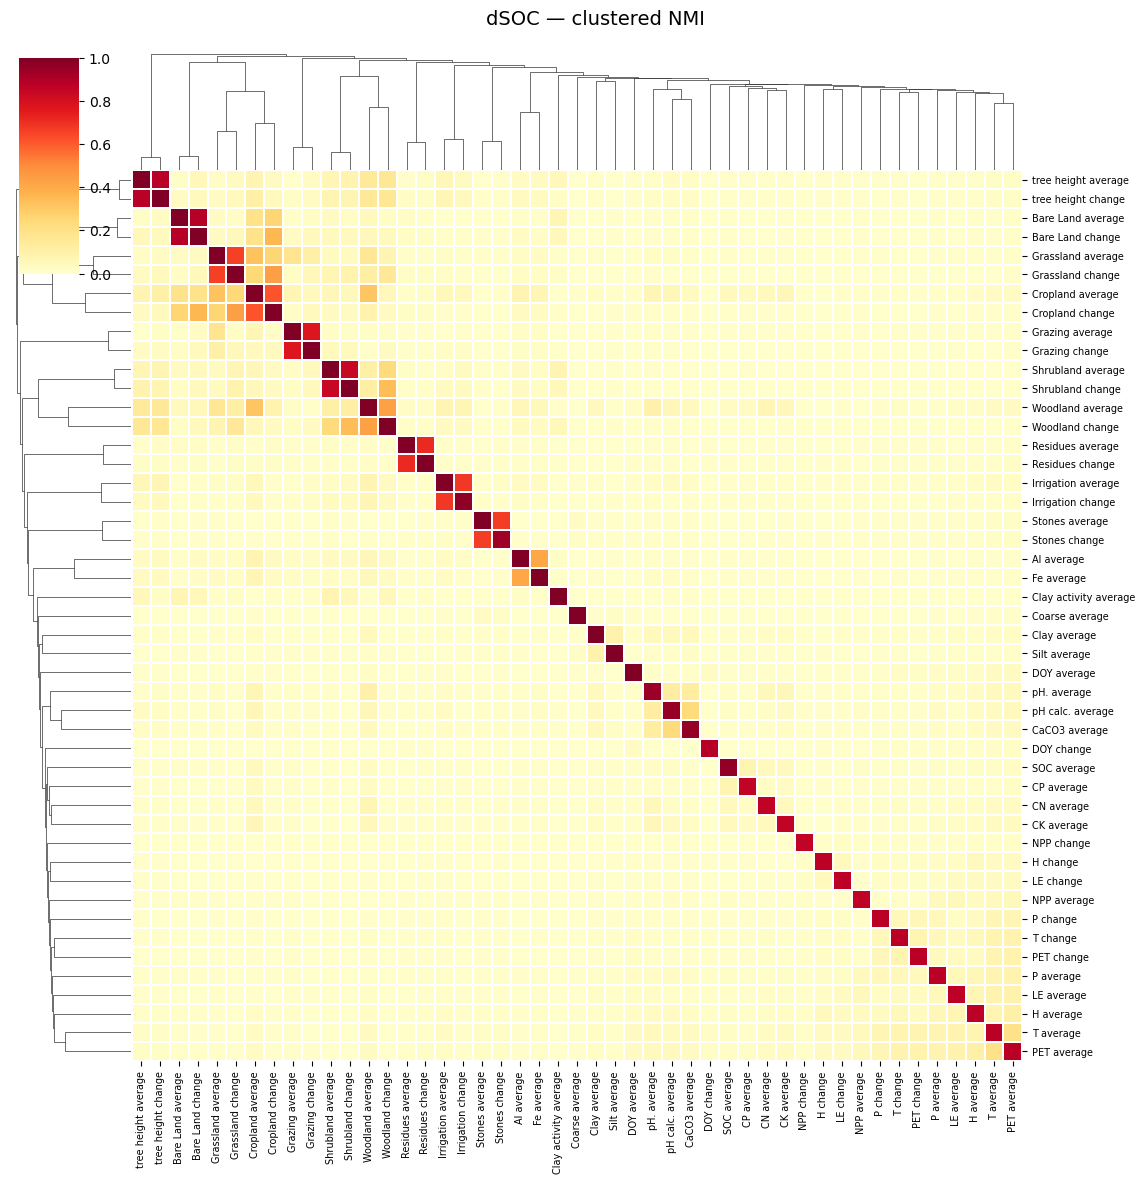


=== dSOC: top redundant pairs (NMI >= 0.0) ===


,feature_a,feature_b,NMI,MI_a,MI_b
624,Bare Land average,Bare Land change,0.887,0.0087,0.0092
738,tree height average,tree height change,0.880,0.0144,0.0069
593,Shrubland average,Shrubland change,0.840,0.0109,0.0063
654,Grazing average,Grazing change,0.772,0.0056,0.0069
711,Residues average,Residues change,0.712,0.0082,0.0155
683,Irrigation average,Irrigation change,0.676,0.0061,0.0080
135,Stones average,Stones change,0.668,0.0035,0.0136
494,Grassland average,Grassland change,0.660,0.0204,0.0000
528,Cropland average,Cropland change,0.614,0.1424,0.0192
756,Grassland change,Cropland change,0.439,0.0000,0.0192


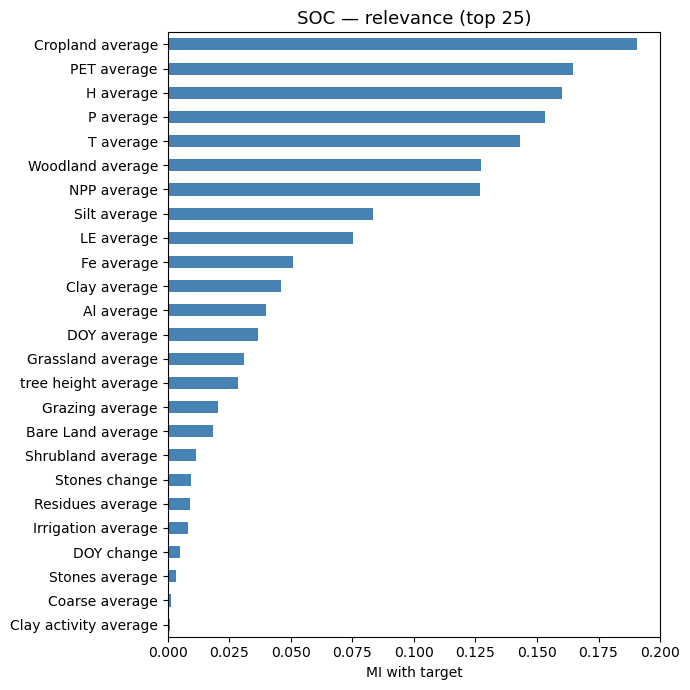

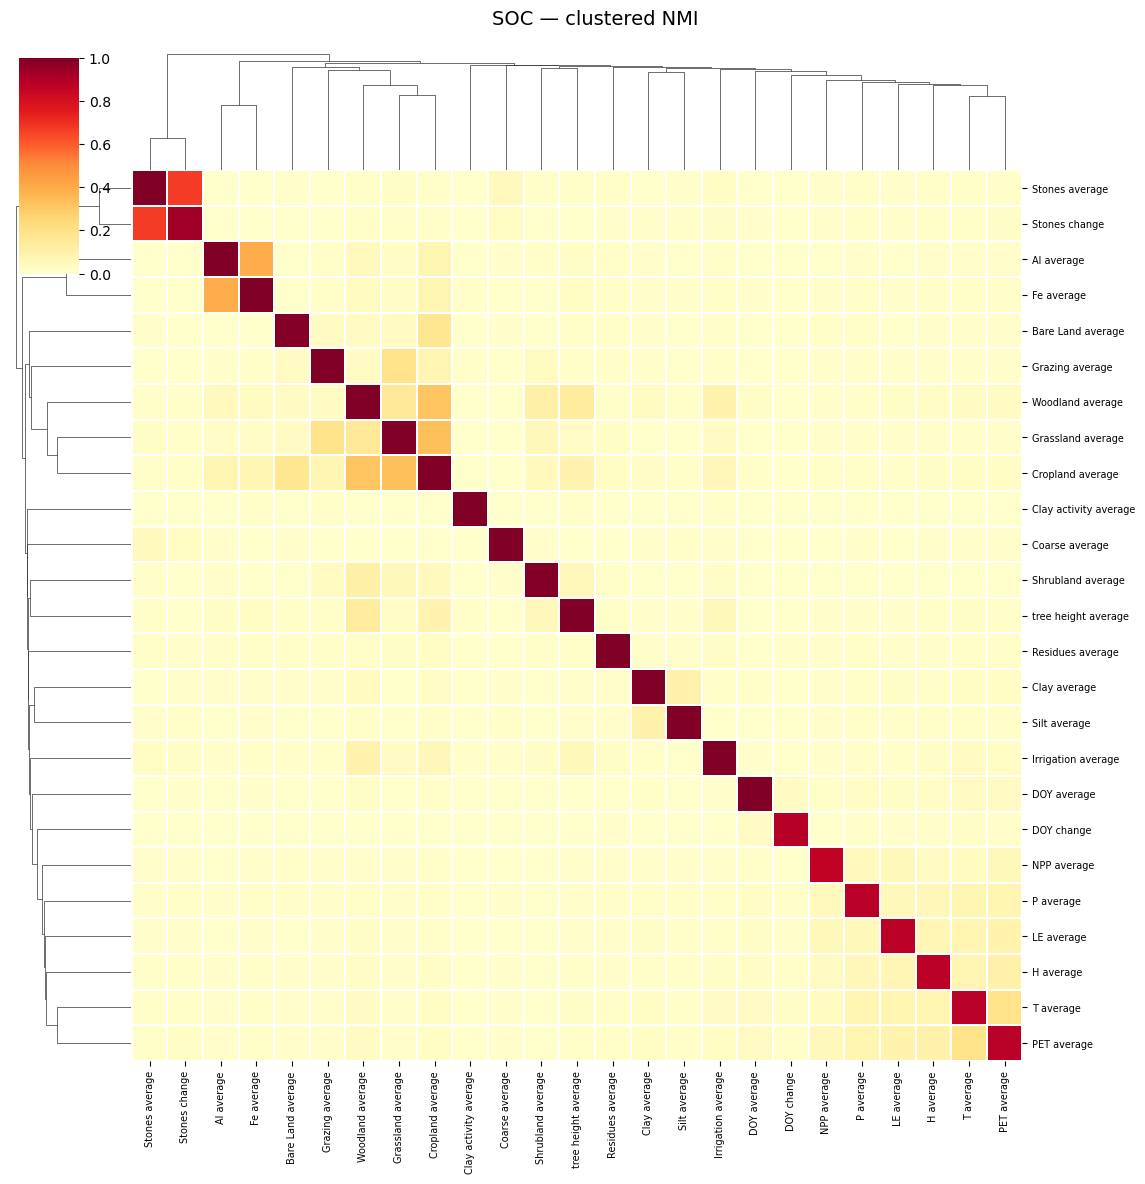


=== SOC: top redundant pairs (NMI >= 0.0) ===


,feature_a,feature_b,NMI,MI_a,MI_b
69,Stones average,Stones change,0.668,0.0034,0.0095
110,Al average,Fe average,0.392,0.0402,0.0510
195,Grassland average,Cropland average,0.332,0.0308,0.1905
209,Cropland average,Woodland average,0.314,0.1905,0.1271
199,Grassland average,Grazing average,0.189,0.0308,0.0203
295,T average,PET average,0.188,0.1432,0.1645
211,Cropland average,Bare Land average,0.170,0.1905,0.0183
196,Grassland average,Woodland average,0.152,0.0308,0.1271
227,Woodland average,tree height average,0.135,0.1271,0.0288
222,Woodland average,Shrubland average,0.103,0.1271,0.0116


In [36]:
%matplotlib inline
# loop over targets
from config import TARGET_CONFIG, to_log
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import pickle
import pandas as pd
with open("1_preprocessed_intermediate.pkl", "rb") as f:
    df = pickle.load(f)


def nmi_pair(x, y, random_state=42):
  x = np.asarray(x).ravel()
  y = np.asarray(y).ravel()
  mi = mutual_info_regression(x.reshape(-1, 1), y, random_state=random_state)[0]
  def entropy(v):
      v = np.asarray(v).ravel()
      _, counts = np.unique(v, return_counts=True)
      p = counts / counts.sum()
      return -(p * np.log(p + 1e-12)).sum()
  hx, hy = entropy(x), entropy(y)
  if hx + hy == 0:
      return 0.0
  return float(np.clip(2 * mi / (hx + hy), 0, 1))

nmi_results = {}
for target in TARGET_CONFIG:
    # get potential predictors
    y = df[TARGET_CONFIG[target]['target_name']]
    y_log = np.log1p(df[TARGET_CONFIG[target]['target_name']])

    predictors = []
    log_predictors = []
    predictor_groups = TARGET_CONFIG[target]['predictor_groups']
    for predictor_group in predictor_groups:
        for pred in pred_groups[predictor_group[0]][predictor_group[1]]:
            if pred in to_log:
                log_predictors.append(pred_groups[predictor_group[0]][predictor_group[1]][pred])
            else:
                predictors.append(pred_groups[predictor_group[0]][predictor_group[1]][pred])
    continuous = df[predictors]
    continuous_log = np.log1p(df[log_predictors])
    X = pd.concat([continuous, continuous_log], axis=1)



    # separate train and test
    train_mask = df['split'] != 'test'
    nan_mask = df[TARGET_CONFIG[target]['target_name']].notna()
    y, y_log, X = y[train_mask & nan_mask], y_log[train_mask & nan_mask], X[train_mask & nan_mask]
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.dropna(axis=1, how='all')
    X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns, index=X.index)
    X = X[X.columns[X.nunique() > 1]] # remove where no info
    X = X[[c for c in X.columns if not (X[c].nunique() == 2 and X[c].mean() < 0.01)]] # remove where no info
    relevance = pd.Series(mutual_info_regression(X, y, random_state=42), index=X.columns).sort_values(ascending=False)
    n = X.shape[1]
    nmi_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            nmi_ij = nmi_pair(X.iloc[:, i].values, X.iloc[:, j].values)
            nmi_matrix[i, j] = nmi_matrix[j, i] = nmi_ij

    nmi_df = pd.DataFrame(nmi_matrix, index=X.columns, columns=X.columns)
    nmi_results[target] = {'relevance': relevance, 'nmi_df': nmi_df, 'n_features': len(X.columns)}



def short_label(final_value, max_len=20):
    for group, group_dict in pred_groups.items():
        for subgroup, members in group_dict.items():
            if isinstance(members, dict):
                for key, val in members.items():
                    if val == final_value:
                        s = f"{key} {subgroup}"
                        return s

def plot_relevance_bar(target, relevance, save=True):
    rel = relevance.copy()
    rel.index = [short_label(c) for c in rel.index]
    ax = rel.head(25).iloc[::-1].plot.barh(color='steelblue', figsize=(7, 7))
    ax.set_xlabel('MI with target')
    ax.set_title(f'{target} — relevance (top 25)', fontsize=13)
    plt.tight_layout()
    if save:
        plt.savefig(f'figures/relevance_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
def plot_nmi_clustermap(target, nmi_df, save=True):
    labels = [short_label(c) for c in nmi_df.columns]
    mat = nmi_df.copy()
    mat.index = labels
    mat.columns = labels

    g = sns.clustermap(
        mat, cmap='YlOrRd', vmin=0,
        figsize=(12, 12), linewidths=0.2,
        xticklabels=True, yticklabels=True,
        dendrogram_ratio=0.12,
    )
    g.ax_heatmap.tick_params(axis='x', labelsize=7, rotation=90)
    g.ax_heatmap.tick_params(axis='y', labelsize=7)
    g.fig.suptitle(f'{target} — clustered NMI', y=1.02, fontsize=14)

    if save:
        g.savefig(f'figures/nmi_cluster_{target}.png', dpi=150, bbox_inches='tight')
    plt.show()
def top_redundant_pairs(target, relevance, nmi_df, nmi_threshold=0.3, top_k=20):
    rows = []
    cols = nmi_df.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            v = nmi_df.iloc[i, j]
            if v >= nmi_threshold:
                rows.append({
                    'feature_a': short_label(cols[i]),
                    'feature_b': short_label(cols[j]),
                    'NMI': round(v, 3),
                    'MI_a': round(relevance[cols[i]], 4),
                    'MI_b': round(relevance[cols[j]], 4),
                })
    out = pd.DataFrame(rows).sort_values('NMI', ascending=False).head(top_k)
    print(f'\n=== {target}: top redundant pairs (NMI >= {nmi_threshold}) ===')
    display(out)
    return out
for target, res in nmi_results.items():
    plot_relevance_bar(target, res['relevance'])
    plot_nmi_clustermap(target, res['nmi_df'])
    top_redundant_pairs(target, res['relevance'], res['nmi_df'], nmi_threshold=0.0)

# Machine Learning

Total time: 3.05 min


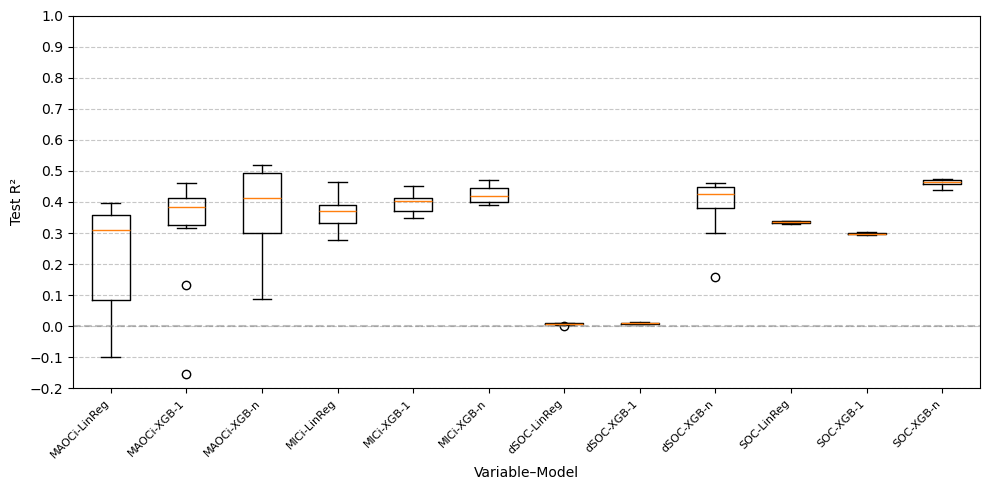

In [1]:
# function definitions
import time
t0 = time.perf_counter()
import numpy as np
import pickle
import pandas as pd
from joblib import Parallel, delayed
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

######################################## load ########################################
from config import TARGET_CONFIG, TRAIN_DEFAULTS, pred_groups, to_log
from models import get_models
models = get_models()

# Load the saved preprocessed dataframe from pickle, and save to a "wide" CSV for easy summary/stats.
import pickle
with open("1_preprocessed_intermediate.pkl", "rb") as f:
    df = pickle.load(f)

######################################## define ########################################
def process_one_fold(var, fold, df, TARGET_CONFIG):
    ### load info
    config = TARGET_CONFIG[var] # info (targets, predictors, inference, log...)
    target_name = config["target_name"] # target name
    ### prepare data
    predictors = []
    log_predictors = []
    predictor_groups = TARGET_CONFIG[var]['predictor_groups']
    for predictor_group in predictor_groups:
        for pred in pred_groups[predictor_group[0]][predictor_group[1]]:
            if pred in to_log:
                log_predictors.append(pred_groups[predictor_group[0]][predictor_group[1]][pred])
            else:
                predictors.append(pred_groups[predictor_group[0]][predictor_group[1]][pred])

    pred_cols = list(predictors) + list(log_predictors) # all potential predictors together (1-hot might get selected individually)
    n_normal = len(predictors) # number of normal distributed predictors
    n_log = len(log_predictors) # numer of log normal distributed predictors

    
    
    test_data = df[(df['split'] == 'test') & (df[target_name].notna())] # valid test rows
    X_test, y_test  = test_data[pred_cols].to_numpy(dtype=float), test_data[target_name].to_numpy(dtype=float) # get test X and y as array
    X_test[:, n_normal:n_normal + n_log] = np.log1p(X_test[:, n_normal:n_normal + n_log]) # log respective predictors (looks correct) 
    train_fit = df[(df['split'] != 'test') & (df['split'] != fold) & (df[target_name].notna())] # valid train samples       (not in test of validation)
    val_fit = df[(df['split'] != 'test') & (df['split'] == fold) & (df[target_name].notna())]   # valid validation samples  (not in test but in validation)
    train_all = df[(df['split'] != 'test') & (df['split'] != fold)]
    val_all = df[(df['split'] != 'test') & (df['split'] == fold)]
    test_all = df[(df['split'] == 'test')]
    train_idx = train_all.index.to_numpy()
    val_idx = val_all.index.to_numpy()
    test_idx = test_all.index.to_numpy()
    X_train = train_fit[pred_cols].to_numpy(dtype=float)
    y_train = train_fit[target_name].to_numpy(dtype=float)
    X_val = val_fit[pred_cols].to_numpy(dtype=float)
    y_val = val_fit[target_name].to_numpy(dtype=float)
    X_train_all = train_all[pred_cols].to_numpy(dtype=float)
    X_val_all = val_all[pred_cols].to_numpy(dtype=float)
    X_test_all = test_all[pred_cols].to_numpy(dtype=float)
    y_train_all = train_all[target_name].to_numpy(dtype=float)
    X_train = np.asarray(X_train, dtype=float, order='C').copy() # order='C' -> row major
    X_val = np.asarray(X_val, dtype=float, order='C').copy() # rearrange array
    X_train[:, n_normal:n_normal + n_log] = np.log1p(X_train[:, n_normal:n_normal + n_log]) # log respective predictors
    X_val[:, n_normal:n_normal + n_log] = np.log1p(X_val[:, n_normal:n_normal + n_log]) # log respective predictors
    preprocessor = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]) # implace empty predictors with median & z-score
    X_train_p = preprocessor.fit_transform(X_train) # get median (for imputation), mean and var (for z-score) on train
    X_val_p = preprocessor.transform(X_val) # apply with train stats on val predictors
    X_test_p = preprocessor.transform(X_test) # apply with train stats on test predictors
    def to_signed_log(y): # log the abs value and give it sign: log of negative (changes) makes problems otherwise
        return np.sign(y) * np.log1p(np.abs(y))
    def from_signed_log(y_log): # function to revert (when prediction)
        y_log = np.clip(y_log, -np.log(np.finfo(np.float64).max), np.log(np.finfo(np.float64).max))
        return np.sign(y_log) * np.expm1(np.abs(y_log))
    y_train_log = to_signed_log(y_train) # log train target (if negative special: vide function)
    y_val_log = to_signed_log(y_val) # log val target (if negative special: vide function)
    ### prepare predictions
    inference_bundles = []
    for raw_inf in config.get('inference') or []:
        inf = { "target_name": raw_inf["target_name"], "predictors": tuple(raw_inf.get("predictors", config["predictors"])), "log_predictors": tuple(raw_inf.get("log_predictors", config["log_predictors"])), "categoricals": list(raw_inf.get("categoricals", config.get("categoricals", []))) }
        oh_i, _ = get_onehot_cols_for_config(df, inf)
        pc_i = list(inf['predictors']) + list(inf['log_predictors']) + oh_i
        nn_i = len(inf['predictors'])
        nl_i = len(inf['log_predictors'])
        tn_i = inf['target_name']
        inference_bundles.append({'target_name': tn_i, 'X_train': train_all[pc_i].to_numpy(dtype=float), 'X_val': val_all[pc_i].to_numpy(dtype=float), 'X_test': test_all[pc_i].to_numpy(dtype=float), 'y_train': _y_column_if_present(train_all, tn_i), 'y_val': _y_column_if_present(val_all, tn_i), 'y_test': _y_column_if_present(test_all, tn_i), 'n_normal': nn_i, 'n_log': nl_i})
    ### train
    fold_results = []
    for model_name in TRAIN_DEFAULTS['models']: # loop over methods (LR, PLR, XGB...)
        model_config = models[model_name] # get info on model
        param_grid = model_config.get('params', {}) or {} # create latin hypercube of hyperparameter combinations (if HP opt...)
        best_val_r2 = -np.inf # init best metric (worst R2 in -inf)
        best_result = None
        for params_combo in ParameterGrid(param_grid) if param_grid else [{}]: # loop over hyperparameter combos
            ### select features and predict (original and log-transformed target)
            train_r2_raw, val_r2_raw, test_r2_raw, selected_raw = select_features_and_predict(X_train_p, X_val_p, X_test_p, y_train, y_val, y_test, y_train, y_val, model_config, params_combo, TRAIN_DEFAULTS['max_features'])
            train_r2_log, val_r2_log, test_r2_log, selected_log = select_features_and_predict(X_train_p, X_val_p, X_test_p, y_train, y_val, y_test, y_train_log, y_val_log, model_config, params_combo, TRAIN_DEFAULTS['max_features'], inverse_pred=from_signed_log)
            ### pick if best combo
            if val_r2_log > best_val_r2:
                best_val_r2 = val_r2_log
                best_result = {'train r2': train_r2_log, 'val r2': val_r2_log, 'test r2': test_r2_log, 'params': params_combo, 'selected': selected_log, 'target_logged': True}
            elif val_r2_raw > best_val_r2:
                best_val_r2 = val_r2_raw
                best_result = {'train r2': train_r2_raw, 'val r2': val_r2_raw, 'test r2': test_r2_raw, 'params': params_combo, 'selected': selected_raw, 'target_logged': False}
        ### retrain best model
        if best_result is not None: # if any haperparameter combo worked:
            sel = best_result['selected'] # selected features
            m_final = _make_model(model_config, best_result['params'], n_features=len(sel)) # initialize model
            yt = to_signed_log(y_train) if best_result['target_logged'] else y_train # target log-transformed?          
            m_final.fit(X_train_p[:, sel], yt) # retrain
            ### predict
            def _predict_from_Xp(Xp):
                raw = m_final.predict(Xp[:, sel])
                return from_signed_log(raw) if best_result['target_logged'] else raw
            inference_metrics = []
            inference_preds = []
            for ib in inference_bundles:
                rec = dict(inference_target=ib['target_name'], train_r2=np.nan, val_r2=np.nan, test_r2=np.nan, frozen_main_model=False)
                pred_pack = dict(inference_target=ib['target_name'], pred_train=None, pred_val=None, pred_test=None)
                try:
                    Xtr = np.asarray(ib['X_train'], dtype=float, order='C').copy()
                    Xva = np.asarray(ib['X_val'], dtype=float, order='C').copy()
                    Xte = np.asarray(ib['X_test'], dtype=float, order='C').copy()
                    nn, nl = ib['n_normal'], ib['n_log']
                    Xtr[:, nn:nn + nl] = np.log1p(Xtr[:, nn:nn + nl])
                    Xva[:, nn:nn + nl] = np.log1p(Xva[:, nn:nn + nl])
                    Xte[:, nn:nn + nl] = np.log1p(Xte[:, nn:nn + nl])
                    ytr_i, yva_i, yte_i = ib['y_train'], ib['y_val'], ib['y_test']
                    if Xtr.shape[1] == X_train.shape[1]:
                        Xtr_p = preprocessor.transform(Xtr)
                        Xva_p = preprocessor.transform(Xva)
                        Xte_p = preprocessor.transform(Xte)
                        rec['frozen_main_model'] = True
                        ptr = _predict_from_Xp(Xtr_p)
                        pva = _predict_from_Xp(Xva_p)
                        pte = _predict_from_Xp(Xte_p)
                    else:
                        prep_i = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
                        Xtr_p = prep_i.fit_transform(Xtr)
                        Xva_p = prep_i.transform(Xva)
                        Xte_p = prep_i.transform(Xte)
                        m_i = _make_model(model_config, best_result['params'], n_features=len(sel))
                        # Refit on inference-year X; use inference y only if present (≥2 finite), else main y_train
                        use_inf_y = ytr_i is not None and np.isfinite(ytr_i).sum() >= 2
                        y_fit_source = ytr_i if use_inf_y else y_train_all
                        y_fit = to_signed_log(y_fit_source) if tl else y_fit_source
                        fit_m = np.isfinite(y_fit) & np.all(np.isfinite(Xtr_p[:, sel]), axis=1)
                        if fit_m.sum() < 2:
                            inference_metrics.append(rec)
                            inference_preds.append(pred_pack)
                            continue
                        m_i.fit(Xtr_p[fit_m][:, sel], y_fit[fit_m])
                        def _pred_i(Xp):
                            r = m_i.predict(Xp[:, sel])
                            return from_signed_log(r) if tl else r
                        ptr, pva, pte = _pred_i(Xtr_p), _pred_i(Xva_p), _pred_i(Xte_p)
                    rec['train r2'] = _r2_masked(ytr_i, ptr)
                    rec['val r2'] = _r2_masked(yva_i, pva)
                    rec['test r2'] = _r2_masked(yte_i, pte)
                    pred_pack['pred_train'] = ptr
                    pred_pack['pred_val'] = pva
                    pred_pack['pred_test'] = pte
                except (ValueError, np.linalg.LinAlgError, RuntimeError):
                    pass
                inference_metrics.append(rec)
                inference_preds.append(pred_pack)
            def _prep_full_X(X_raw):
                X = np.asarray(X_raw, dtype=float, order='C').copy()
                X[:, n_normal:n_normal + n_log] = np.log1p(X[:, n_normal:n_normal + n_log])
                return preprocessor.transform(X)
            pred_train = _predict_from_Xp(_prep_full_X(X_train_all))
            pred_val = _predict_from_Xp(_prep_full_X(X_val_all))
            pred_test = _predict_from_Xp(_prep_full_X(X_test_all))
            ### output
            fold_results.append({'var': var, 'fold': fold, 'model': model_name, 
                        'train r2': best_result['train r2'], 'val r2': best_result['val r2'], 'test r2': best_result['test r2'], 
                        'params': best_result['params'], 'target_logged': best_result['target_logged'], 'selected_predictors': [pred_cols[i] for i in sel], 
                        'pred_train': pred_train, 'pred_val': pred_val, 'pred_test': pred_test, 
                        'train_idx': train_idx, 'val_idx': val_idx, 'test_idx': test_idx, 
                        'selected': sel, 'inference_metrics': inference_metrics, 'inference_preds': inference_preds})
    return fold_results

def select_features_and_predict(X_train_p, X_val_p, X_test_p, y_train, y_val, y_test, y_train_fit, y_val_fit, model_config, params_combo, max_features, inverse_pred=None):
    ### select features 
    selected = forward_select(X_train_p, X_val_p, y_train_fit, y_val_fit, model_config, params_combo, max_features)
    ### retrain with optimal n_features
    m = _make_model(model_config, params_combo, n_features=len(selected))
    m.fit(X_train_p[:, selected], y_train_fit)
    ### predict
    def _predict(Xp):
        pred = m.predict(Xp[:, selected])
        return inverse_pred(pred) if inverse_pred else pred
    pred_train = _predict(X_train_p)
    pred_val = _predict(X_val_p)
    pred_test = _predict(X_test_p)
    return r2_score(y_train, pred_train), r2_score(y_val, pred_val), r2_score(y_test, pred_test), selected

def get_onehot_cols_for_config(df, config):
    """Resolve categorical columns from df. config uses 'categoricals' or 'onehot_prefixes'."""
    prefixes = config.get('categoricals', config.get('onehot_prefixes', [])) # list with prefixes of all desired 1-hot columns
    cols = []
    specs = {}
    for p in prefixes: # loop over prefixes/categoricals
        group_cols = [c for c in df.columns if c.startswith(f'{p}_')] # get the columns which have respective prefix
        if group_cols: # if any found
            cols.extend(group_cols) # add columns (data)
            specs[p] = group_cols # add column names
    return cols, specs # return data and column names

def _make_model(model_config, params_combo, n_features=None):
    """Create model with params. If n_features given, cap n_components for PLSR/PCA-like estimators."""
    m = clone(model_config['model']) # clone the model with hyperparameters, so standard remains untouched (not fitted to anything)
    params = dict(params_combo) if params_combo else {} # use hyperparameter combination if given... else use standard hyperparameters
    if n_features is not None and 'n_components' in params: # if n_components is a hyperparameter -> only relevant for PLSR
        params['n_components'] = min(params['n_components'], n_features) # use the ones specified, or if less predictors then n of predictors
    if params: # if hyperparameters to specify 
        m.set_params(**params) # specify
    return m # return model

def forward_select(X_train_p, X_val_p, y_train, y_val, model_config, params_combo, max_features):
    """Additive forward feature selection: iteratively add feature that improves val R² most."""
    n_features = X_train_p.shape[1] # number of possible features
    selected_idx = [] # to store the indices of selected predictors
    remaining = list(range(n_features)) # indices of remaining predictors which could later be selected
    best_val_r2 = -np.inf # start at worst possible R2
    for _ in range(min(max_features, n_features)): # loop over max features (except there are less than defined max)
        best_c, best_score = None, -np.inf # initialize best predictor and corresponding R2
        for c in remaining: # loop over (remaining) possible predictors
            idxs = selected_idx + [c] # formerly selected + possible new predictor
            n_cols = len(idxs) # number of predictors
            try:
                m = _make_model(model_config, params_combo, n_features=n_cols) # create model with respective hyperparameters
                m.fit(X_train_p[:, idxs], y_train) # fit model on train of the predictors (formerly selected + possible new predictor)
                pred = m.predict(X_val_p[:, idxs]) # predict for val
                if not np.all(np.isfinite(pred)): # if any predicted value is corrupt 
                    score = -np.inf # -> worst
                else: # if val prediction worked
                    score = r2_score(y_val, pred) # calculate r2 (with sk_learn)
            except (ValueError, np.linalg.LinAlgError, RuntimeError): # if even fitting didn't work
                score = -np.inf # -> worst
            if score > best_score: # if val R2 better than any before
                best_score, best_c = score, c # select/overwrite
        if best_c is None or best_score <= best_val_r2: # if no possible additional predictor makes predictions better:
            break # don't select further predictor: less predictors than max
        best_val_r2 = best_score # but if additional predictor helped: new best score
        selected_idx.append(best_c) # but if additional predictor helped: add best new predictor to selection
        remaining.remove(best_c) # remove the selected from the ones to test in next round
    return selected_idx # return indices of selected predictors

def _r2_masked(y, pred):
    if y is None:
        return np.nan
    m = np.isfinite(np.asarray(y)) & np.isfinite(np.asarray(pred))
    if m.sum() < 2:
        return np.nan
    return r2_score(np.asarray(y)[m], np.asarray(pred)[m])

def _y_column_if_present(frame, col_name):
    """Return float numpy y for rows in frame, or None if column missing (no ground truth for that target)."""
    if col_name not in frame.columns:
        return None
    return frame[col_name].to_numpy(dtype=float)




# compute 
# define individual tasks to parallelize
tasks = []
for var in TARGET_CONFIG.keys():
    for fold in range(10):
        tasks.append((var, fold, df, TARGET_CONFIG))
# Parallel:    runs individual processes (own memory) not threads (shared memory) -> one per target and fold
# delayed:      creates argument combos for the function which is processed per task: process_one_fold
results = Parallel(n_jobs=TRAIN_DEFAULTS['N_JOBS'], backend='loky')(delayed(process_one_fold)(*task) for task in tasks)

######################################## post processing ########################################
# Each fold returns a list of dicts (one per model); flatten
results_flat = [row for fold_results in results for row in fold_results]

# One row per (var, fold, model): hyperparameters dict, log-target flag, ordered selected predictor names
selection_meta_df = pd.DataFrame([
    {
        'var': r['var'],
        'fold': r['fold'],
        'model': r['model'],
        'params': r['params'],
        'target_logged': r['target_logged'],
        'selected_predictors': r['selected_predictors'],
        'inference_metrics': r.get('inference_metrics', []),
        'train r2': r['train r2'], 
        'val r2': r['val r2'],
        'test r2': r['test r2']
    }
    for r in results_flat])

_results_exclude = ('pred_train', 'pred_val', 'pred_test', 'train_idx', 'val_idx', 'test_idx', 'inference_preds',)
results_df = pd.DataFrame([
    {**{k: v for k, v in r.items() if k not in _results_exclude},
     'params': str(r['params'])}
    for r in results_flat])
# Long-form inference rows (one row per var/fold/model/inference_target) for filtering and tables
inf_rows = []
for r in results_flat:
    for im in r.get('inference_metrics') or []:
        inf_rows.append({
            'var': r['var'],
            'fold': r['fold'],
            'model': r['model'],
            'inference_target': im['inference_target'],
            'inference_train_r2': im['train r2'],
            'inference_val_r2': im['val r2'],
            'inference_test_r2': im['test r2'],
            'inference_frozen_main_model': im.get('frozen_main_model', False),
        })
inference_results_df = pd.DataFrame(inf_rows)

# Build output df: original df + one column per (var, fold, model) with train/val/test predictions
# on every row in each split (not only rows with observed target). Inference preds use the same splits.
out_df = df.copy()
pred_cols = []
for r in results_flat:
    pred_cols.append(f"pred_{r['var']}_fold{r['fold']}_{r['model']}")
    pred_cols.extend(
        f"pred_{r['var']}_fold{r['fold']}_{r['model']}_inf_{str(ip['inference_target']).replace(' ', '_').replace('/', '_')}"
        for ip in (r.get('inference_preds') or [])
        if ip.get('pred_train') is not None
    )
out_df = pd.concat([out_df, pd.DataFrame(np.nan, index=out_df.index, columns=pred_cols)], axis=1)
for r in results_flat:
    col = f"pred_{r['var']}_fold{r['fold']}_{r['model']}"
    out_df.loc[r['train_idx'], col] = r['pred_train']
    out_df.loc[r['val_idx'], col] = r['pred_val']
    out_df.loc[r['test_idx'], col] = r['pred_test']
    for ip in r.get('inference_preds') or []:
        if ip.get('pred_train') is None:
            continue
        suf = str(ip['inference_target']).replace(' ', '_').replace('/', '_')
        icol = f"pred_{r['var']}_fold{r['fold']}_{r['model']}_inf_{suf}"
        out_df.loc[r['train_idx'], icol] = ip['pred_train']
        out_df.loc[r['val_idx'], icol] = ip['pred_val']
        out_df.loc[r['test_idx'], icol] = ip['pred_test']
_pred_cols = [c for c in out_df.columns if c.startswith('pred_')]
_n_inf = sum(1 for c in _pred_cols if '_inf_' in c)

import matplotlib.pyplot as plt
model_order = [m for m in TRAIN_DEFAULTS['models'] if m in results_df['model'].values]
combo_order = [f"{v}-{m}" for v in TARGET_CONFIG.keys() for m in model_order]
data = [results_df[(results_df['var'] == v) & (results_df['model'] == m)]['test r2'].values
    for v in TARGET_CONFIG.keys() for m in model_order]
plt.figure(figsize=(max(10, len(combo_order) * 0.5), 5))
plt.boxplot(data, tick_labels=combo_order)
plt.ylabel('Test R²')
plt.xlabel('Variable–Model')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylim(-0.2, 1.0)
plt.yticks(np.arange(-0.2, 1.05, 0.1))
plt.grid(axis='y', which='both', linestyle='--', alpha=0.7)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figures/predict.png', dpi=150, bbox_inches='tight')
print(f"Total time: {(time.perf_counter() - t0) / 60:.2f} min")

# calculate medians of th 10 predictions
from config import TARGET_CONFIG, use_model
df = out_df
for var in use_model:
    columns = [f"pred_{var}_fold{f}_{use_model[var]}" for f in range(10)]
    all_folds = df[columns]
    df[f"pred_{var}_median_{use_model[var]}"] = all_folds.median(axis=1)

# Save

In [2]:
with open("1_preprocessed.pkl", "wb") as f:
    pickle.dump(df, f)
with open("selection_meta_df.pkl", "wb") as f:
    pickle.dump(selection_meta_df, f)

# Predictor-Group-Colorcoded selected predictors

In [3]:
import pickle
import pandas as pd
from config import use_model, TARGET_CONFIG, TRAIN_DEFAULTS

with open("1_preprocessed.pkl", "rb") as f:
    df = pickle.load(f)
with open("selection_meta_df.pkl", "rb") as f:
    selection_meta_df = pickle.load(f)

# Build a DataFrame of just rows where the `model` column matches the desired model for the corresponding variable (`var`)
plot_mask = []
for _, row in selection_meta_df.iterrows():
    var = row['var']
    model = row['model']
    # Only keep rows where the model matches the one used for this variable
    if var in use_model and use_model[var] == model:
        plot_mask.append(True)
    else:
        plot_mask.append(False)
plot_df = selection_meta_df.loc[plot_mask, ['var', 'model', 'fold', 'train r2', 'val r2', 'test r2', 'selected_predictors']]

# Compute sample counts for each split: train, val, test
def count_samples(row, split, fold):
    if split == 'test':
        mask = (
            (df['split'] == 'test') &
            (~df[TARGET_CONFIG[row['var']]['target_name']].isna())
        )
    elif split == 'val':
        mask = (
            (df['split'] == fold) &
            (~df[TARGET_CONFIG[row['var']]['target_name']].isna())
        )
    elif split == 'train':
        mask = (
            (df['split'] != row['fold']) &
            (df['split'] != 'test') &
            (~df[TARGET_CONFIG[row['var']]['target_name']].isna())
        )
    return df.loc[mask, :].shape[0]

plot_df['train_samples'] = [
    count_samples(row, 'train', row['fold'])
    for _, row in plot_df.iterrows()
]
plot_df['val_samples'] = [
    count_samples(row, 'val', row['fold'])
    for _, row in plot_df.iterrows()
]
plot_df['test_samples'] = [
    count_samples(row, 'test', row['fold'])
    for _, row in plot_df.iterrows()
]

# Create new columns 'Feature 1' ... up to max_features
max_features = TRAIN_DEFAULTS['max_features']
feature_cols = [f'Feat. {i+1}' for i in range(max_features)]
def unpack_predictors(row):
    preds = row['selected_predictors']
    # Fill up to max_features with '' if not enough predictors
    filled = list(preds) + [''] * (max_features - len(preds))
    return pd.Series(filled[:max_features], index=feature_cols)
plot_df[feature_cols] = plot_df.apply(unpack_predictors, axis=1)
plot_df = plot_df.drop(columns=['selected_predictors'])

# rename
def short_label(final_value, max_len=20):
    for group, group_dict in pred_groups.items():
        for subgroup, members in group_dict.items():
            if isinstance(members, dict):
                for key, val in members.items():
                    if val == final_value:
                        s = f"{key} {subgroup}"
                        return s
                        
def standardize_feature_names(df, feature_cols):
    new_df = df.copy()
    for col in feature_cols:
        new_df[col] = new_df[col].map(lambda v: short_label(v) if isinstance(v, str) else v)
    return new_df
plot_df = standardize_feature_names(plot_df, feature_cols)



# Save the current plot_df (before styling) for later use as df
plot_df_copy = plot_df.copy()

# Color code based on pred_groups
def color_by_pred_groups(val):
    if not isinstance(val, str) or not val.strip():
        return ''
    # Use short_label logic to match keys (from above)
    for group, group_dict in pred_groups.items():
        color = group_dict.get('color', None)
        found = False
        # Check each subgroup for a match to val (by key or by value)
        for subgroup, members in group_dict.items():
            if subgroup == 'color':
                continue
            if isinstance(members, dict):
                for key, v in members.items():
                    label = f"{key} {subgroup}"
                    if label == val:
                        found = True
                        break
            # optional: could match direct keys here (not just label logic)
        if found and color:
            return f'background-color: {color}'
    return ''

plot_df = plot_df.style.map(color_by_pred_groups, subset=[f'Feat. {i}' for i in range(1, 21)])

# save and show
plot_df = plot_df.hide(axis="index")
styles = [dict(selector="th, td", props=[("min-width", "75px"), ("max-width", "75px"), ("width", "75px")])]
plot_df.set_table_styles(styles, overwrite=False).to_html('figures/LC_styled_df.html')

from IPython.display import display, HTML
with pd.option_context('display.max_columns', None):
    display(HTML(plot_df.set_table_styles(styles, overwrite=False).to_html()))

var,model,fold,train r2,val r2,test r2,train_samples,val_samples,test_samples,Feat. 1,Feat. 2,Feat. 3,Feat. 4,Feat. 5,Feat. 6,Feat. 7,Feat. 8,Feat. 9,Feat. 10,Feat. 11,Feat. 12,Feat. 13,Feat. 14,Feat. 15,Feat. 16,Feat. 17,Feat. 18,Feat. 19,Feat. 20
MAOCi,XGB-n,0,0.544654,0.688429,0.517917,255,24,32,CN 2009,Cropland 2009,tree height 2009,Clay average,Stones average,Irrigation 2009,Grassland 2009,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,1,0.729905,0.622889,0.509498,250,29,32,CN 2009,PET 2009,CaCO3 2009,SOC 2009,Clay average,Al average,P 2009,Cropland 2009,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,2,0.659900,0.726408,0.428718,242,37,32,CK 2009,CN 2009,H 2009,SOC 2009,Silt average,pH calc. 2009,pH. 2009,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,3,0.629327,0.602943,0.396919,248,31,32,CK 2009,PET 2009,Stones average,Cropland 2009,Clay average,Al average,Clay activity average,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,4,0.601532,0.633015,0.505026,246,33,32,pH. 2009,CN 2009,DOY 2009,Stones 2009,P 2009,Woodland 2009,Cropland 2009,Grazing 2009,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,5,0.570234,0.721325,0.271571,251,28,32,SOC 2009,Cropland 2009,NPP 2009,Al average,Irrigation 2009,Shrubland 2009,Stones 2009,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,6,0.530235,0.438006,-0.299899,251,28,32,NPP 2009,P 2009,Clay average,Irrigation 2009,Grazing 2009,Shrubland 2009,Al average,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,7,0.620170,0.551965,0.087741,261,18,32,Stones average,CK 2009,Silt average,H 2009,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,8,0.624121,0.511278,0.384687,255,24,32,pH. 2009,PET 2009,SOC 2009,Stones 2009,Coarse average,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None
MAOCi,XGB-n,9,0.506909,0.683355,0.453443,252,27,32,SOC 2009,tree height 2009,Al average,Cropland 2009,CaCO3 2009,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None


Retrain

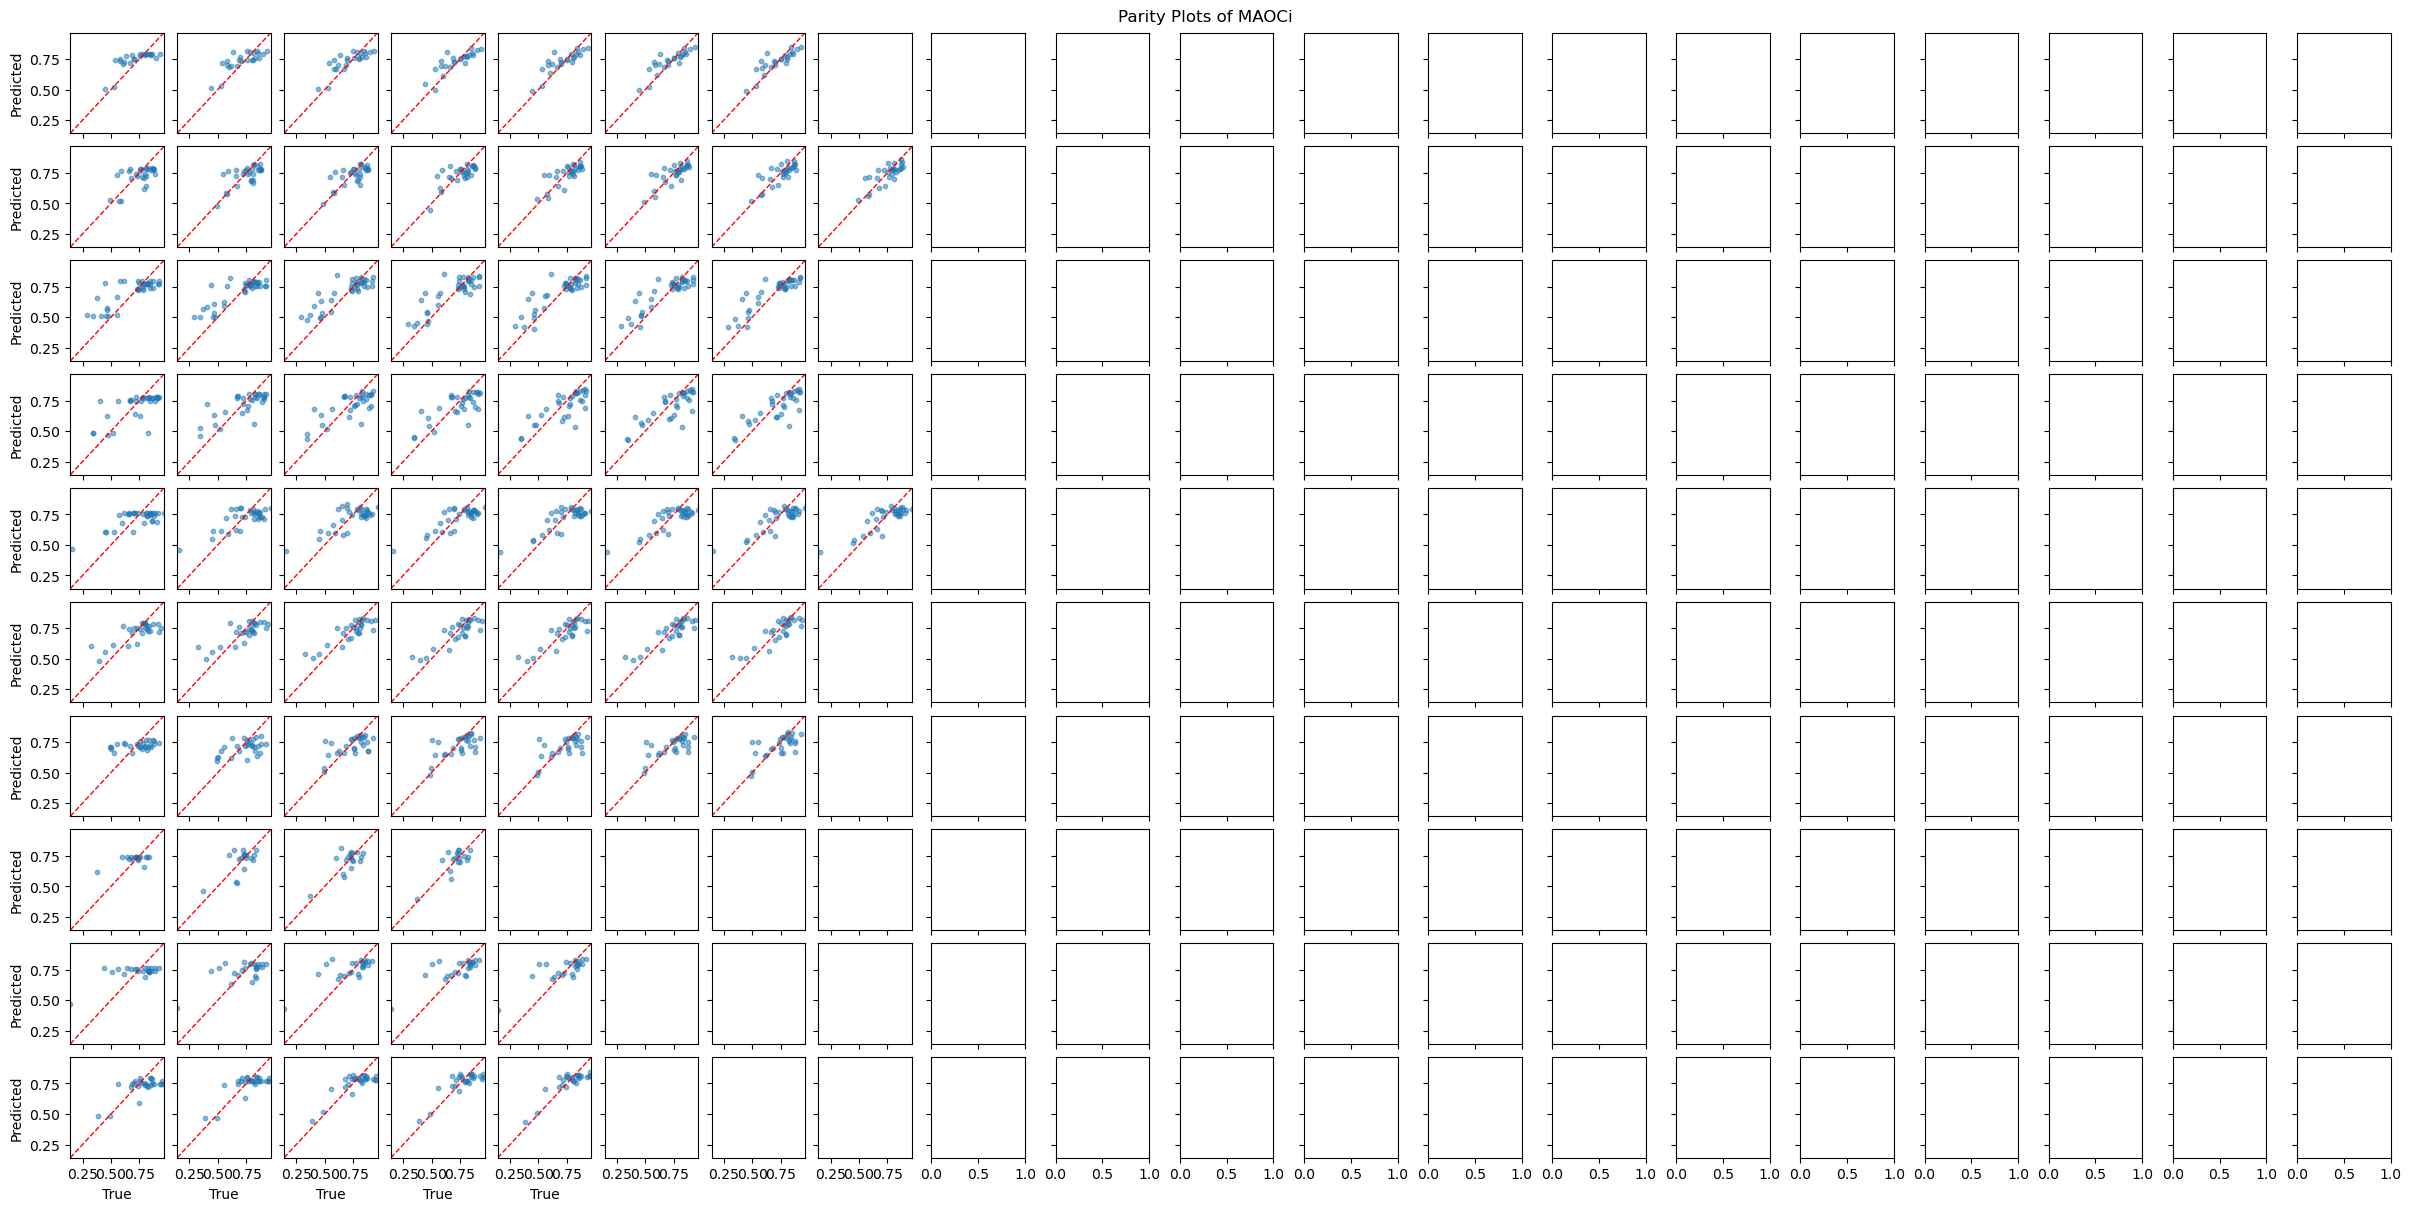

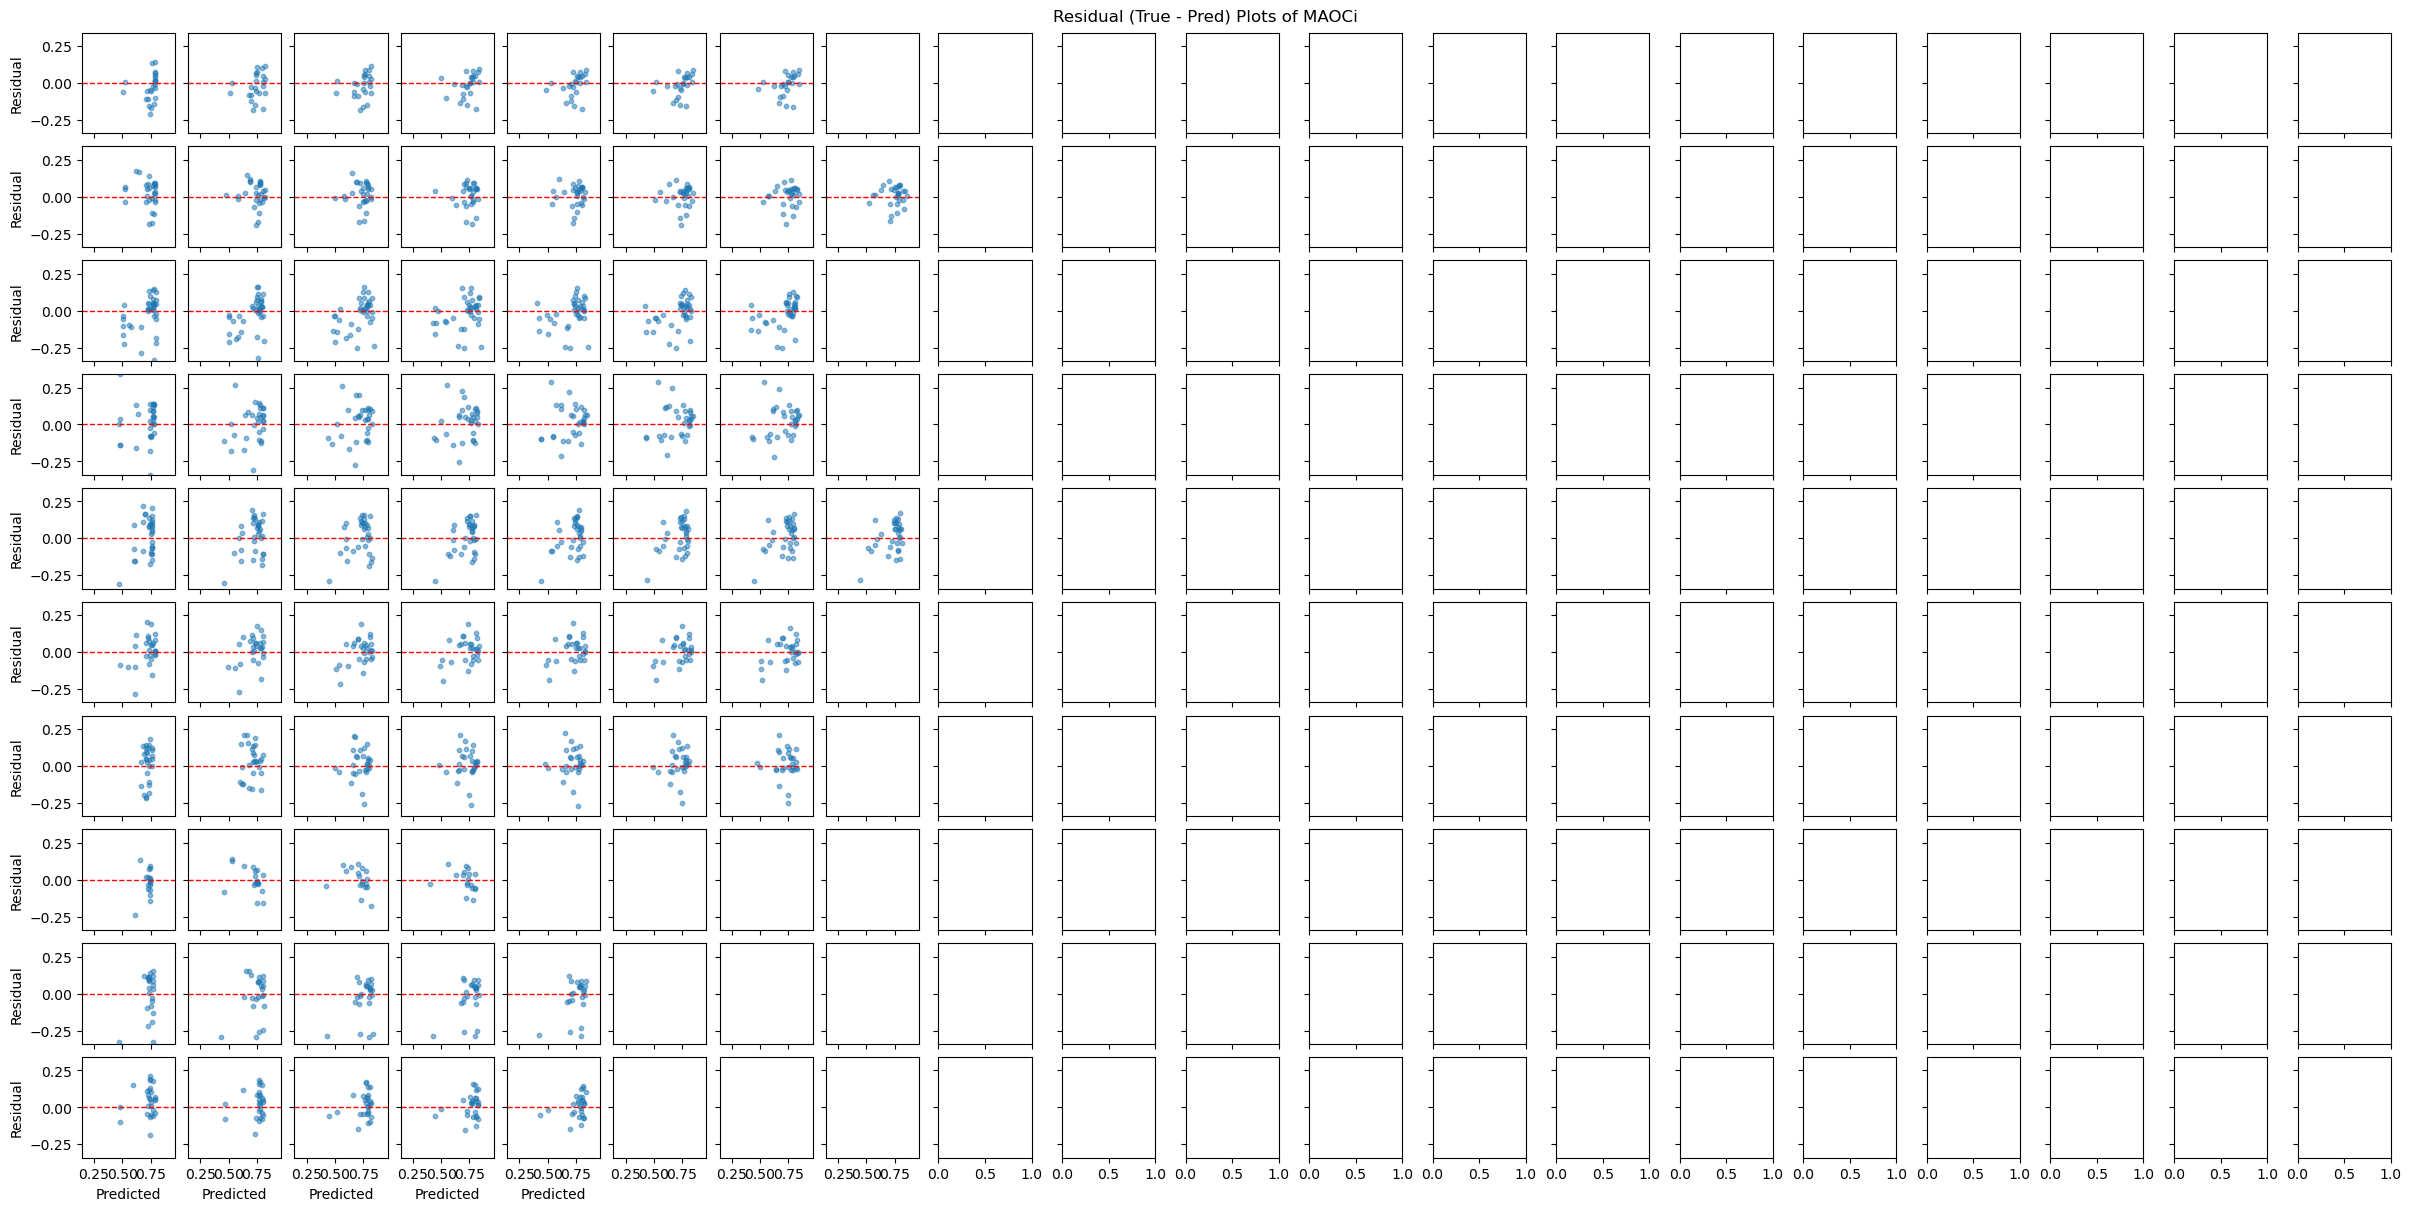

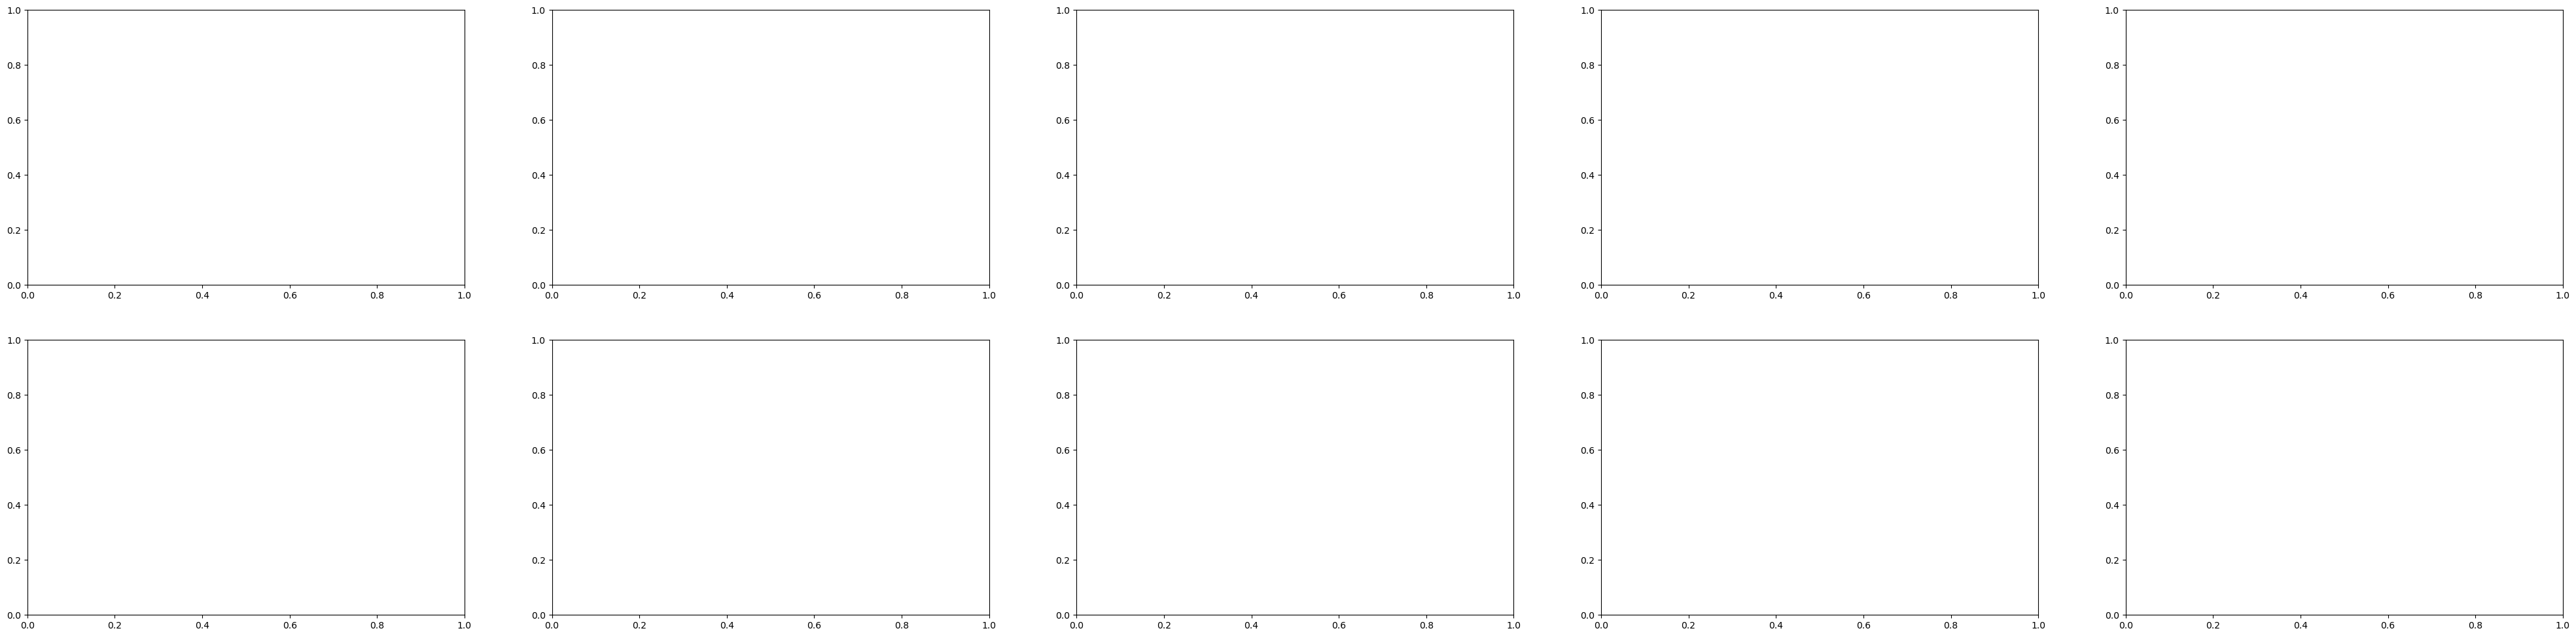

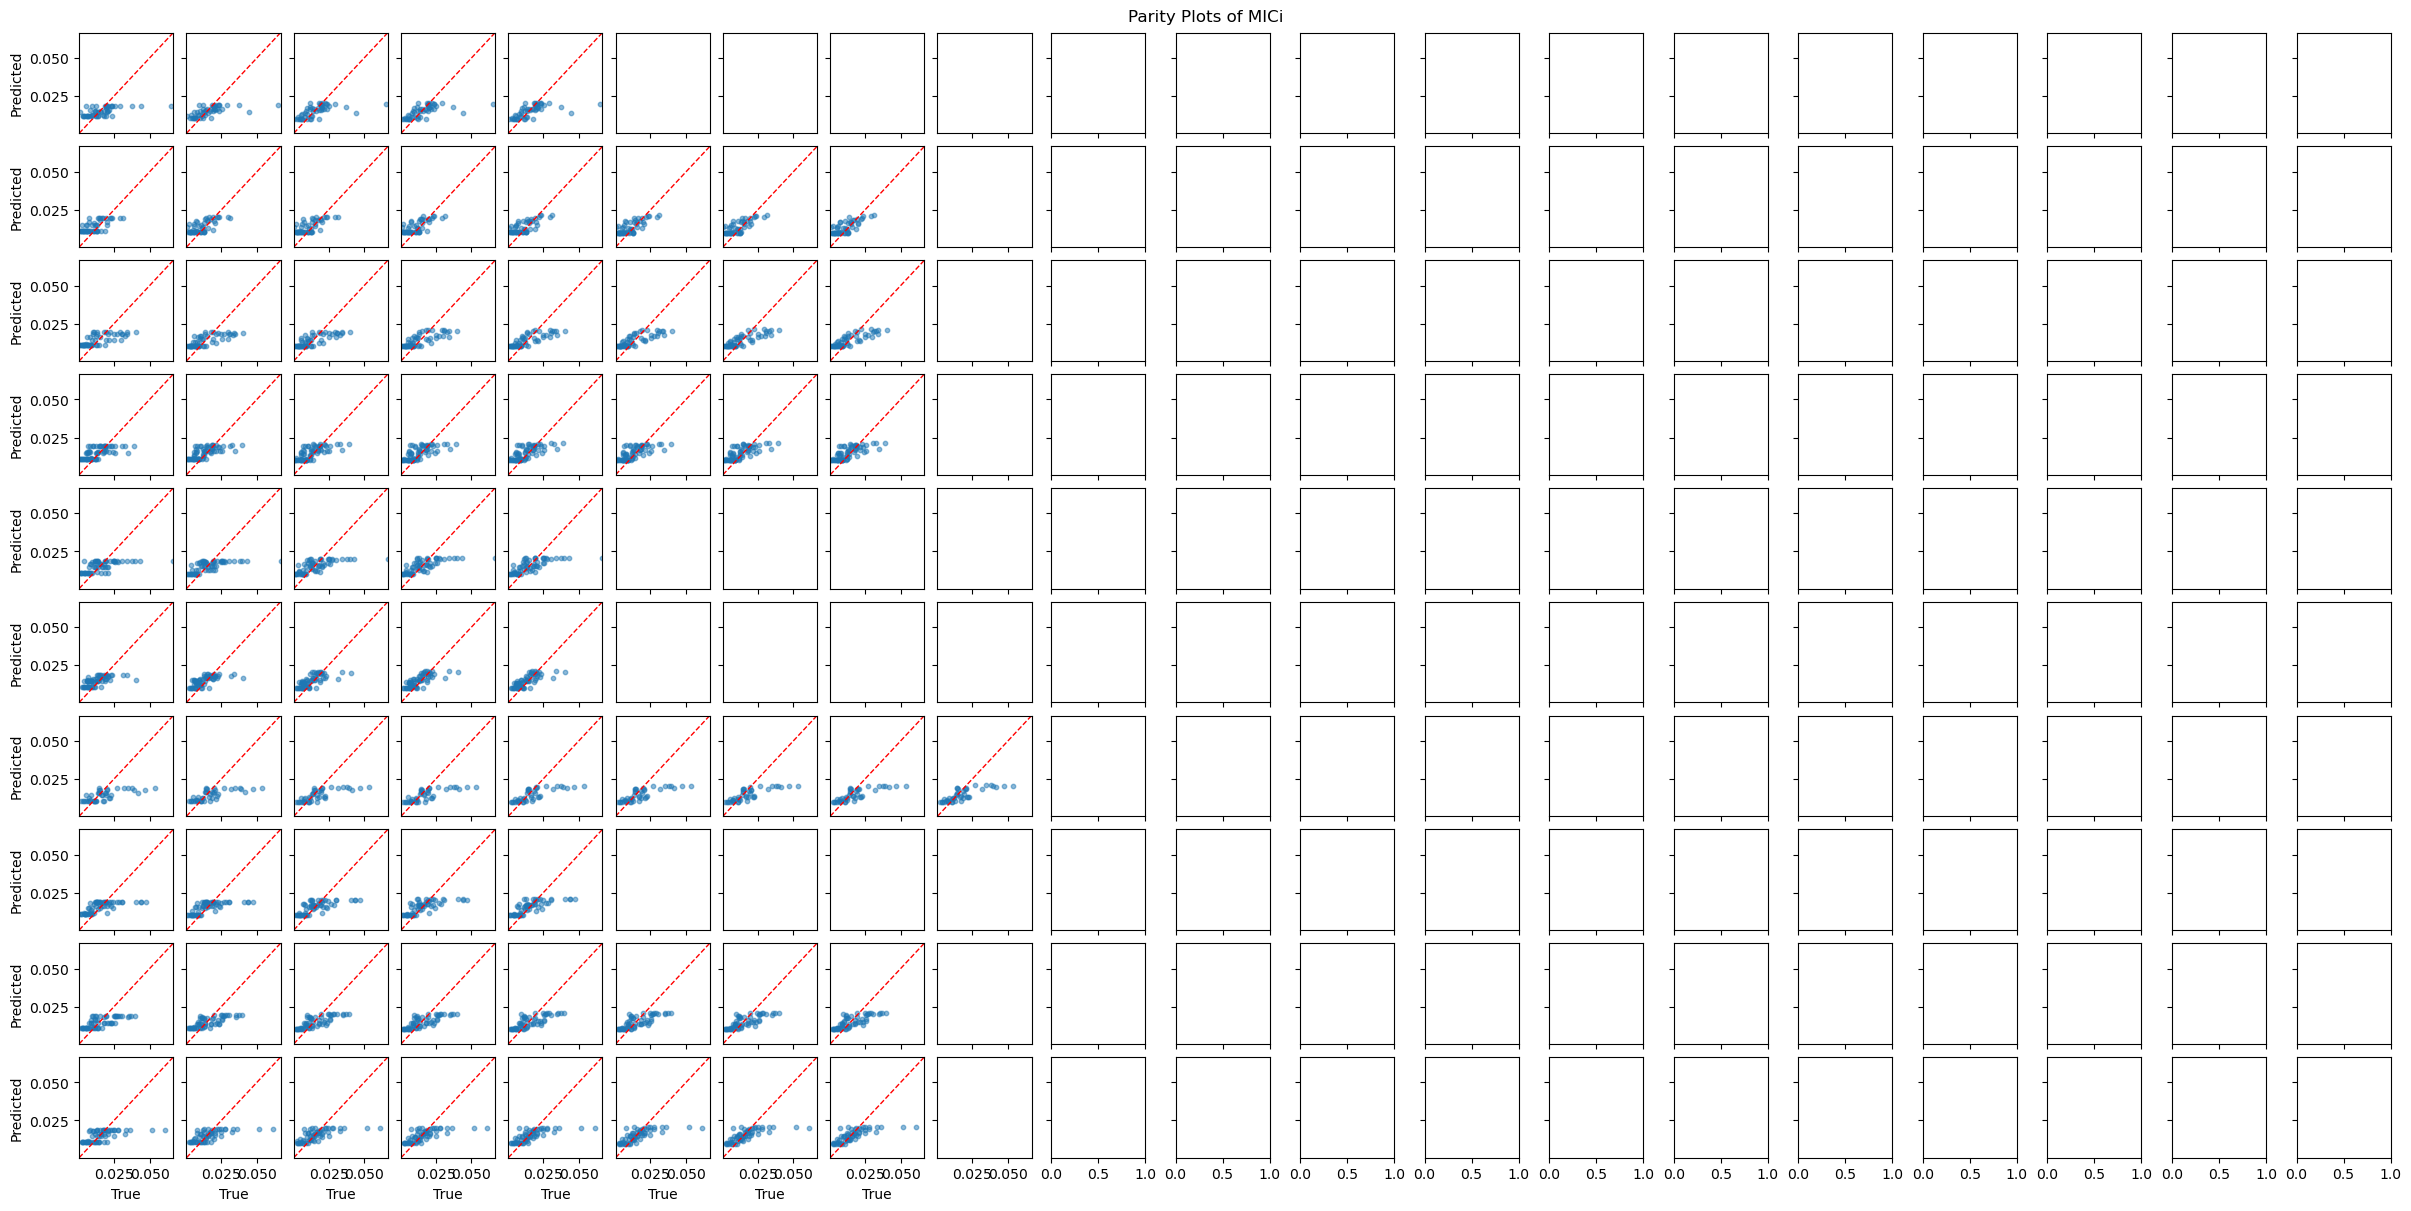

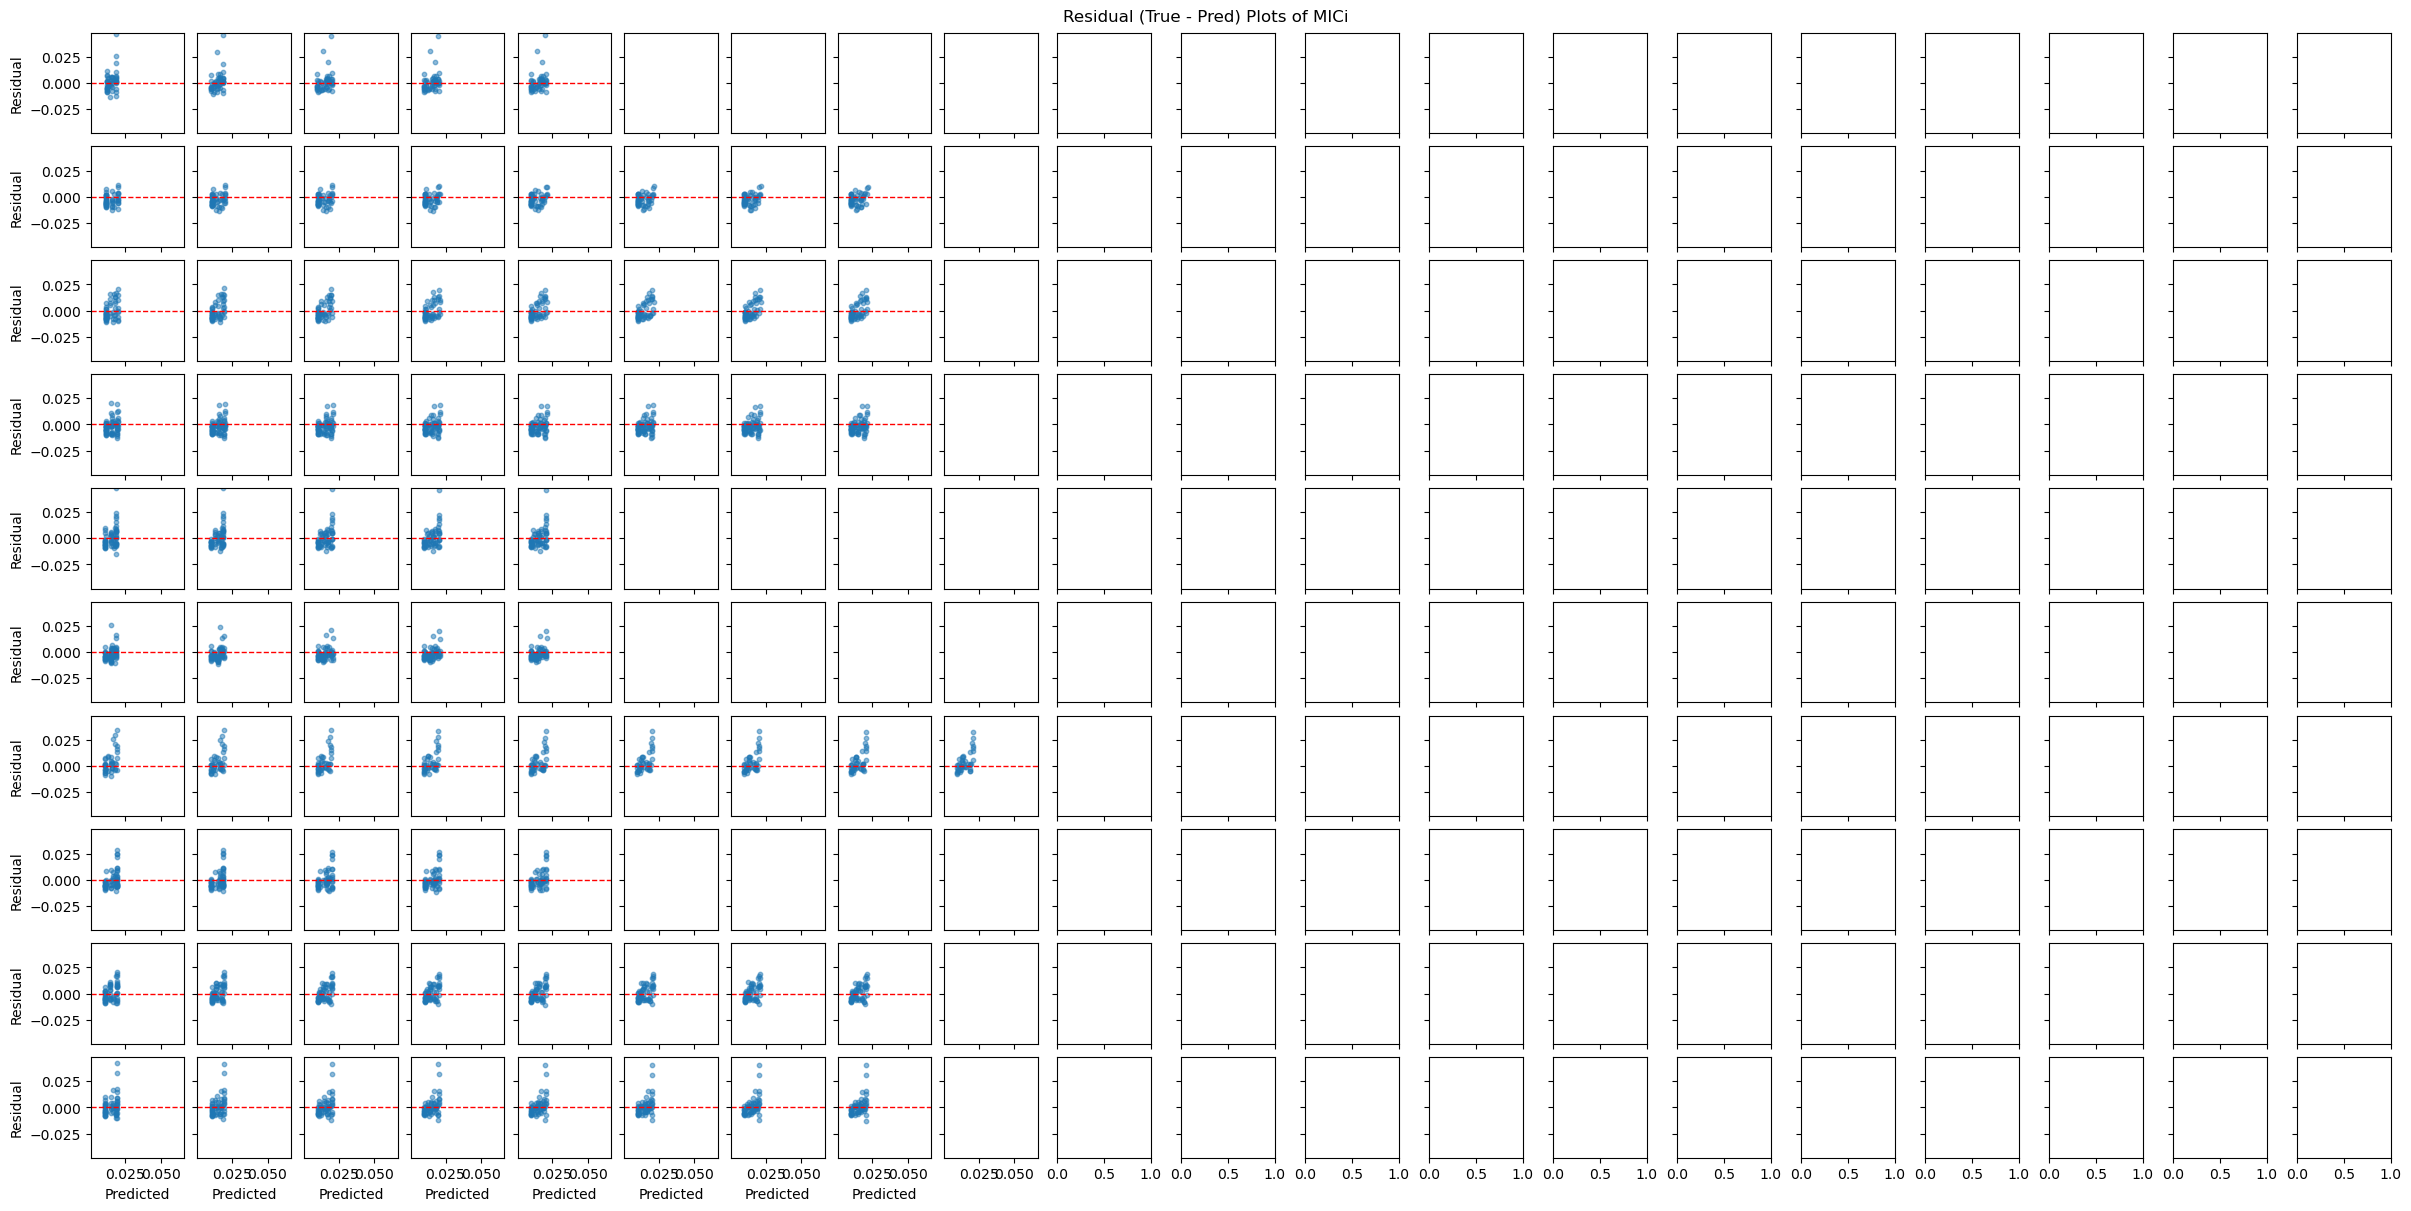

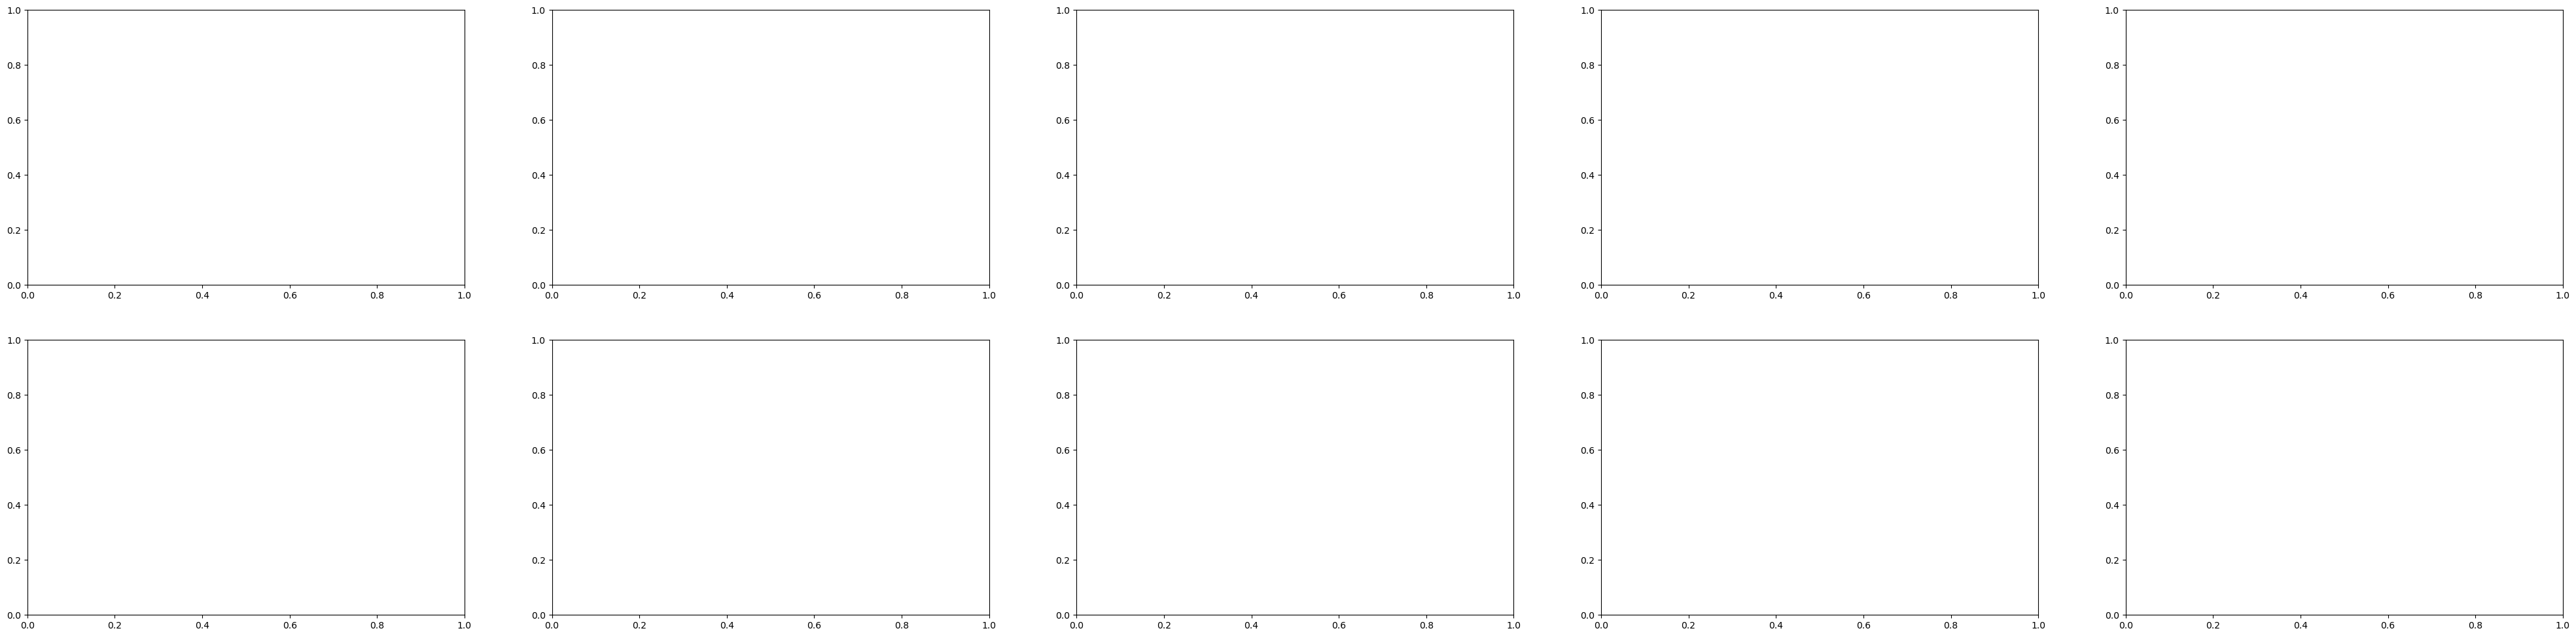

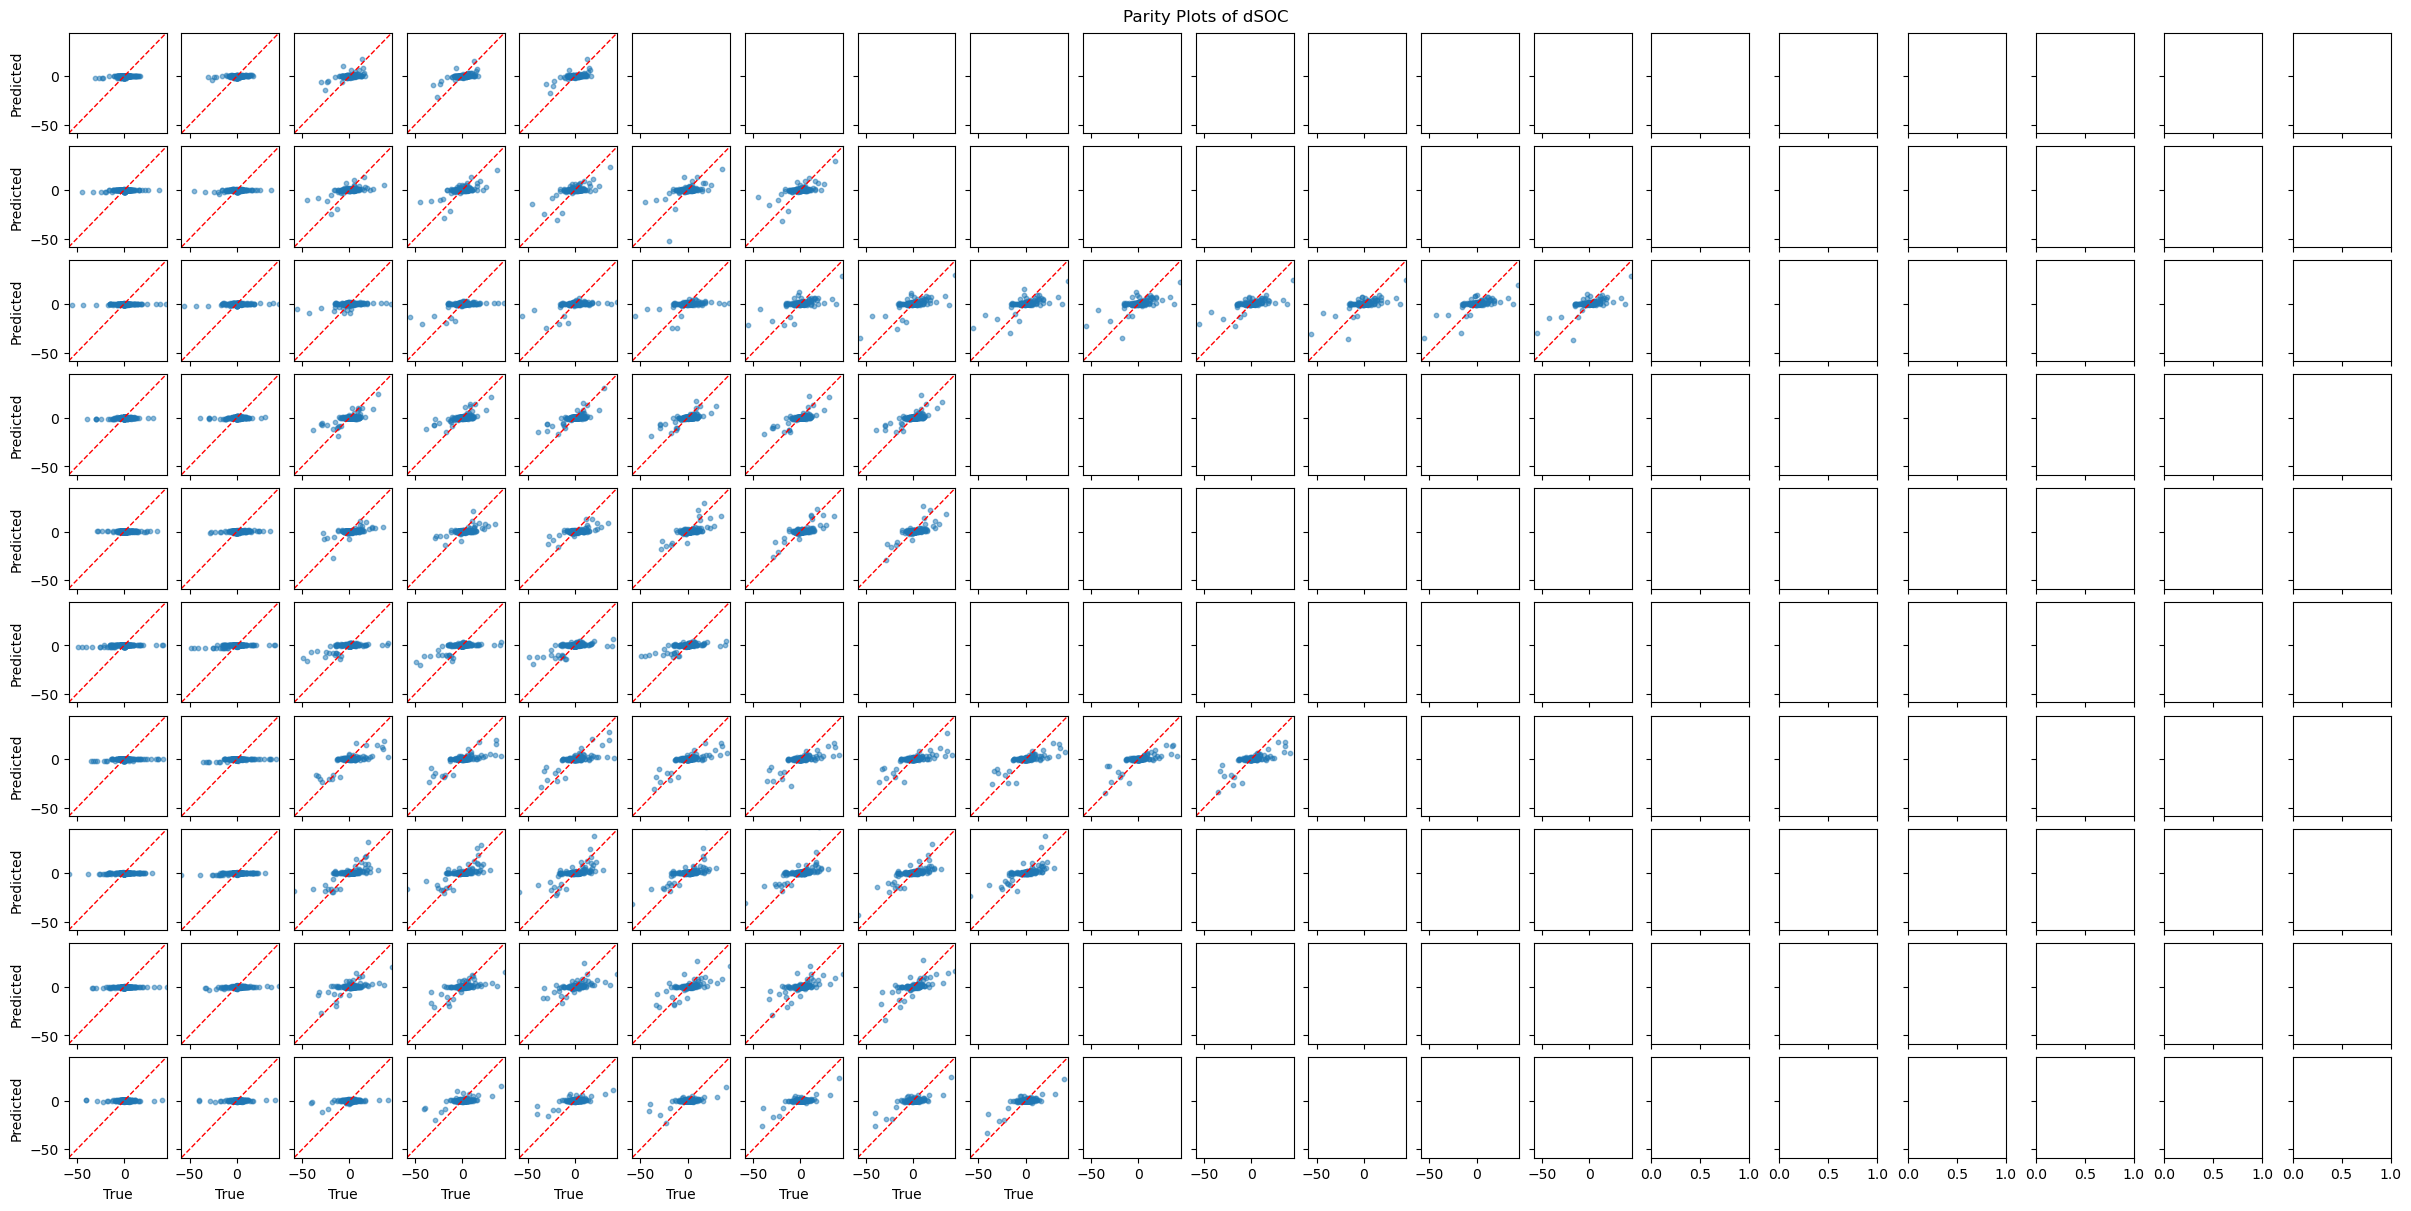

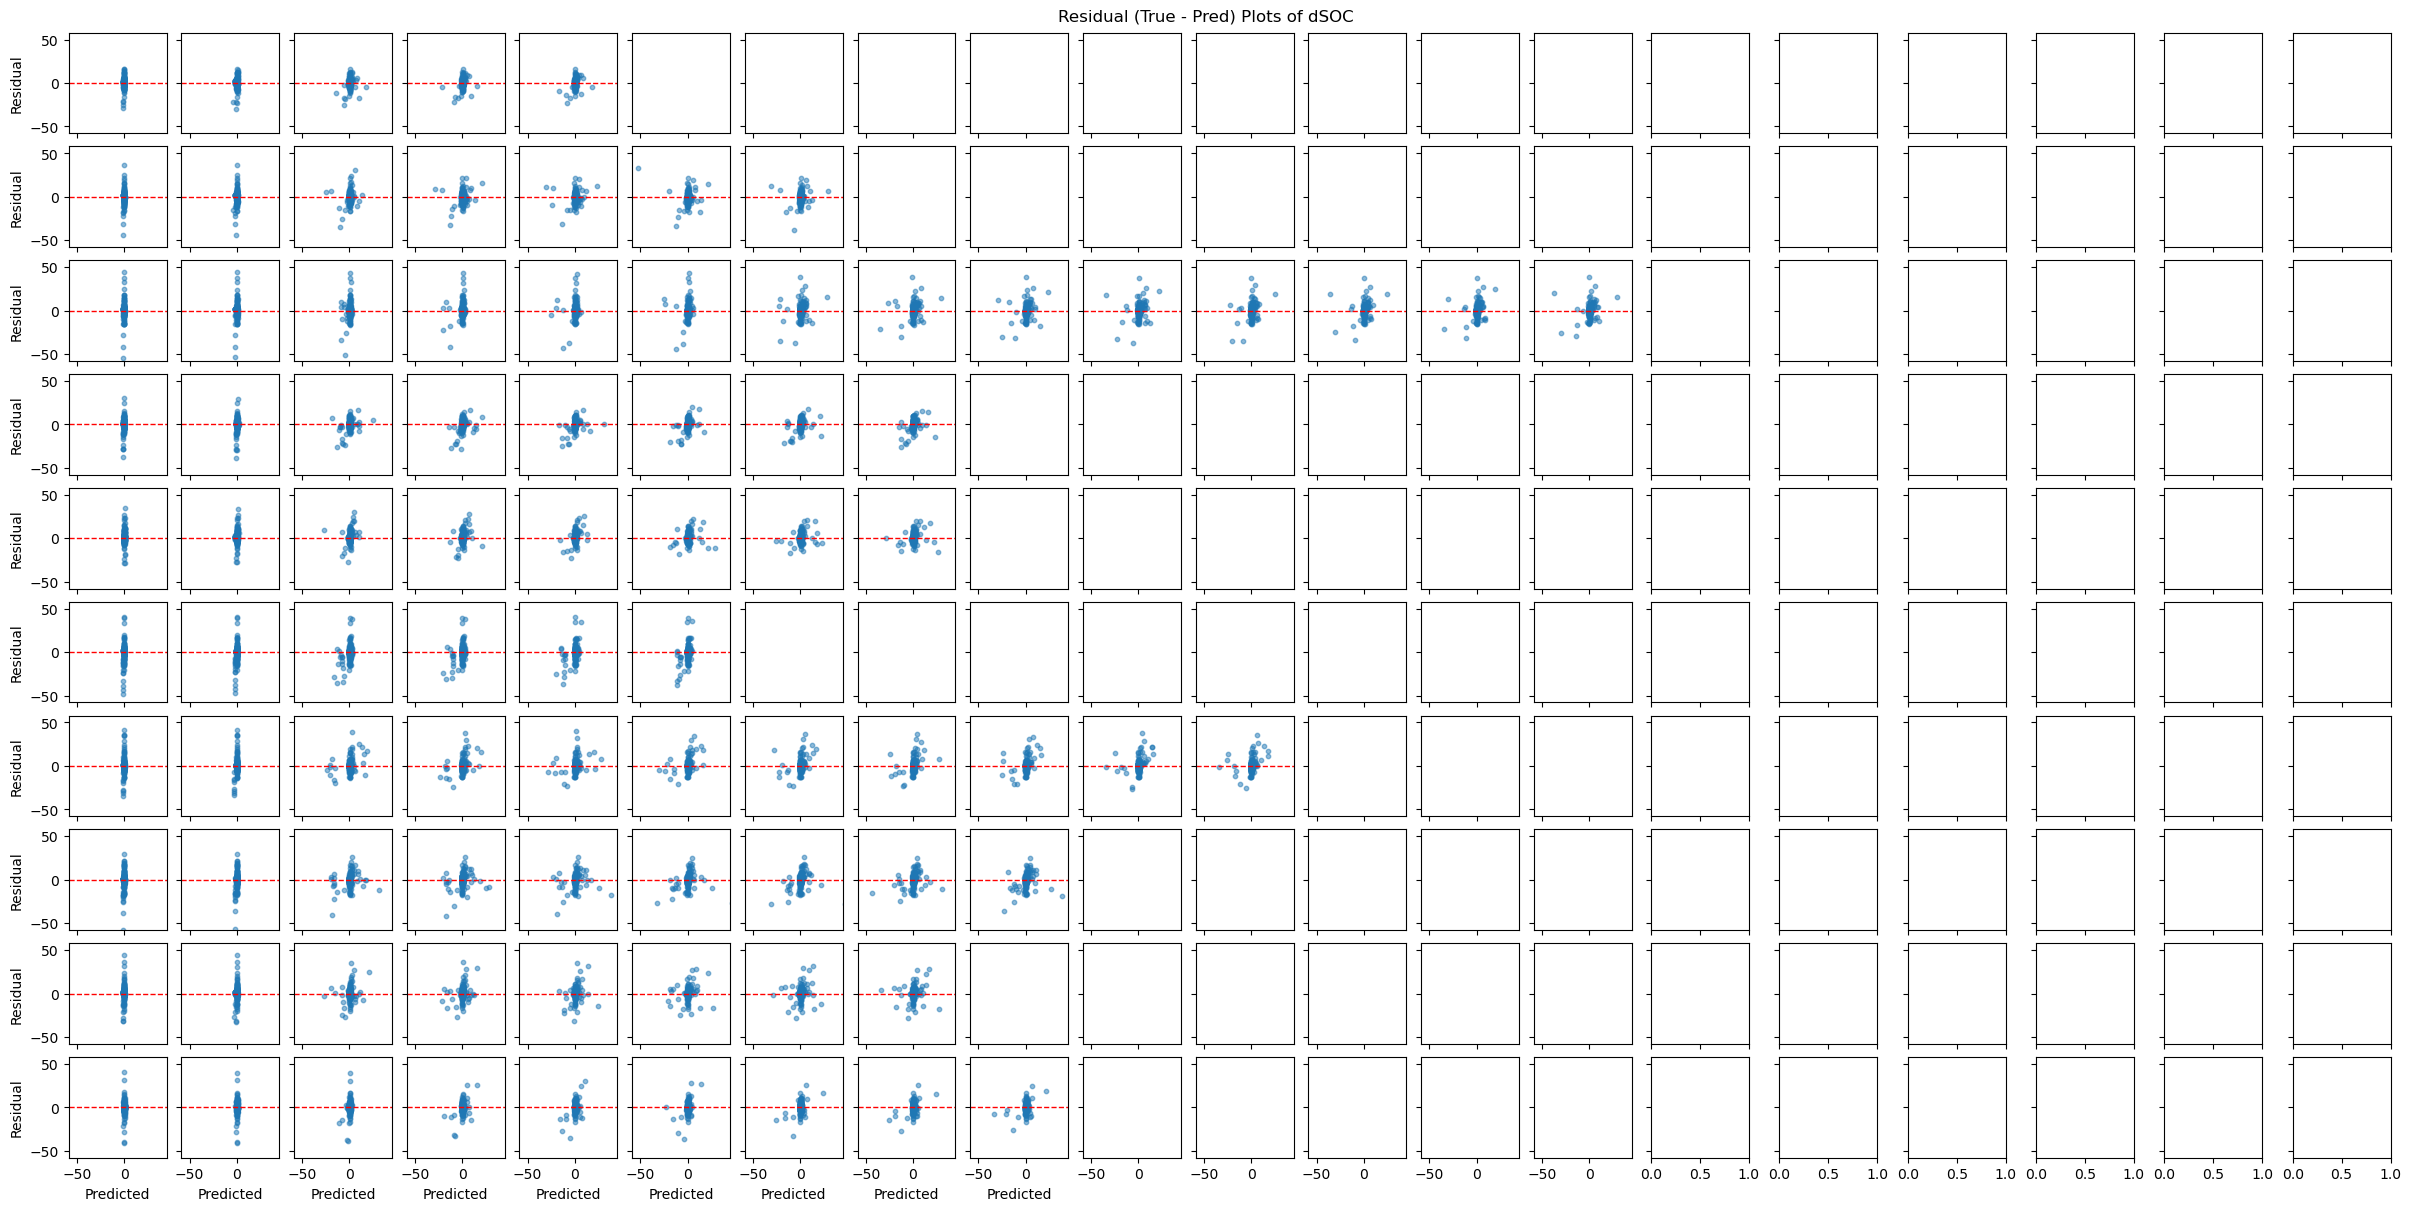

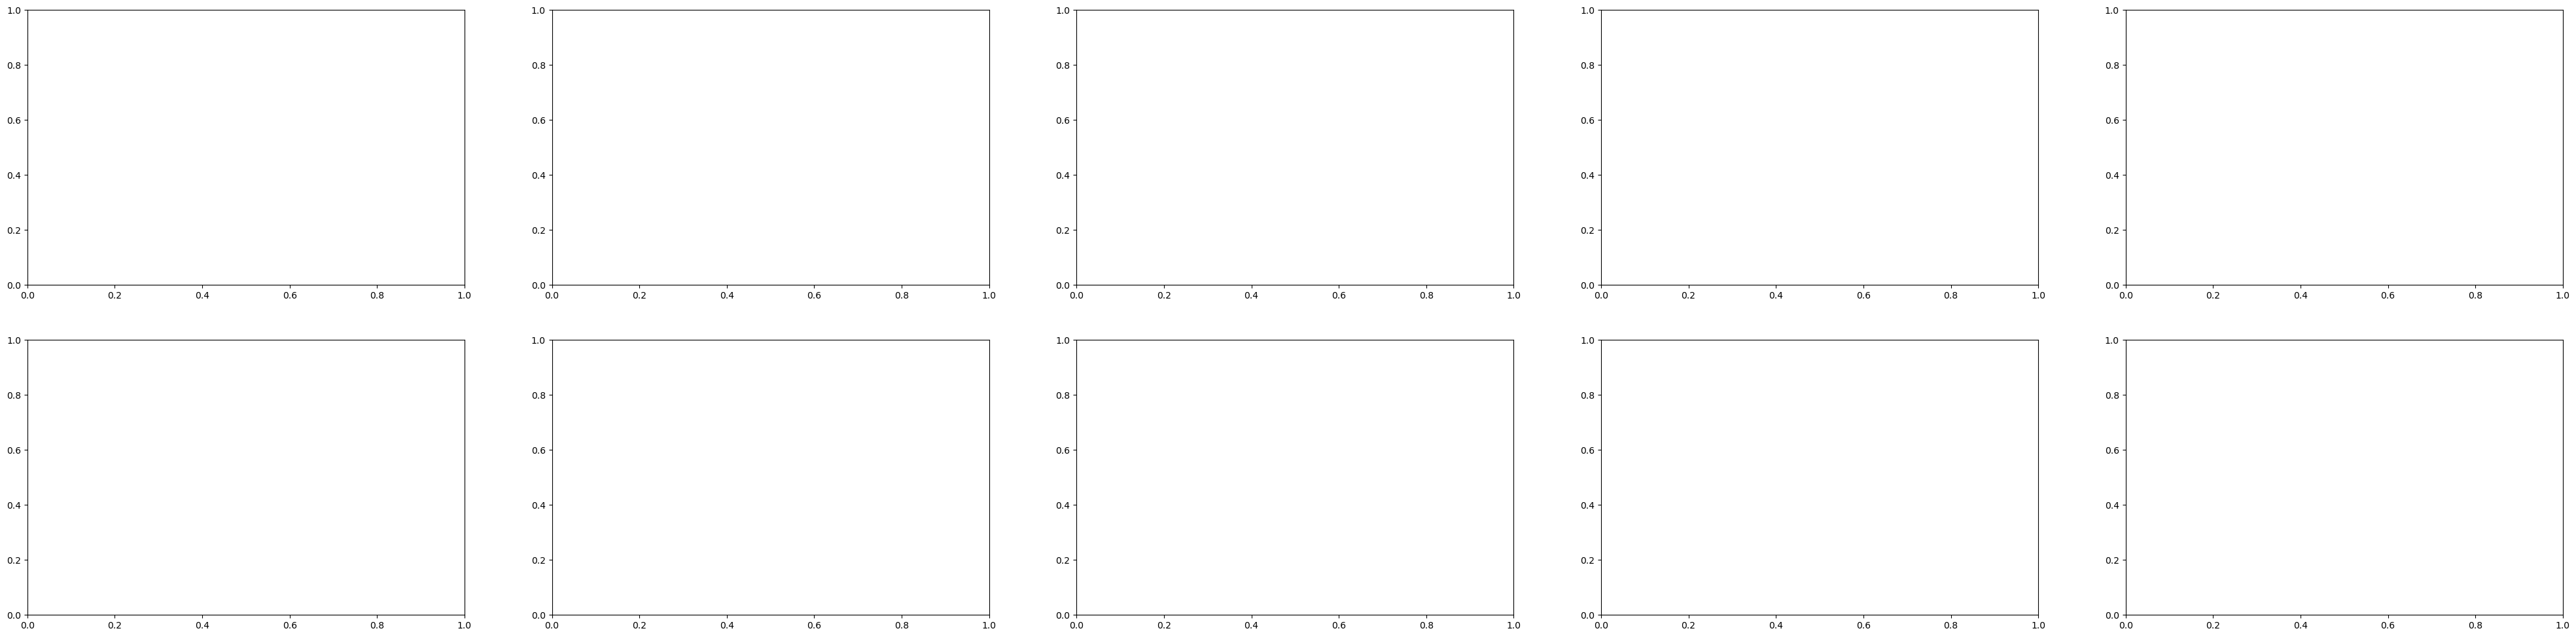

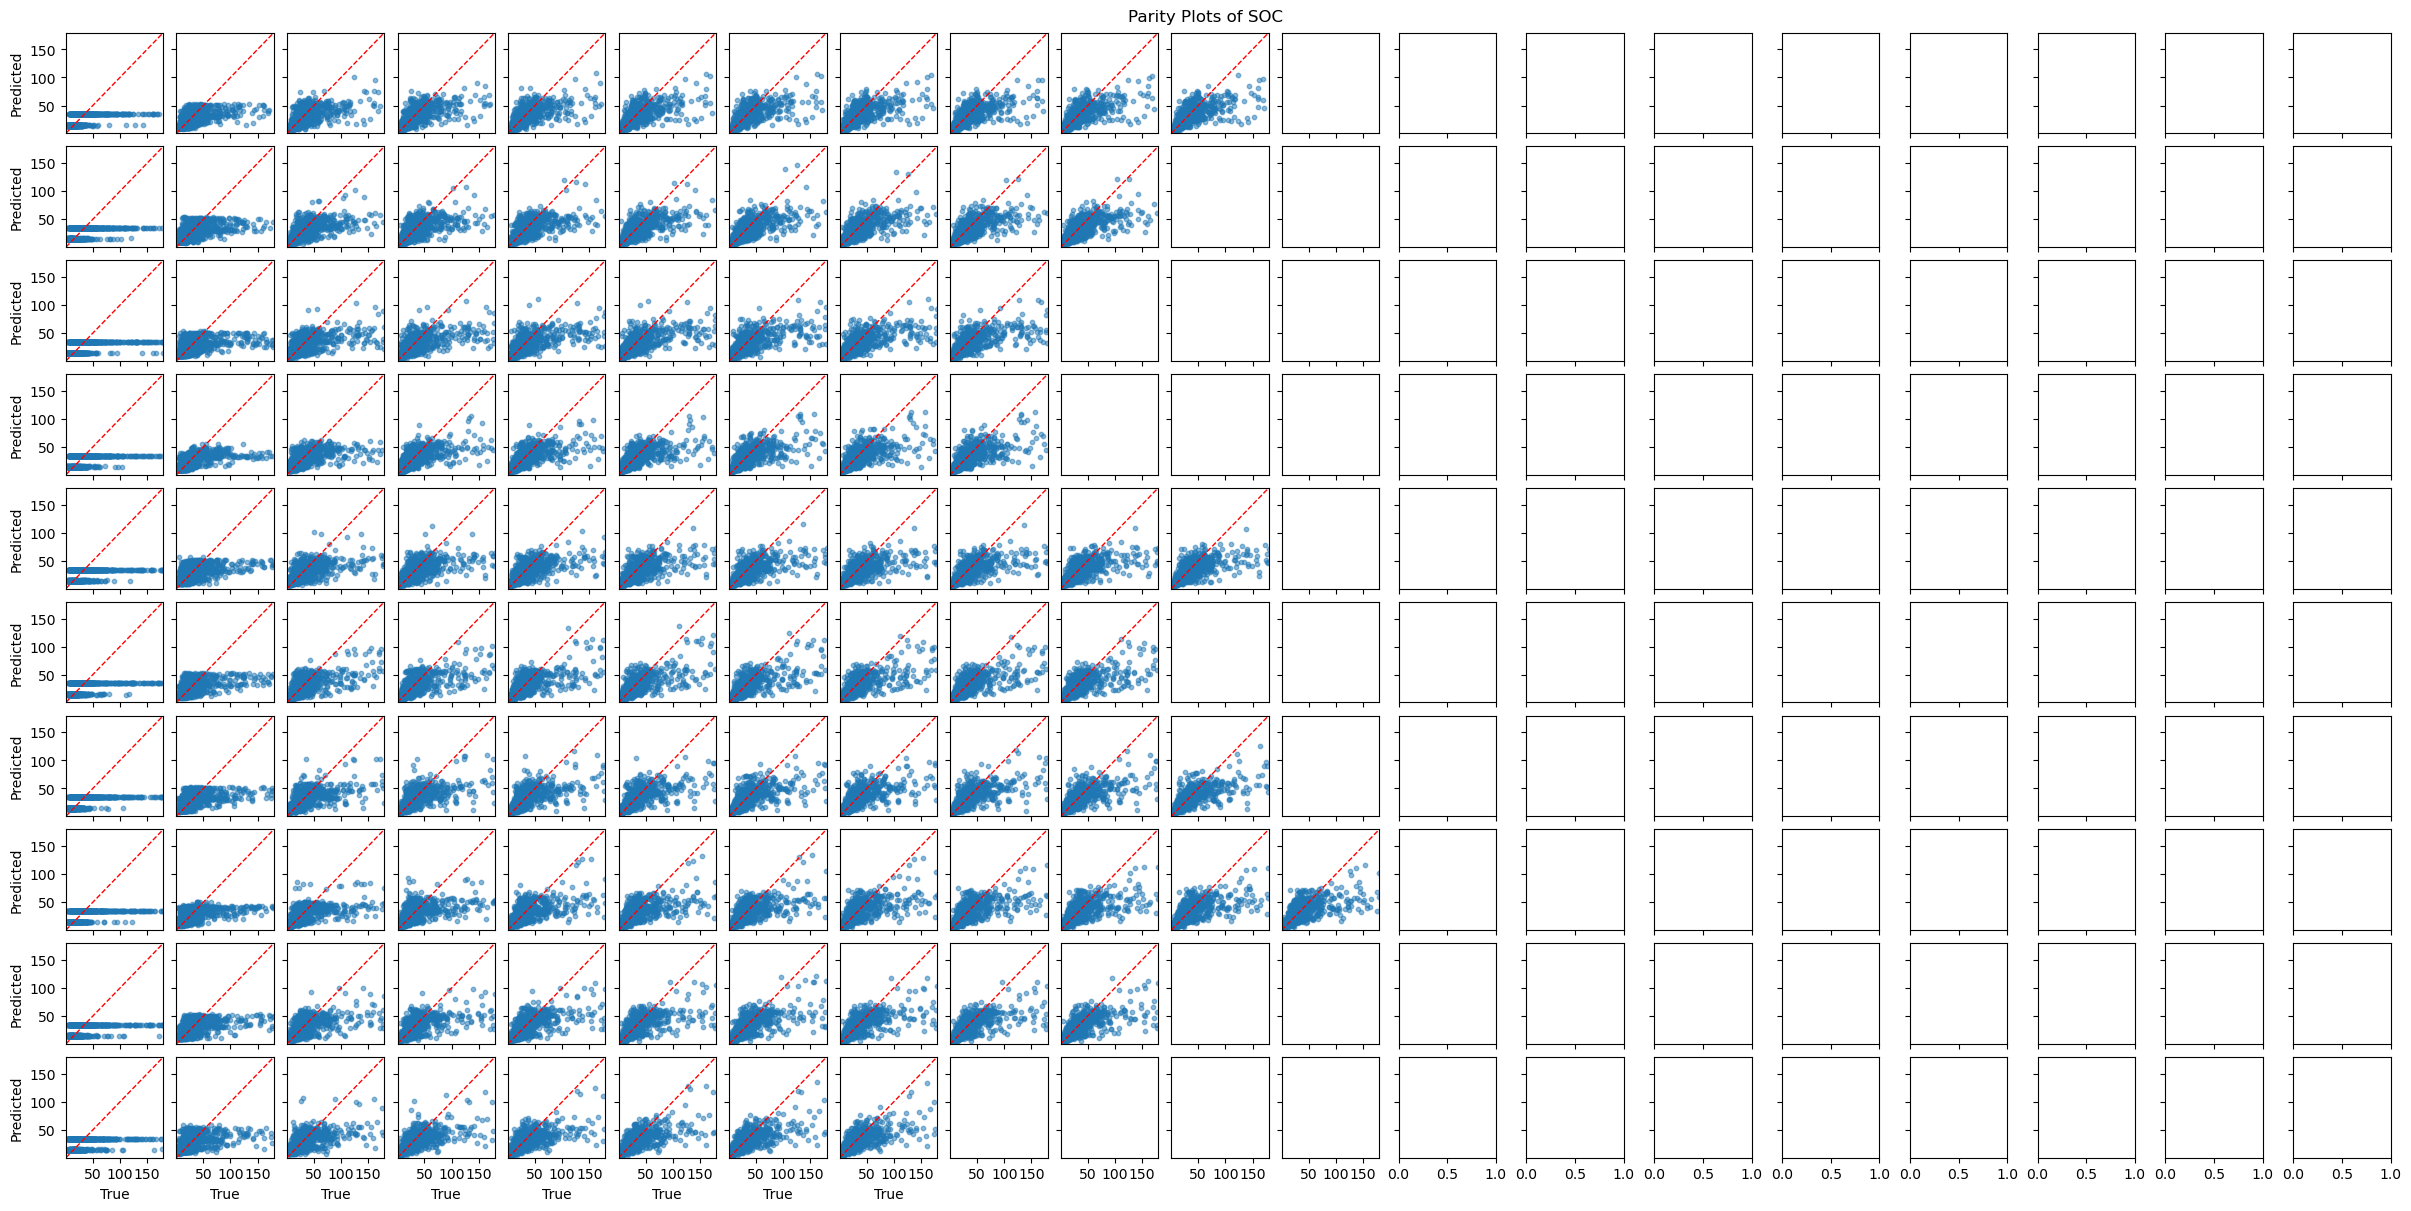

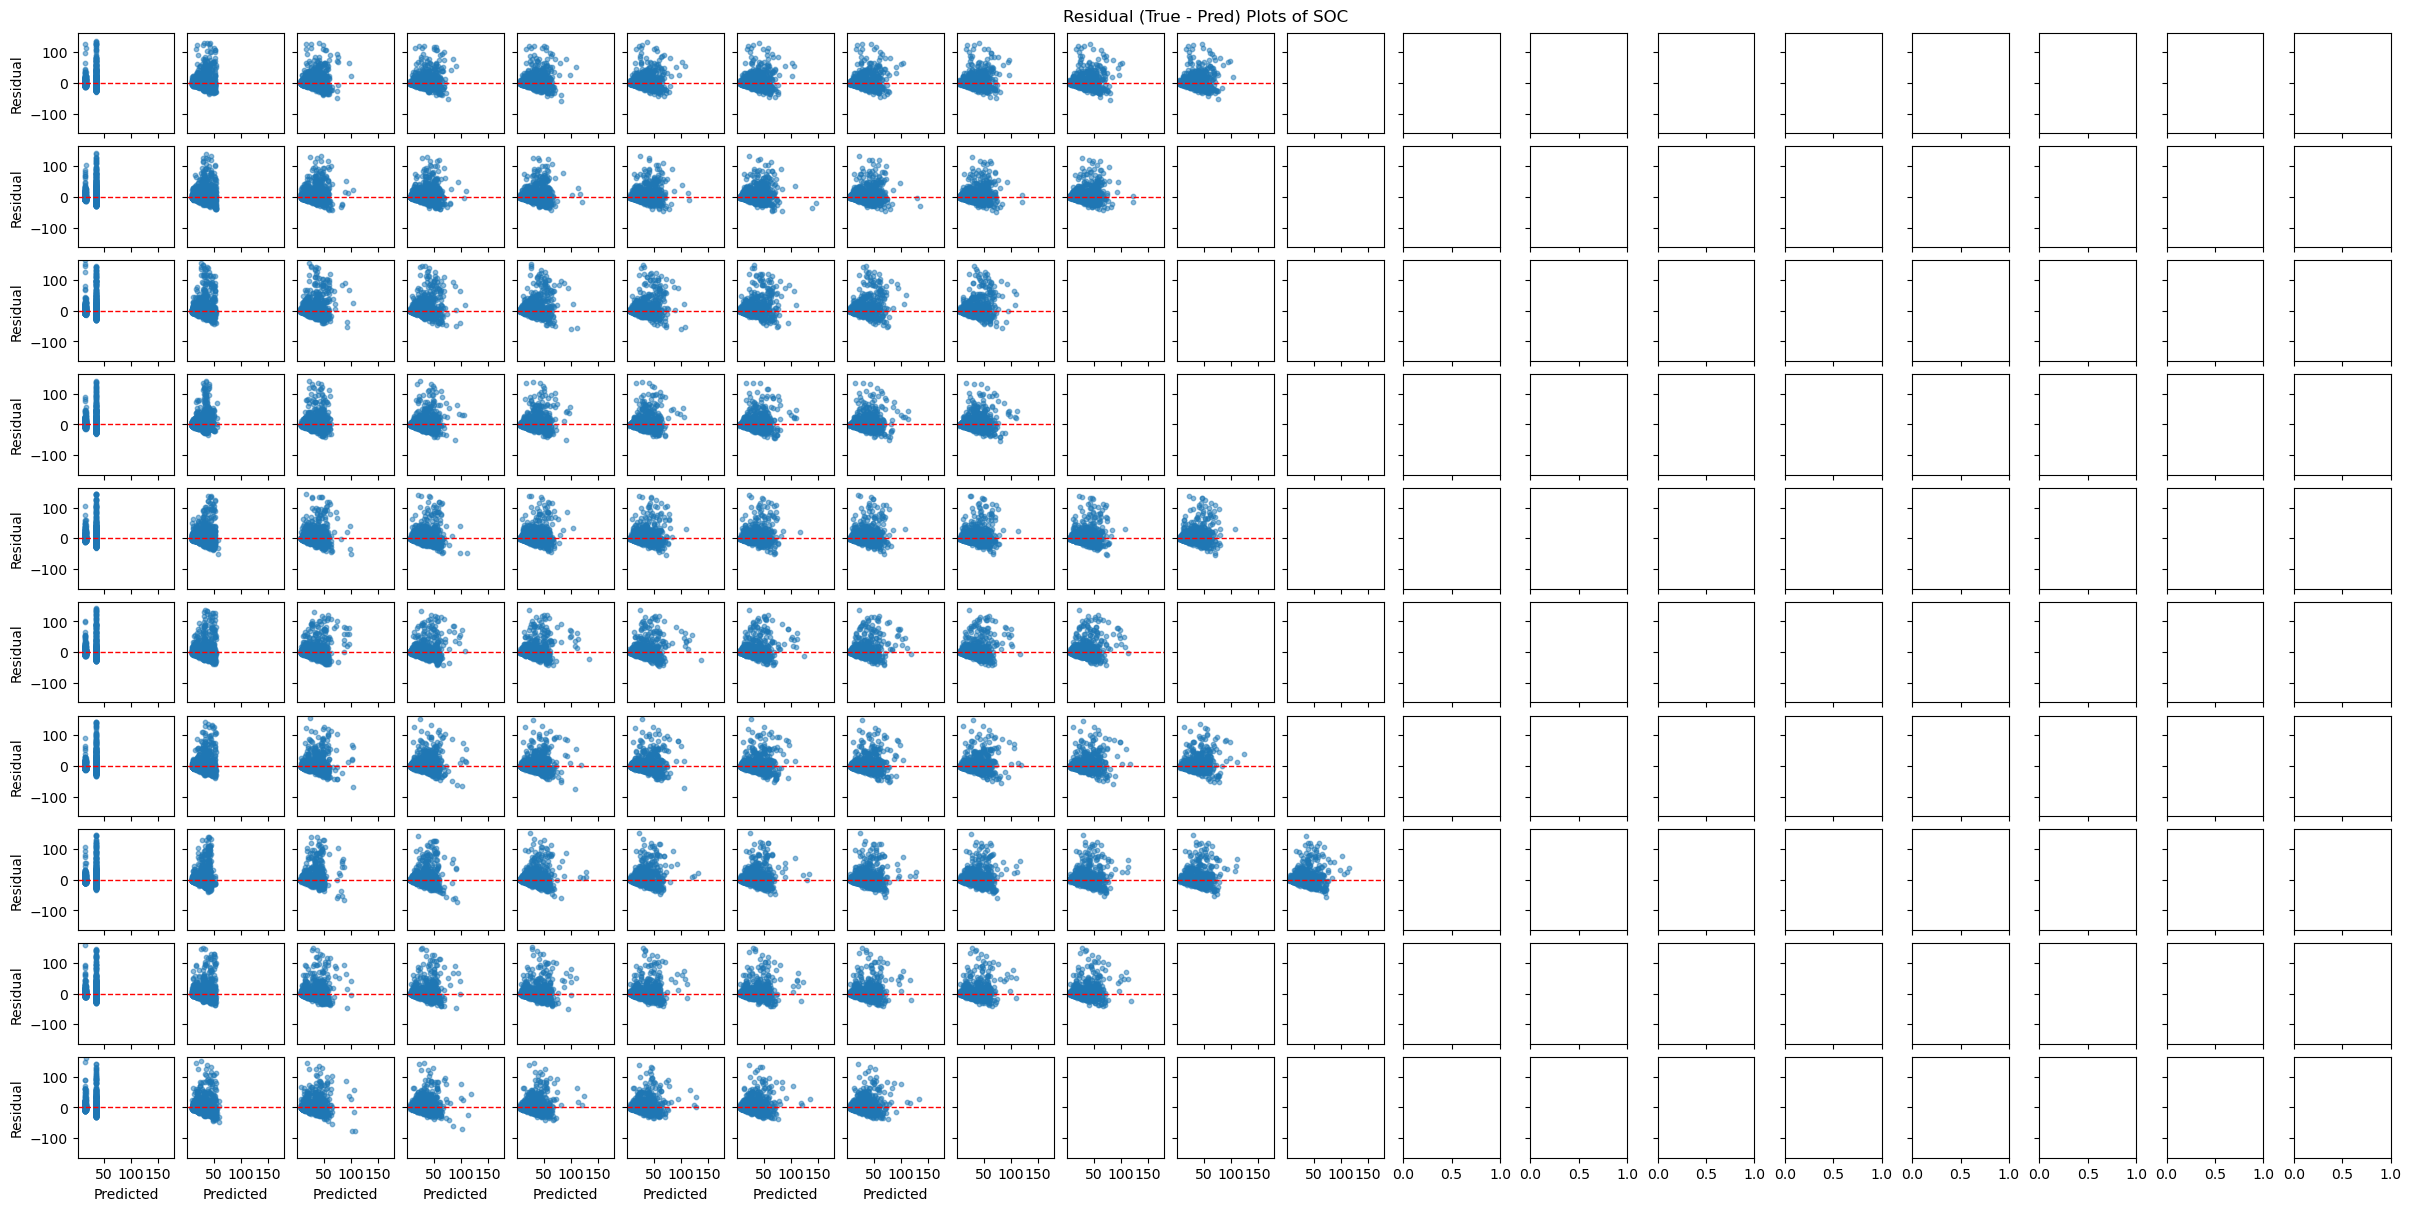

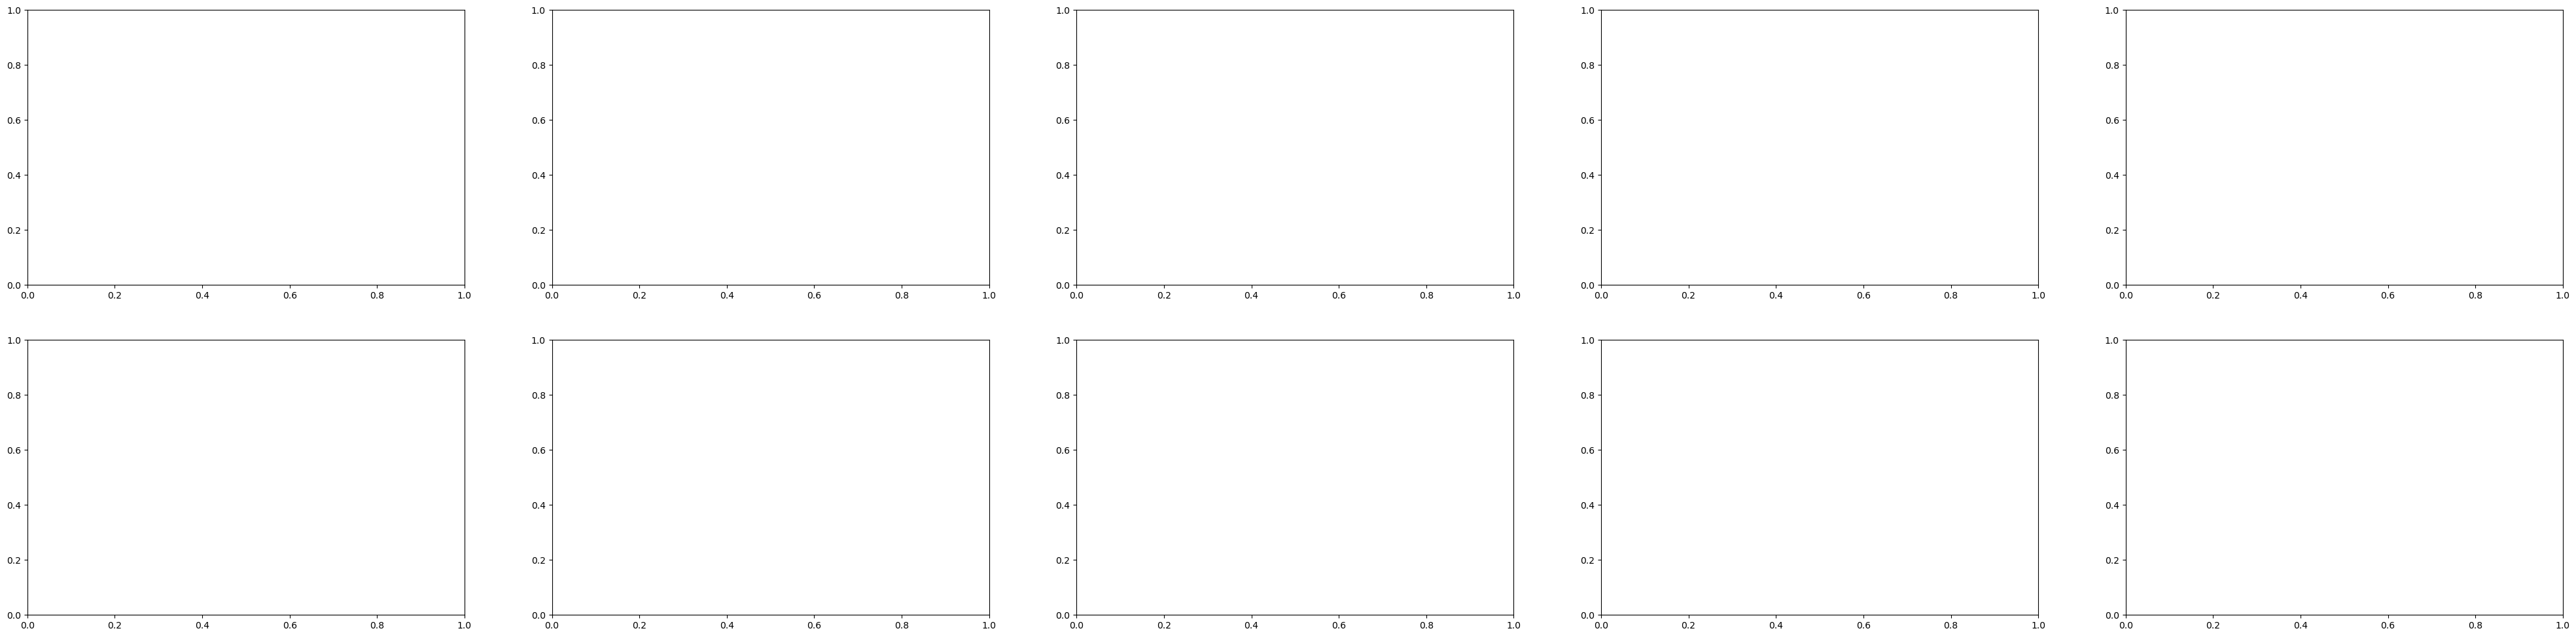

In [4]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import pickle

from config import TARGET_CONFIG, TRAIN_DEFAULTS, use_model, pred_groups, to_log
from models import get_models

models = get_models()
with open("1_preprocessed_intermediate.pkl", "rb") as f:
    df = pickle.load(f)



def to_signed_log(y):
    return np.sign(y) * np.log1p(np.abs(y))

def from_signed_log(y_log):
    y_log = np.clip(y_log, -np.log(np.finfo(np.float64).max), np.log(np.finfo(np.float64).max))
    return np.sign(y_log) * np.expm1(np.abs(y_log))

def refit_fold(target, fold, model_name, pred_cols, *, df=df, strict=True):
    meta = selection_meta_df[
        (selection_meta_df['var'] == target) &
        (selection_meta_df['fold'] == fold) &
        (selection_meta_df['model'] == model_name)
    ]
    meta = meta.iloc[0]
    config = TARGET_CONFIG[target]
    target_name = config['target_name']
    train_fit = df[(df['split'] != 'test') & (df['split'] != fold) & (df[target_name].notna())]
    val_fit   = df[(df['split'] != 'test') & (df['split'] == fold) & (df[target_name].notna())]
    test_fit = df[(df['split'] == 'test') & (df[target_name].notna())]
    # preprocess data


    predictors = []
    log_predictors = []
    predictor_groups = TARGET_CONFIG[target]['predictor_groups']
    for predictor_group in predictor_groups:
        for pred in pred_groups[predictor_group[0]][predictor_group[1]]:
            col = pred_groups[predictor_group[0]][predictor_group[1]][pred]
            if pred in to_log:
                log_predictors.append(col)
            else:
                predictors.append(col)

    pool_cols = list(predictors) + list(log_predictors)
    n_normal = len(predictors)
    n_log = len(log_predictors)
    sel = [pool_cols.index(c) for c in pred_cols]

    X_train = train_fit[pool_cols].to_numpy(dtype=float)
    X_val = val_fit[pool_cols].to_numpy(dtype=float)
    X_test = test_fit[pool_cols].to_numpy(dtype=float)
    X_train[:, n_normal:n_normal + n_log] = np.log1p(X_train[:, n_normal:n_normal + n_log])
    X_val[:, n_normal:n_normal + n_log] = np.log1p(X_val[:, n_normal:n_normal + n_log])
    X_test[:, n_normal:n_normal + n_log] = np.log1p(X_test[:, n_normal:n_normal + n_log])
    y_train = train_fit[target_name].to_numpy(dtype=float)
    y_val   = val_fit[target_name].to_numpy(dtype=float)
    y_test = test_fit[target_name].to_numpy(dtype=float)
    preprocessor = Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # impute 
        ('scaler', StandardScaler()), # z-score
    ])
    X_train_p = preprocessor.fit_transform(X_train) # z-core on train -> params
    X_val_p   = preprocessor.transform(X_val) # z-score with train params
    X_test_p = preprocessor.transform(X_test) # z-score with train params
    y_fit = to_signed_log(y_train) if bool(meta['target_logged']) else y_train # log transform target?
    model = _make_model(models[model_name], meta['params'], n_features=len(sel)) # init model
    model.fit(X_train_p[:, sel], y_fit) # fit on train

    # predict
    y_train_pred = model.predict(X_train_p[:, sel])
    y_val_pred = model.predict(X_val_p[:, sel])
    y_test_pred = model.predict(X_test_p[:, sel])

    # If the target was log-transformed, invert it
    if bool(meta['target_logged']):
        y_train_pred = from_signed_log(y_train_pred)
        y_val_pred = from_signed_log(y_val_pred)
        y_test_pred = from_signed_log(y_test_pred)

    # calculate R2
    r2_train = r2_score(y_train, y_train_pred)
    r2_val = r2_score(y_val, y_val_pred)
    r2_test = r2_score(y_test, y_test_pred)

    return {
        'model': model,
        'preprocessor': preprocessor,
        'pool_cols': pool_cols,
        'sel': sel,
        'pred_cols': pred_cols,
        'X_train': X_train_p[:, sel],
        'X_val': X_val_p[:, sel],
        'y_train': y_train,
        'y_val': y_val,
        'y_fit': y_fit,
        'feature_names': pred_cols,
        'target_logged': meta['target_logged'],
        'target_name': target_name,
        'model_name': model_name,
        'params': meta['params'],
        'meta': meta,
        'r2_train': r2_train,
        'r2_val': r2_val,
        'r2_test': r2_test,
        'y_train_pred': y_train_pred,
        'y_val_pred': y_val_pred,
        'y_test_pred': y_test_pred
    }






import shap
import xgbfir
from pathlib import Path
import matplotlib.pyplot as plt

shap_dir = Path('figures/shap')
shap_dir.mkdir(parents=True, exist_ok=True)

for i in range(1, 21): 
    plot_df_copy[f'R2 {i}'] = np.nan

for target in TARGET_CONFIG:
    model_name = use_model.get(target, 'XGB-n')
    nrows, ncols = 10, 20

    # init parent parity and residual plots
    fig_parity, axs_parity = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 1.2, nrows * 1.2), sharex='col', sharey='row', constrained_layout=True)
    fig_parity.suptitle(f"Parity Plots of {target}")
    fig_residual, axs_residual = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 1.2, nrows * 1.2), sharex='col', sharey='row', constrained_layout=True)
    fig_residual.suptitle(f"Residual (True - Pred) Plots of {target}")
    x_min, x_max = np.inf, -np.inf
    res_range = 0

    fig_bee, axes_bee = plt.subplots(2, 5, figsize=(50, 12))
    fig_effect, axes_effect = plt.subplots(10, len(TARGET_CONFIG[target]["selected_predictors"]), figsize=(10*len(TARGET_CONFIG[target]["selected_predictors"]), 60))
    fig_interaction, axes_interaction = plt.subplots(2, 5, figsize=(50, 12))

    y_test_true_dict = {}
    y_test_pred_dict = {}

    int_dir = Path(f'figures/shap/{target}')
    int_dir.mkdir(parents=True, exist_ok=True)

    for fold, (ax_bee, ax_effect, ax_interaction) in enumerate(zip(axes_bee.flatten(), axes_effect.flatten(), axes_interaction.flatten())):
        row = selection_meta_df[(selection_meta_df['var'] == target) & (selection_meta_df['fold'] == fold) & (selection_meta_df['model'] == model_name)]
        pred_cols = row.iloc[0]['selected_predictors']
        for n_preds in range(1, len(pred_cols)+1):
            predictors = pred_cols[:n_preds]
            bundle = refit_fold(target, fold, model_name, predictors)
            plot_df_copy.loc[(plot_df_copy['var'] == target) & (plot_df_copy['fold'] == fold), f'R2 {n_preds}'] = bundle['r2_test']
            y_test_true = bundle['y_val']
            y_test_pred = bundle['y_val_pred']
            idx = (fold, n_preds-1)
            y_test_true_dict[idx] = y_test_true
            y_test_pred_dict[idx] = y_test_pred

            # for min/max x/y limits:
            x_min = min(x_min, np.nanmin(y_test_true))
            x_max = max(x_max, np.nanmax(y_test_true))
            res_range = max(res_range, np.nanmax(np.abs(y_test_pred - y_test_true)))

            # Parity plot (defer axis limits to second loop!)
            ax_parity = axs_parity[fold, n_preds-1]
            ax_parity.scatter(y_test_true, y_test_pred, s=10, alpha=0.5)
            ax_parity.plot([], [], 'r--', lw=1)  # Plot parity line in next loop.
            if fold == nrows - 1:
                ax_parity.set_xlabel("True")
            if n_preds == 1:
                ax_parity.set_ylabel("Predicted")

            # Residual plot (prediction error vs. true)
            residuals = y_test_true - y_test_pred
            ax_residual = axs_residual[fold, n_preds-1]
            ax_residual.scatter(y_test_pred, residuals, s=10, alpha=0.5)
            ax_residual.axhline(0, color='r', linestyle='--', lw=1)
            if fold == nrows - 1:
                ax_residual.set_xlabel("Predicted")
            if n_preds == 1:
                ax_residual.set_ylabel("Residual")

        # shap beeswarm
        bundle = refit_fold(target, fold, model_name, TARGET_CONFIG[target]["selected_predictors"])
        model       = bundle['model']
        X_train     = bundle['X_train']   # preprocessed (z-scored), selected columns
        X_val       = bundle['X_val']     # preprocessed (z-scored), selected columns
        feat_names  = bundle['feature_names']
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_val)
        explanation = shap.Explanation(
            values=shap_values,          # shape (n_samples, n_features)
            base_values=explainer.expected_value,
            data=X_val,                  # the data used for coloring
            feature_names=feat_names,)
        plt.sca(ax_bee)
        shap.summary_plot(
            shap_values,
            bundle['X_val'],
            feature_names=bundle['feature_names'],
            max_display=20,
            show=False,
            plot_size=None,)   # don't let SHAP resize the figure

        # shap effect
        for i, feat in enumerate(feat_names):
            ax = axes_effect[fold, i]
            shap.plots.scatter(explanation[:, feat], ax=ax, show=False)
            ax.set_title(feat)

        # shap interactions
        feats = TARGET_CONFIG[target]["selected_predictors"]
        fig_inter, axes_inter = plt.subplots(len(feats), len(feats), figsize=(4*len(feats), 4*len(feats)), squeeze=False)
        shap_interaction_values = explainer.shap_interaction_values(X_val)
        for i, feat_i in enumerate(feats):
            for j, feat_j in enumerate(feats):
                ax = axes_inter[i, j]
                if i == j:
                    ax.axis('off')
                    ax.text(0.5, 0.5, feat_i, ha='center', va='center', fontsize=14, fontweight='bold')
                else:
                    idx_i = feat_names.index(feat_i)
                    idx_j = feat_names.index(feat_j)
                    vals = np.asarray(shap_interaction_values[:, idx_i, idx_j]).flatten()
                    if hasattr(X_val, "iloc"):
                        x_vals = np.asarray(X_val.iloc[:, idx_j]).flatten()
                        color_vals = np.asarray(X_val.iloc[:, idx_i]).flatten()
                    else:
                        x_vals = np.asarray(X_val[:, idx_j]).flatten()
                        color_vals = np.asarray(X_val[:, idx_i]).flatten()
                    minlen = min(len(x_vals), len(vals), len(color_vals))
                    x_vals = x_vals[:minlen]
                    vals = vals[:minlen]
                    color_vals = color_vals[:minlen]
                    mask = (~np.isnan(x_vals)) & (~np.isnan(vals)) & (~np.isnan(color_vals))
                    x_vals     = x_vals[mask]
                    vals       = vals[mask]
                    color_vals = color_vals[mask]
                    if (len(x_vals) > 0) and (len(vals) > 0):
                        sc = ax.scatter(
                            x_vals, vals,
                            c=color_vals,
                            cmap='viridis',
                            alpha=0.7,
                            s=15)
                        ax.set_xlabel(f'{feat_j}')
                        ax.set_ylabel(f'SHAP interaction ({feat_i},{feat_j})')
                        cbar = fig_inter.colorbar(sc, ax=ax)
                        cbar.set_label(feat_i)
                    else:
                        ax.text(0.5, 0.5, "No Data", ha='center', va='center', fontsize=10)
        fig_inter.suptitle(f'SHAP Interaction plots: {target} (fold {fold})', fontsize=18)
        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.savefig(int_dir / f"{target}_interactions_fold_{fold}.png", dpi=150, bbox_inches='tight')
        plt.close(fig_inter)

   
    # shap beeswarm
    fig_bee.suptitle(f'SHAP Beeswarm — {target}', fontsize=16)
    plt.tight_layout()
    plt.savefig(shap_dir / f'{target}_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.close()

    # shap effect
    fig_effect.suptitle(f'SHAP effect — {target}', fontsize=16)
    plt.tight_layout()
    plt.savefig(shap_dir / f'{target}_effect.png', dpi=150, bbox_inches='tight')
    plt.close()

    # Now set axis limits & parity line in a second loop
    for fold in range(10):
        row = selection_meta_df[(selection_meta_df['var'] == target) & (selection_meta_df['fold'] == fold) & (selection_meta_df['model'] == model_name)]
        pred_cols = row.iloc[0]['selected_predictors']
        for n_preds in range(1, len(pred_cols)+1):
            idx = (fold, n_preds-1)
            ax_parity = axs_parity[fold, n_preds-1]
            ax_parity.set_xlim(x_min, x_max)
            ax_parity.set_ylim(x_min, x_max)
            ax_parity.plot([x_min, x_max], [x_min, x_max], 'r--', lw=1)

            ax_residual = axs_residual[fold, n_preds-1]
            ax_residual.set_xlim(x_min, x_max)
            ax_residual.set_ylim(-res_range, res_range)


    # break


R2-Colorcoded selected predictors

In [5]:
# color code
from matplotlib import cm

def r2_color(val):
    """
    Map R2 value (float 0.0-1.0) to a color using a colormap.
    NaN/None values become transparent.
    """
    if val is None or (isinstance(val, float) and (val != val)):  # handle NaN
        return ''
    cmap = cm.get_cmap('YlGnBu')  # You can choose any colormap you like
    rgba = cmap(float(val))
    # rgba values are 0-1 floats; map to css rgba
    return f'background-color: rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, {rgba[3]:.2f});'

# Build a DataFrame with the color styling info for Feat.1-20 using R2 1-20
feat_cols = [f'Feat. {i}' for i in range(1, 21)]
r2_cols = [f'R2 {i}' for i in range(1, 21)]

# DataFrame for style: get all R2 columns, map colors, assign to Feat columns
def feat_r2_color_map(row):
    return [r2_color(row[r2_col]) for r2_col in r2_cols]

style_df = plot_df_copy[feat_cols + r2_cols].apply(lambda row: feat_r2_color_map(row), axis=1, result_type='expand')
style_df.columns = feat_cols

plot_df_copy_styled = plot_df_copy.style.apply(lambda x: style_df, axis=None, subset=feat_cols)

# save and show
plot_df_copy_styled = plot_df_copy_styled.hide(axis="index")
styles = [dict(selector="th, td", props=[("min-width", "60px"), ("max-width", "60px"), ("width", "60px")])]
plot_df_copy_styled.set_table_styles(styles, overwrite=False).to_html('figures/R2_styled_df.html')

plot_df_copy_styled

/tmp/ipykernel_4033040/1811896467.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('YlGnBu')  # You can choose any colormap you like


var,model,fold,train r2,val r2,test r2,train_samples,val_samples,test_samples,Feat. 1,Feat. 2,Feat. 3,Feat. 4,Feat. 5,Feat. 6,Feat. 7,Feat. 8,Feat. 9,Feat. 10,Feat. 11,Feat. 12,Feat. 13,Feat. 14,Feat. 15,Feat. 16,Feat. 17,Feat. 18,Feat. 19,Feat. 20,R2 1,R2 2,R2 3,R2 4,R2 5,R2 6,R2 7,R2 8,R2 9,R2 10,R2 11,R2 12,R2 13,R2 14,R2 15,R2 16,R2 17,R2 18,R2 19,R2 20
MAOCi,XGB-n,0,0.544654,0.688429,0.517917,255,24,32,CN 2009,Cropland 2009,tree height 2009,Clay average,Stones average,Irrigation 2009,Grassland 2009,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,0.466053,0.528893,0.485406,0.557550,0.543089,0.517858,0.517917,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,1,0.729905,0.622889,0.509498,250,29,32,CN 2009,PET 2009,CaCO3 2009,SOC 2009,Clay average,Al average,P 2009,Cropland 2009,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,0.459411,0.363626,0.356231,0.441870,0.427571,0.478503,0.478218,0.509498,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,2,0.659900,0.726408,0.428718,242,37,32,CK 2009,CN 2009,H 2009,SOC 2009,Silt average,pH calc. 2009,pH. 2009,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,0.211603,0.379821,0.365788,0.392763,0.391787,0.414945,0.428718,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,3,0.629327,0.602943,0.396919,248,31,32,CK 2009,PET 2009,Stones average,Cropland 2009,Clay average,Al average,Clay activity average,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,0.196768,0.216072,0.237530,0.342001,0.348790,0.379191,0.396919,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,4,0.601532,0.633015,0.505026,246,33,32,pH. 2009,CN 2009,DOY 2009,Stones 2009,P 2009,Woodland 2009,Cropland 2009,Grazing 2009,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,0.228348,0.410751,0.378922,0.402575,0.467899,0.451461,0.530600,0.505026,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,5,0.570234,0.721325,0.271571,251,28,32,SOC 2009,Cropland 2009,NPP 2009,Al average,Irrigation 2009,Shrubland 2009,Stones 2009,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,0.372499,0.498234,0.216467,0.247562,0.223211,0.240123,0.271571,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,6,0.530235,0.438006,-0.299899,251,28,32,NPP 2009,P 2009,Clay average,Irrigation 2009,Grazing 2009,Shrubland 2009,Al average,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,-0.178979,-0.409557,-0.189316,-0.265436,-0.284876,-0.254393,-0.299899,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,7,0.620170,0.551965,0.087741,261,18,32,Stones average,CK 2009,Silt average,H 2009,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,-0.065927,0.160534,0.029380,0.087741,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,8,0.624121,0.511278,0.384687,255,24,32,pH. 2009,PET 2009,SOC 2009,Stones 2009,Coarse average,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,0.234940,0.115418,0.399241,0.413364,0.384687,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MAOCi,XGB-n,9,0.506909,0.683355,0.453443,252,27,32,SOC 2009,tree height 2009,Al average,Cropland 2009,CaCO3 2009,nan,nan,nan,nan,nan,nan,nan,nan,nan,None,None,None,None,None,None,0.377196,0.354094,0.388418,0.435071,0.453443,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


Predictor Group table

In [6]:
# load TARGET_CONGIG -> possible predictors per task
from config import TARGET_CONFIG, pred_groups, TRAIN_DEFAULTS
# columns: variable, year, possible predictor groups
# rows: trainings + inferences

rows = []
for var in TARGET_CONFIG:
    possible_groups = TARGET_CONFIG[var]['categoricals']
    single_preds = TARGET_CONFIG[var]['predictors'] + TARGET_CONFIG[var]['log_predictors']
    for i in pred_groups:
        if isinstance(pred_groups[i], dict):
            for j in pred_groups[i]:
                if all(item in single_preds for item in pred_groups[i][j]):
                    possible_groups.append((i, j))
        else:
            if all(item in single_preds for item in pred_groups[i]):
                possible_groups.append((i))
    if len(TARGET_CONFIG[var]["inference"]) > 1:
        year = TARGET_CONFIG[var]["target_name"][-4:]
    else:
        year = '-'
    possible_groups = list(dict.fromkeys(possible_groups))
    rows.append({
        'Variable': var, 
        'Year': year, 
        'Action': 'train & infer', 
        'Predictor Groups': possible_groups
        })
    if len(TARGET_CONFIG[var]["inference"]) > 1:
        for infer in TARGET_CONFIG[var]["inference"]:
            if infer['target_name'][-4:] != year:
                possible_groups = infer['categoricals']
                single_preds = infer['predictors'] + infer['log_predictors']
                for i in pred_groups:
                    if isinstance(pred_groups[i], dict):
                        for j in pred_groups[i]:
                            if all(item in single_preds for item in pred_groups[i][j]):
                                possible_groups.append((i, j))
                    else:
                        if all(item in single_preds for item in pred_groups[i]):
                            possible_groups.append((i))
                possible_groups = list(dict.fromkeys(possible_groups))
                rows.append({
                    'Variable': var, 
                    'Year': infer['target_name'][-4:], 
                    'Action': 'only infer', 
                    'Predictor Groups': possible_groups
                    })
import pandas as pd

# Find all unique predictor group names across all rows, in order of first appearance
group_names = []
for row in rows:
    for group in row['Predictor Groups']:
        group_label = group[0] if isinstance(group, tuple) else group
        if group_label not in group_names:
            group_names.append(group_label)

# Prepare data for DataFrame
data = []
for row in rows:
    row_data = {
        'Variable': row['Variable'],
        'Year': row['Year'],
        'Action': row['Action']
    }
    # Initialize all groups as None
    for group_label in group_names:
        row_data[group_label] = None
    # Fill in the appropriate values
    for group in row['Predictor Groups']:
        if isinstance(group, tuple):
            # (group_label, year)
            group_label, year = group
            row_data[group_label] = str(year)
        else:
            # constant group (no year)
            row_data[group] = 'constant'
    data.append(row_data)
df = pd.DataFrame(data)
df.to_csv("figures/predictor_groups.csv", index=False)
df

KeyError: 'categoricals'

Boxplots of prediction accuracy

In [ ]:
# load 5_with_predictions.pkl -> boxplots, transferability plots
import pickle
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from config import TARGET_CONFIG, TRAIN_DEFAULTS

# Load the predictions DataFrame from '5_with_predictions.pkl'
with open('1_preprocessed.pkl', 'rb') as f:
    pred_df = pickle.load(f)

def boxplot(plot_vars):
    # x tick labels mapping: MIC => "MIC ratio", MAOC => "MAOC ratio"
    xtick_labels = []
    for var in plot_vars:
        if var == 'MIC':
            xtick_labels.append("MIC ratio")
        elif var == 'MAOC':
            xtick_labels.append("MAOC ratio")
        else:
            xtick_labels.append(var)

    fig, ax = plt.subplots(figsize=(len(plot_vars)*3+2, 2.5))
    for var in plot_vars:
        for method in TRAIN_DEFAULTS['models']:
            cols = [f'pred_{var}_fold{f}_{method}' for f in range(10)]
            mask = (pred_df['split'] == 'test') & (~pred_df[TARGET_CONFIG[var]['target_name']].isna())
            preds = pred_df.loc[mask, cols]
            target = pred_df.loc[mask, TARGET_CONFIG[var]['target_name']]
            r2s = [r2_score(target, preds[col]) for col in cols]
            ax.boxplot(
                r2s,
                positions=[plot_vars.index(var)*len(TRAIN_DEFAULTS['models']) + TRAIN_DEFAULTS['models'].index(method)],
                widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor='C{}'.format(TRAIN_DEFAULTS['models'].index(method))))

    ax.set_xticks([i * len(TRAIN_DEFAULTS['models']) + len(TRAIN_DEFAULTS['models'])/2 - 0.5 for i in range(len(plot_vars))])
    ax.set_xticklabels(xtick_labels)
    ax.set_ylim(-0.5, 1)
    ax.set_ylabel('Test R²')

    y = -0.5
    while y <= 1.001:
        if abs(y - 0.0) < 1e-8:
            ax.axhline(y=0.0, color='black', linestyle='-', linewidth=0.9, alpha=1.0)
        else:
            ax.axhline(y=y, color='gray', linestyle='dashed', linewidth=0.7, alpha=0.5)
        y = round(y + 0.1, 10)

    method_colors = [f'C{i}' for i in range(len(TRAIN_DEFAULTS['models']))]
    handles = [mpatches.Patch(color=method_colors[i], label=method) for i, method in enumerate(TRAIN_DEFAULTS['models'])]
    ax.legend(handles=handles, title='Method', loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)
    plt.tight_layout()
    plt.savefig(f'figures/boxplot_{"_".join(plot_vars)}.png', dpi=150)

boxplot(['MIC', 'MAOC'])
boxplot(['SOC09', 'SOC15', 'SOC18', 'dSOC_09_18'])

Predict 2015 SOC with 2018 model

In [ ]:
# Save the figure produced in addition to showing it
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

results = pd.read_pickle("1_preprocessed.pkl")
results.columns.values
OC_15_pred_with_15_model = results["pred_SOC15_median_XGB_inf_OC_2015"]
OC_15_pred_with_09_model = results["pred_SOC09_median_XGB_inf_OC_2015"]
OC_15_pred_with_18_model = results["pred_SOC18_median_XGB_inf_OC_2015"]

def plot_oc_compare_hexbin(
    OC_15_pred_with_15_model, OC_15_pred_with_09_model, OC_15_pred_with_18_model, 
    max_lim=None, save_name_suffix=""
):
    import matplotlib.pyplot as plt
    import numpy as np

    # Optionally filter points to be inside [0, max_lim] for both x and y in each subplot
    x1, y1 = OC_15_pred_with_15_model, OC_15_pred_with_09_model
    x2, y2 = OC_15_pred_with_15_model, OC_15_pred_with_18_model
    if max_lim is not None:
        mask1 = (x1 >= 0) & (x1 <= max_lim) & (y1 >= 0) & (y1 <= max_lim)
        mask2 = (x2 >= 0) & (x2 <= max_lim) & (y2 >= 0) & (y2 <= max_lim)
        x1, y1 = x1[mask1], y1[mask1]
        x2, y2 = x2[mask2], y2[mask2]
        lims_15_09 = [0, max_lim]
        lims_15_18 = [0, max_lim]
    else:
        lims_15_09 = [
            min(OC_15_pred_with_15_model.min(), OC_15_pred_with_09_model.min()),
            max(OC_15_pred_with_15_model.max(), OC_15_pred_with_09_model.max()),
        ]
        lims_15_18 = [
            min(OC_15_pred_with_15_model.min(), OC_15_pred_with_18_model.min()),
            max(OC_15_pred_with_15_model.max(), OC_15_pred_with_18_model.max()),
        ]

    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Hexbin 1: 2015 model vs 2009 model
    hb1 = axs[0].hexbin(
        x1, y1, gridsize=50, cmap="viridis", mincnt=1
    )
    axs[0].plot(lims_15_09, lims_15_09, "r--", lw=1)
    axs[0].set_xlim(lims_15_09)
    axs[0].set_ylim(lims_15_09)
    axs[0].set_aspect("equal", "box")
    axs[0].set_xlabel("OC_2015 predicted by 2015 model")
    axs[0].set_ylabel("OC_2015 predicted by 2009 model")
    cb1 = fig.colorbar(hb1, ax=axs[0], label='N points')

    # Hexbin 2: 2015 model vs 2018 model
    hb2 = axs[1].hexbin(
        x2, y2, gridsize=50, cmap="viridis", mincnt=1
    )
    axs[1].plot(lims_15_18, lims_15_18, "r--", lw=1)
    axs[1].set_xlim(lims_15_18)
    axs[1].set_ylim(lims_15_18)
    axs[1].set_aspect("equal", "box")
    axs[1].set_xlabel("OC_2015 predicted by 2015 model")
    axs[1].set_ylabel("OC_2015 predicted by 2018 model")
    cb2 = fig.colorbar(hb2, ax=axs[1], label='N points')

    plt.tight_layout()
    save_name = "figures/oc_compare_hexbin"
    if save_name_suffix:
        save_name += f"_{save_name_suffix}"
    save_name += ".png"
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

# Plot without fixed max limit (default behavior, like before)
plot_oc_compare_hexbin(OC_15_pred_with_15_model, OC_15_pred_with_09_model, OC_15_pred_with_18_model)

# Plot with fixed max limit of 100 for both axes
plot_oc_compare_hexbin(
    OC_15_pred_with_15_model,
    OC_15_pred_with_09_model,
    OC_15_pred_with_18_model,
    max_lim=100,
    save_name_suffix="max100"
)

Parameter ranges

In [ ]:
from config import default_param_ranges, default_state_bounds

import pandas as pd

translate = {
    "Cp": "POC",
    "Cb": "MIC",
    "Cm": "MAOC"
}

# Make table for default_param_ranges
param_rows = []
for p, vals in default_param_ranges.items():
    row = {
        "Parameter/State variable": p,
        "Description": vals["description"],
        "Min": vals["min"],
        "Craig's Default": vals["default"],
        "Max": vals["max"],
        "Unit": vals["unit"]
    }
    param_rows.append(row)
df_params = pd.DataFrame(param_rows)

# Make table for default_state_bounds
state_rows = []
for s, vals in default_state_bounds.items():
    row = {
        "Parameter/State variable": translate[s],
        "Description": vals["description"],
        "Min": vals["min"],
        "Craig's Default": vals["default"],
        "Max": vals["max"],
        "Unit": vals.get("unit", "")
    }
    state_rows.append(row)
df_states = pd.DataFrame(state_rows)

df_all = pd.concat([df_params, df_states], ignore_index=True)
print("Default Parameter Ranges and State Bounds (concatenated):")
display(df_all)
df_all.to_csv("figures/default_param_ranges_and_state_bounds.csv", index=False)

Sensitivity Analysis

In [ ]:
import jax
import jax.numpy as jnp
from itertools import product
import diffrax as dfx
import numpy as np
import pandas as pd

from config import default_param_ranges, default_state_bounds
from models import craig_BA_adapt, analytical_steady_state

# get ranges
state_names = list(default_state_bounds.keys())
state_mins = jnp.array([default_state_bounds[name]["min"] for name in state_names])
state_maxs = jnp.array([default_state_bounds[name]["max"] for name in state_names])
state_diffs = state_maxs - state_mins  # difference between max and min for state variables
SOC_diff = jnp.sum(state_diffs)
param_names = list(default_param_ranges.keys())
param_mins = jnp.array([default_param_ranges[name]["min"] for name in param_names])
param_maxs = jnp.array([default_param_ranges[name]["max"] for name in param_names])
param_diffs = param_maxs - param_mins  # difference between max and min for parameters
# create random initial conditions and params
key_params, key_states = jax.random.split(jax.random.PRNGKey(0), 2)
n_samples = 1000000
random_params = jax.random.uniform(key_params, shape=(n_samples, len(param_names))) # 0-1
random_states = jax.random.uniform(key_states, shape=(n_samples, len(state_names))) # 0-1
random_params = param_mins + (param_maxs - param_mins) * random_params # scaled right
random_states = state_mins + (state_maxs - state_mins) * random_states # scaled right
# loop over versions & over temps
results = []
for dec, tur, sat, mode in product(
        ["linear", "MM", "RMM"],
        ["linear", "density_dependent"],
        ["no", "Langmuir"],
        ["steady", "dynamic"]):
    version = dict(microbial_decomposition=dec,microbial_turnover=tur,saturation=sat,) # get model
    p_senss = np.full((n_samples, len(param_names)), jnp.nan)
    s_senss = np.full((n_samples, len(state_names)), jnp.nan)
    outputs = np.full((n_samples,), jnp.nan)
    if mode == "steady":
        def S_steady(param_set):
            return jnp.sum(analytical_steady_state(param_set, **version))
        outputs = jax.vmap(S_steady)(random_params)
        p_senss =  jax.vmap(jax.grad(S_steady))(random_params)
        s_senss = np.full((n_samples, len(state_names)), jnp.nan)  # no state sensitivity in steady
    elif mode == "dynamic":
        solver, saveat = dfx.Euler(), dfx.SaveAt(t0=False, t1=True)
        def rhs(t, y, args): 
            return craig_BA_adapt(t, y, args, **version)
        def delta_S_dynamic(p, y0):
            sol = dfx.diffeqsolve(dfx.ODETerm(rhs),solver,
                                  t0=0.0, t1=9.0, dt0=0.05,
                                  y0=y0, args=p, saveat=saveat)
            yT = sol.ys[-1]
            return jnp.sum(yT) - jnp.sum(y0)
        grad_delta_S_dynamic = jax.vmap(lambda p, y0: jax.grad(delta_S_dynamic, argnums=(0,1))(p, y0),in_axes=(0, 0))
        delta_S_dynamic_vmap = jax.vmap(delta_S_dynamic, in_axes=(0, 0))
        outputs = delta_S_dynamic_vmap(random_params, random_states)
        p_senss, s_senss = grad_delta_S_dynamic(random_params, random_states)
    print(f"[{mode}] md={dec} mt={tur} sat={sat} -- completed")
    p_senss = np.abs(p_senss) # so importance doesn't cancel out
    s_senss = np.abs(s_senss) # so importance doesn't cancel out
    p_senss = p_senss * param_diffs / SOC_diff # normalize
    s_senss = s_senss * state_diffs / SOC_diff # normalize
    p_senss_median = np.nanmedian(p_senss, axis=0) # get median
    s_senss_median = np.nanmedian(s_senss, axis=0) # get median
    results.append(dict(md=dec, mt=tur, sat=sat, temp=mode,
             **dict(zip(param_names, p_senss_median)),
             **{f"y0_{s}": v for s, v in zip(state_names, s_senss_median)}))
df_results = pd.DataFrame(results)
df_results = df_results.round(5)
df_results.to_csv("figures/sensitivities.csv", index=False)
print(df_results)